# Libraries and Data Information

## Installations

## Libraries

In [1]:
import numpy as np
import io
import math
from collections.abc import Iterable
import random
import pandas as pd
import logging
import seaborn as sns
from lava.proc.io.source import RingBuffer
#from lava.proc.ring_buffer.process import RingBuffer
from lava.magma.core.process.process import AbstractProcess
from lava.proc.dense.process import Dense
from lava.proc.lif.process import LIF
from lava.proc.monitor.process import Monitor
from lava.magma.core.run_conditions import RunSteps
#from lava.magma.runtime.monitoring.profiler import Profiler
from lava.magma.core.run_configs import Loihi1SimCfg, Loihi1HwCfg, Loihi2SimCfg
from lava.magma.core.run_configs import Loihi2HwCfg

import matplotlib.pyplot as plt
import matplotlib.pyplot as scatter
import matplotlib.cm as cm

# sklearn imports
import sklearn
print(f"Scikit-learn version: {sklearn.__version__}")
from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_percentage_error
import time
print(f"Scikit-learn version: {sklearn.__version__}")


import os 
print(os.getcwd())
print(RingBuffer.__module__)
print(RingBuffer.__init__)

Scikit-learn version: 1.7.0
Scikit-learn version: 1.7.0
/homes/psouvik/models_new/NAB Datasets
lava.proc.io.source
<function RingBuffer.__init__ at 0x7f7e7fb2c5e0>


# Load Data

In [2]:
def load_all_csvs(root_folder):
    list_of_dfs = []
    # Walk through all subdirectories
    for folder, subfolders, files in os.walk(root_folder):
        for file in files:
            if file.endswith(".csv"):
                full_path = os.path.join(folder, file)
                try:
                    df = pd.read_csv(full_path)
                    list_of_dfs.append((full_path, df))
                    print(f"Loaded CSV: {full_path}  Shape: {df.shape}")
                except Exception as e:
                    print(f"Error loading {full_path}: {e}")

    return list_of_dfs

In [3]:
def flatten(nested):
    """
    Recursively flattens an arbitrarily nested list/tuple structure
    into a single flat list.
    
    Args:
        nested (Iterable): The nested structure to flatten.
    
    Returns:
        list: A flat list containing all non-iterable elements.
    """
    flat_list = []
    
    for item in nested:
        # Check if the item is iterable but not a string/bytes
        if isinstance(item, Iterable) and not isinstance(item, (str, bytes)):
            flat_list.extend(flatten(item))  # Recursively flatten
        else:
            flat_list.append(item)  # Add non-iterable directly
    
    return flat_list

In [4]:
root1 = os.getcwd() + "/realAWSCloudwatch"
root2 = os.getcwd() + "/realKnownCause"
root3 = os.getcwd() + "realTraffic"
roots = [root1, root2, root3]
all_csv = []
all_list_of_dfs = []
for r in roots:
    list_of_dfs = load_all_csvs(r)
    all_list_of_dfs.append(list_of_dfs)
    all_loaded_csv_filenames = [item[0] for item in list_of_dfs]
    print(f"all_loaded_csv_filenames: {all_loaded_csv_filenames}")
    all_csv.append(all_loaded_csv_filenames)

all_list_of_dfs = flatten(all_list_of_dfs)
all_csv_filenames = flatten(all_csv)
filename = all_csv_filenames[random.randint(0, len(all_csv_filenames)-1)]
print(f"Selected filename: {filename}")

Loaded CSV: /homes/psouvik/models_new/NAB Datasets/realAWSCloudwatch/ec2_cpu_utilization_ac20cd.csv  Shape: (4032, 2)
Loaded CSV: /homes/psouvik/models_new/NAB Datasets/realAWSCloudwatch/ec2_cpu_utilization_c6585a.csv  Shape: (4032, 2)
Loaded CSV: /homes/psouvik/models_new/NAB Datasets/realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv  Shape: (4032, 2)
Loaded CSV: /homes/psouvik/models_new/NAB Datasets/realAWSCloudwatch/ec2_disk_write_bytes_1ef3de.csv  Shape: (4730, 2)
Loaded CSV: /homes/psouvik/models_new/NAB Datasets/realAWSCloudwatch/ec2_cpu_utilization_53ea38.csv  Shape: (4032, 2)
Loaded CSV: /homes/psouvik/models_new/NAB Datasets/realAWSCloudwatch/ec2_network_in_257a54.csv  Shape: (4032, 2)
Loaded CSV: /homes/psouvik/models_new/NAB Datasets/realAWSCloudwatch/ec2_cpu_utilization_825cc2.csv  Shape: (4032, 2)
Loaded CSV: /homes/psouvik/models_new/NAB Datasets/realAWSCloudwatch/rds_cpu_utilization_cc0c53.csv  Shape: (4032, 2)
Loaded CSV: /homes/psouvik/models_new/NAB Datasets/realAWSCl

# Read and Check Data

## Preprocessing stage.

In [5]:
# Retrieve the DataFrame corresponding to the selected filename
NAB_data = pd.read_csv(filename)
df_entire = NAB_data.copy(deep=True)
df_entire.head()

,timestamp,value
0,2014-01-16 00:00:00,33.5573
1,2014-01-16 00:05:00,33.4460
2,2014-01-16 00:10:00,33.4447
3,2014-01-16 00:15:00,33.3333
4,2014-01-16 00:20:00,33.4447


In [6]:
df_entire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4621 entries, 0 to 4620
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  4621 non-null   object 
 1   value      4621 non-null   float64
dtypes: float64(1), object(1)
memory usage: 72.3+ KB


In [7]:
title_name = 'Numenta Anomaly Benchmark (NAB) Dataset (Sample)'

## Other Pre-Processing Information

In [8]:
# We must convert the Datetime column to Datetime format
df_entire['timestamp'] = pd.to_datetime(df_entire['timestamp'])

# We index the Datetime column after transformation
df_entire.set_index('timestamp', inplace=True)
df_entire.head()

,value
timestamp,
2014-01-16 00:00:00,33.5573
2014-01-16 00:05:00,33.4460
2014-01-16 00:10:00,33.4447
2014-01-16 00:15:00,33.3333
2014-01-16 00:20:00,33.4447


In [9]:
# checking missing data
df_entire.isna().sum()

value    0
dtype: int64

In [10]:
# Let's look at the years in the data set
month = df_entire.index.month.unique()
month

Index([1, 2], dtype='int32', name='timestamp')

## Plot Hourly Energy Consumption (AEP_MW) based on Trends and Seasonality.

In [11]:
def plot_nabs(select_df, start, end, seasonality, title_name, feature):
    plt.figure(figsize=(13, 7))
    plt.plot(select_df[start:end], label=feature)
    plt.locator_params(axis='x', nbins=10)
    plt.locator_params(axis='y', nbins=10)
    plt.rc('xtick', labelsize=15)
    plt.rc('ytick', labelsize=15)
    plt.ylabel(feature, fontsize = 20)
    plt.xlabel("Date", fontsize = 20)
    plt.title("{0} ({1})".format(title_name, seasonality), fontsize = 20)
    plt.show()

### Trend Plot

/tmp/ipykernel_241953/3504211945.py:4: UserWarning: 'set_params()' not defined for locator of type <class 'matplotlib.dates.AutoDateLocator'>
  plt.locator_params(axis='x', nbins=10)


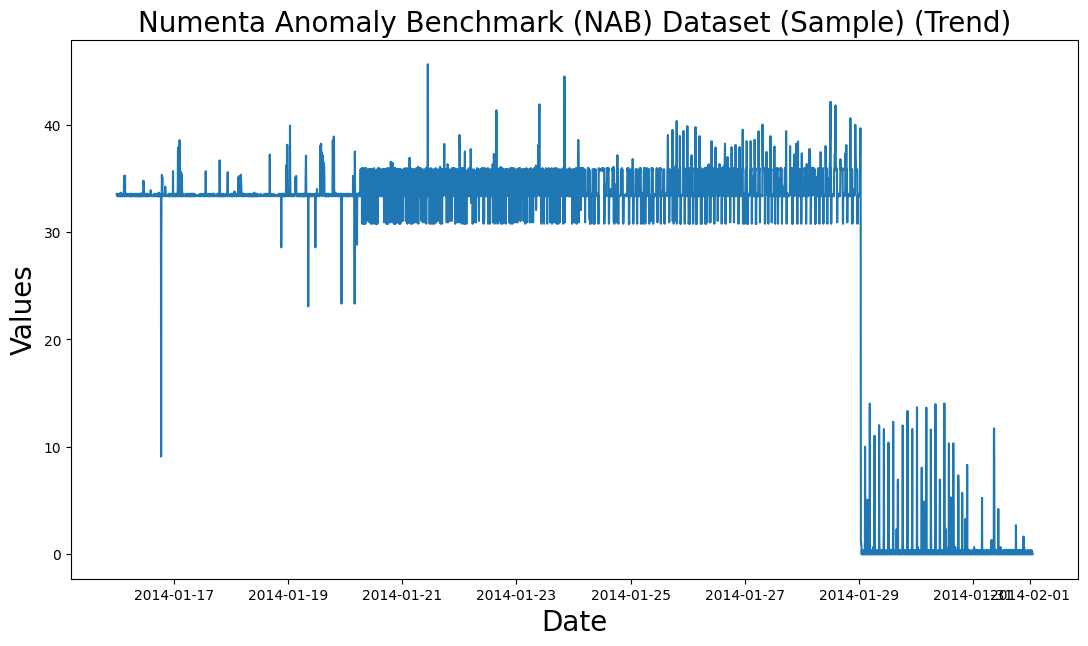

In [12]:
plot_nabs(df_entire, 0, df_entire.shape[0]-1, "Trend", title_name,
                 'Values')

# Normalization Process

In [13]:
def get_scaler(scaler):
    scalers = {
        "minmax": MinMaxScaler,
        "standard": StandardScaler,
        "maxabs": MaxAbsScaler,
        "robust": RobustScaler,
    }
    return scalers.get(scaler.lower())()

def normalize_data(df):
    scaler_type = 'minmax'
    #scaler_type = input("Enter a scaler type (minmax,standard, maxabs, robust): ")
    if (scaler_type != 'minmax') and (scaler_type != 'standard') and (scaler_type != 'maxabs') and (scaler_type != 'robust'):
      runtime.unassign()

    scaler = get_scaler(scaler_type)
    normalized_data_BA_Actual = scaler.fit_transform(df['value'].
                                               values.reshape(-1,1))
    df['value_Norm'] = normalized_data_BA_Actual
    return df, scaler

df_norm, scaler = normalize_data(df_entire)
#df_norm_mon, scaler = normalize_data(monthly_df)

In [14]:
df_norm = df_norm.drop(columns = ['value_Norm'])
df_norm

,value
timestamp,
2014-01-16 00:00:00,33.5573
2014-01-16 00:05:00,33.4460
2014-01-16 00:10:00,33.4447
2014-01-16 00:15:00,33.3333
2014-01-16 00:20:00,33.4447
...,...
2014-02-01 00:40:00,0.3380
2014-02-01 00:45:00,0.0000
2014-02-01 00:50:00,0.0000


### Trend Plot

/tmp/ipykernel_241953/3504211945.py:4: UserWarning: 'set_params()' not defined for locator of type <class 'matplotlib.dates.AutoDateLocator'>
  plt.locator_params(axis='x', nbins=10)


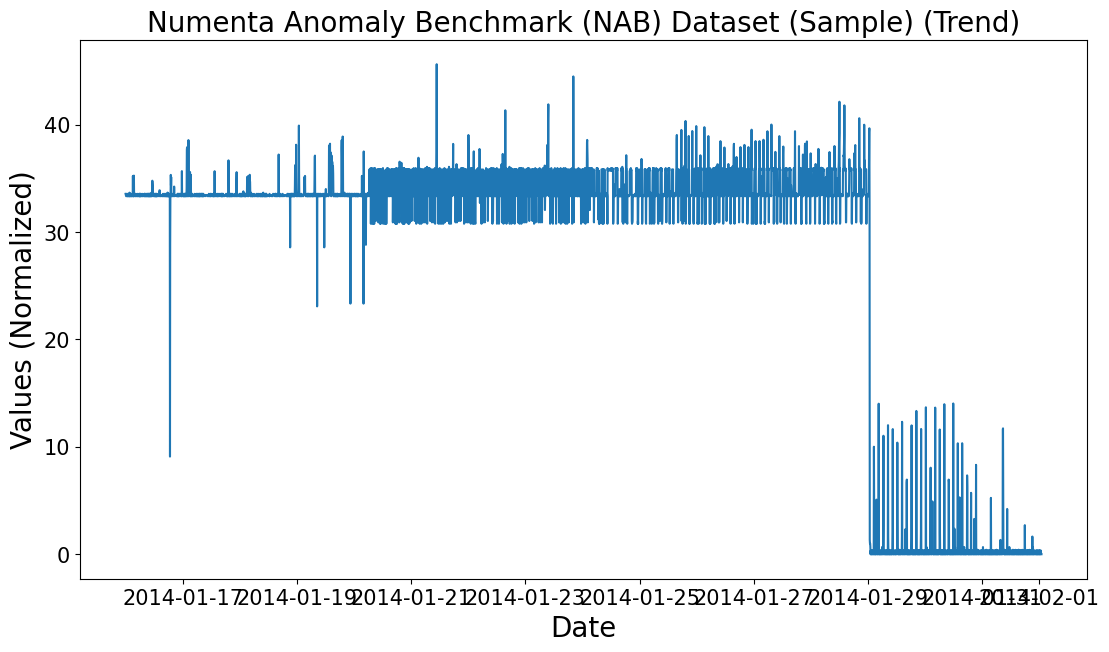

In [15]:
plot_nabs(df_norm, 0, df_norm.shape[0]-1, "Trend", title_name, 'Values (Normalized)')

# Let's observe train and test data on the graph

## Split into Train/Test Data.

In [16]:
test_size = 0.2 # Set Split rate to 4:1 (80 % Training 20 % Test).
split_pos = int(df_entire.shape[0]*(1 - test_size))
df_entire = df_entire.reset_index()
df_entire

,timestamp,value,value_Norm
0,2014-01-16 00:00:00,33.5573,0.735536
1,2014-01-16 00:05:00,33.4460,0.733097
2,2014-01-16 00:10:00,33.4447,0.733068
3,2014-01-16 00:15:00,33.3333,0.730627
4,2014-01-16 00:20:00,33.4447,0.733068
...,...,...,...
4616,2014-02-01 00:40:00,0.3380,0.007409
4617,2014-02-01 00:45:00,0.0000,0.000000
4618,2014-02-01 00:50:00,0.0000,0.000000
4619,2014-02-01 00:55:00,0.0000,0.000000


In [17]:
# 2019-02-06 will be the date seperation. Dates past this will be the test set.
split_date = str(df_entire.timestamp[split_pos])
#split_date = split_date[:10]
#DOM_train = df_norm.loc[df_norm.index <= split_date].copy()
DOM_train = df_entire.loc[df_norm.index <= split_date].copy()
#DOM_test = df_norm.loc[df_norm.index > split_date].copy()
DOM_test = df_entire.loc[df_norm.index > split_date].copy()
split_date

'2014-01-28 20:00:00'

## Plot Train/Test Split Graphs.

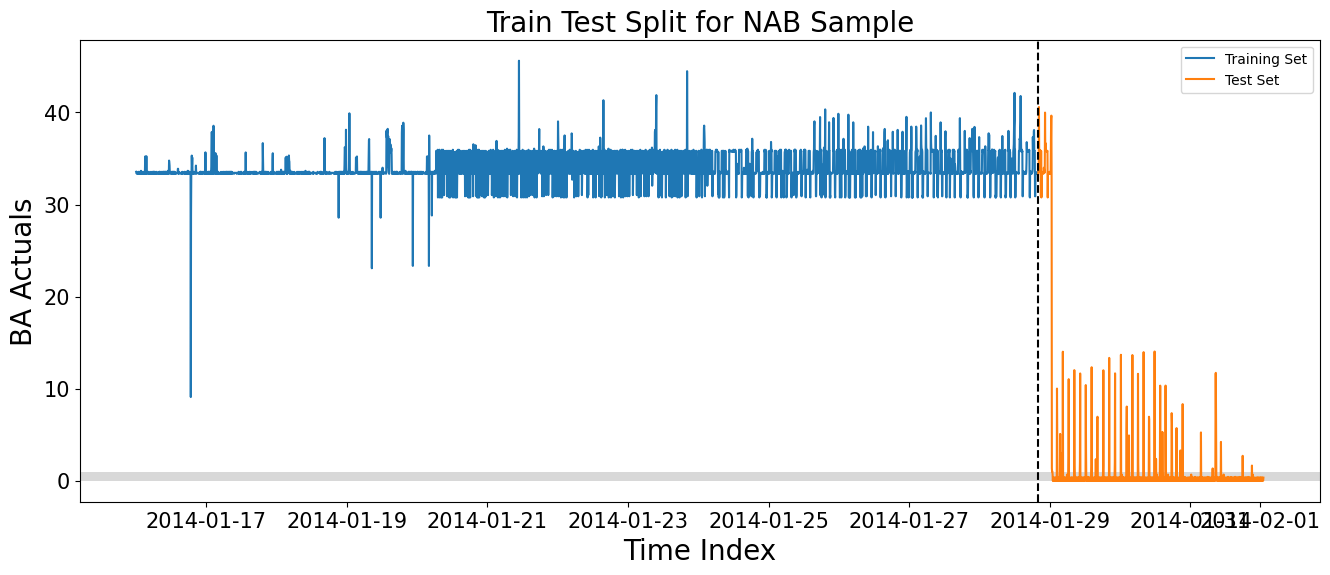

In [18]:
# Monthly Mean Total Sunspot Number Train Test Split
plt.figure(figsize=(16,6))
plt.plot(DOM_train['timestamp'], DOM_train['value'],
         label='Training Set')
plt.plot(DOM_test['timestamp'], DOM_test['value'],
         label='Testing Set')
plt.axvline(x = df_entire.timestamp[split_pos], color='black', ls='--')
plt.legend(['Training Set', 'Test Set'])
plt.axhspan(0, 1, facecolor='gray', alpha=0.3)
plt.xlabel("Time Index", fontsize = 20)
plt.ylabel("BA Actuals", fontsize = 20)
plt.title("Train Test Split for NAB Sample", fontsize = 20)
plt.show()

In [19]:
# We index the Datetime column after transformation
df_entire.set_index('timestamp', inplace=True)
df_entire.head()

,value,value_Norm
timestamp,,
2014-01-16 00:00:00,33.5573,0.735536
2014-01-16 00:05:00,33.4460,0.733097
2014-01-16 00:10:00,33.4447,0.733068
2014-01-16 00:15:00,33.3333,0.730627
2014-01-16 00:20:00,33.4447,0.733068


In [20]:
df_entire1 = df_entire.drop(columns = ['value_Norm'])
df_entire1

,value
timestamp,
2014-01-16 00:00:00,33.5573
2014-01-16 00:05:00,33.4460
2014-01-16 00:10:00,33.4447
2014-01-16 00:15:00,33.3333
2014-01-16 00:20:00,33.4447
...,...
2014-02-01 00:40:00,0.3380
2014-02-01 00:45:00,0.0000
2014-02-01 00:50:00,0.0000


In [21]:
df_entire2 = df_entire.drop(columns = ['value'])
df_entire2

,value_Norm
timestamp,
2014-01-16 00:00:00,0.735536
2014-01-16 00:05:00,0.733097
2014-01-16 00:10:00,0.733068
2014-01-16 00:15:00,0.730627
2014-01-16 00:20:00,0.733068
...,...
2014-02-01 00:40:00,0.007409
2014-02-01 00:45:00,0.000000
2014-02-01 00:50:00,0.000000


# Prepare Data for Training the Models.

* With the following function block, let's set our data set as training and test data set in a model appropriate way

In [22]:
def load_data(data, seq_len):
    X_train = []
    y_train = []

    for i in range(seq_len, len(data)):
        X_train.append(data.iloc[i-seq_len : i, 0])
        y_train.append(data.iloc[i, 0])

    # last days are going to be used in test
    X_test = X_train[split_pos:]
    y_test = y_train[split_pos:]

    # first  days are going to be used in training
    X_train = X_train[:split_pos]
    y_train = y_train[:split_pos]

    # convert to numpy array
    X_train = np.array(X_train)
    y_train = np.array(y_train)
    X_test = np.array(X_test)
    y_test = np.array(y_test)

    # reshape data to input into LSTM, SNN, and Hybrid DNN Models.
    X_train = np.reshape(X_train, (split_pos, seq_len, 1))
    X_test = np.reshape(X_test, (X_test.shape[0], seq_len, 1))

    return [X_train, y_train, X_test, y_test]

* **The seq_len** parameter determines how far back the model will look at historical data, helping the model to capture time dependencies in a memory-aware way.
* We should note that if "seq_len" is too large, the model can become complex and prone to overlearning.
* We can specify separate seq_len values for LSTM, SNN, and CNN-LSTM

In [23]:
feature = 'value'
#selected_df = df_entire1
selected_df = df_entire2
feature_norm = 'value_Norm'
feature_field = 'value'

In [24]:
seq_len = 20
#seq_len = 6*24*30

# Let's create train, test data
#X_train, y_train, X_test, y_test = load_data(df_vht, seq_len)
#X_train, y_train, X_test, y_test = load_data(df_vmt, seq_len)
X_train, y_train, X_test, y_test = load_data(selected_df, seq_len)
#X_train, y_train, X_test, y_test = load_data(df_norm2, seq_len)


print('X_train.shape = ',X_train.shape)
print('y_train.shape = ', y_train.shape)
print('X_test.shape = ', X_test.shape)
print('y_test.shape = ',y_test.shape)

X_train.shape =  (3696, 20, 1)
y_train.shape =  (3696,)
X_test.shape =  (905, 20, 1)
y_test.shape =  (905,)


In [25]:
X_train

array([[[0.73553632],
        [0.73309676],
        [0.73306826],
        ...,
        [0.73062651],
        [0.73549248],
        [0.73062651]],

       [[0.73309676],
        [0.73306826],
        [0.73062651],
        ...,
        [0.73549248],
        [0.73062651],
        [0.7378904 ]],

       [[0.73306826],
        [0.73062651],
        [0.73306826],
        ...,
        [0.73062651],
        [0.7378904 ],
        [0.73062651]],

       ...,

       [[0.73062651],
        [0.73553632],
        [0.73309676],
        ...,
        [0.67442447],
        [0.67724103],
        [0.73371487]],

       [[0.73553632],
        [0.73309676],
        [0.73546399],
        ...,
        [0.67724103],
        [0.73371487],
        [0.73062651]],

       [[0.73309676],
        [0.73546399],
        [0.73062651],
        ...,
        [0.73371487],
        [0.73062651],
        [0.73302442]]])

In [26]:
X_test

array([[[0.73546399],
        [0.73062651],
        [0.73556701],
        ...,
        [0.73062651],
        [0.73302442],
        [0.73302442]],

       [[0.73062651],
        [0.73556701],
        [0.73549248],
        ...,
        [0.73302442],
        [0.73302442],
        [0.73306826]],

       [[0.73556701],
        [0.73549248],
        [0.88977904],
        ...,
        [0.73302442],
        [0.73306826],
        [0.73302442]],

       ...,

       [[0.00718937],
        [0.        ],
        [0.00718937],
        ...,
        [0.        ],
        [0.00740856],
        [0.        ]],

       [[0.        ],
        [0.00718937],
        [0.        ],
        ...,
        [0.00740856],
        [0.        ],
        [0.        ]],

       [[0.00718937],
        [0.        ],
        [0.00732088],
        ...,
        [0.        ],
        [0.        ],
        [0.        ]]])

In [27]:
y_train

array([0.7378904 , 0.73062651, 0.73062651, ..., 0.73062651, 0.73302442,
       0.73302442])

In [28]:
y_test

array([0.73306826, 0.73302442, 0.73062651, 0.73309676, 0.74528362,
       0.74276953, 0.73797808, 0.73306826, 0.74280022, 0.87651815,
       0.7905657 , 0.80387262, 0.78543012, 0.78543012, 0.78543012,
       0.78543012, 0.78543012, 0.78281521, 0.78546081, 0.78543012,
       0.67442447, 0.73371487, 0.73362281, 0.73306826, 0.73306826,
       0.73302442, 0.73062651, 0.73306826, 0.73553632, 0.73309676,
       0.73062651, 0.73550783, 0.73062651, 0.81369005, 0.86150376,
       0.86925426, 0.71459289, 0.0292397 , 0.02183114, 0.02205033,
       0.01459793, 0.        , 0.00732088, 0.        , 0.00732088,
       0.        , 0.        , 0.00718937, 0.        , 0.00732088,
       0.        , 0.        , 0.00718937, 0.00740856, 0.        ,
       0.00718937, 0.        , 0.        , 0.21936352, 0.08684235,
       0.        , 0.        , 0.00718937, 0.        , 0.00732088,
       0.        , 0.00732088, 0.        , 0.00740856, 0.        ,
       0.00732088, 0.11143527, 0.00732088, 0.        , 0.00732

## Essential Variables.
Will be used when training all of the models.

## Training Loss vs. Epochs Plot

Plotting Accuracy and Validation Accuracy vs Epochs. Code taken from https://machinelearningmastery.com/display-deep-learning-model-training-history-in-keras/.

In [29]:
def plot_training_loss(model, model_name):
    model.history.keys()
    plt.plot(model.history['loss'])
    plt.title('Training Loss vs. Epochs for {0}'.format(model_name))
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.show()

## Integrate PeMS Data with Lava's LIF Neurons.
Convert the normalized dataset into spike inputs for Lava’s LIF neurons.
Feed the spike data into the Dense layer

# Feed Input Data into Spike Trains.

Create a Histogram of the Potential Spike_Train for use of finding the threshold to lower.

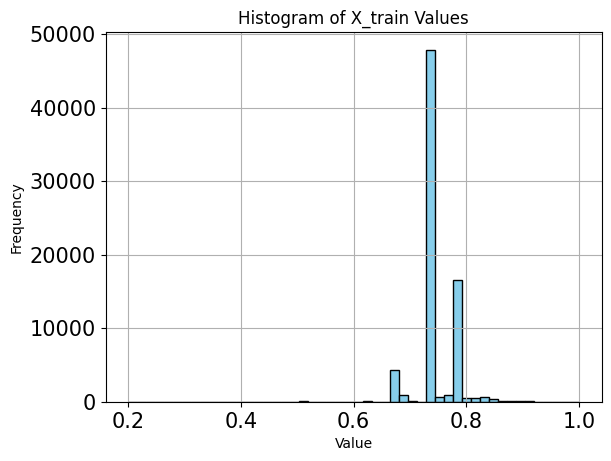

In [30]:
# Flatten X_train if it's multi-dimensional
flat_data = X_train.flatten()

# Plot the histogram
plt.hist(flat_data, bins=50, color='skyblue', edgecolor='black')
plt.title("Histogram of X_train Values")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [31]:
# 🔹 Step 0: Connect Loihi 1 and 2 Hardware and Software backend.
backend="L2Sim"
#backend="L2Hw"
#backend="L1Sim"

# Define run_config based on backend
if backend == "L2Sim":
    #os.environ["SLURM"] = None
    #os.environ["LOIHI_GEN"] = None        
    #os.environ["LOIHI_GEN"] = "N3C1"         
    #os.environ["PARTITION"] = None
    run_config = Loihi2SimCfg(
        select_tag="fixed_pt",
        #exception_proc_model_map={
        #    StaticSpikeGenerator: StaticSpikeGeneratorModel
            # Other Overrides if needed
        #}
    )

elif backend == "L1Sim":
    #os.environ["SLURM"] = None
    #os.environ["LOIHI_GEN"] = None        
    #os.environ["LOIHI_GEN"] = "N3C1"         
    #os.environ["PARTITION"] = None
    run_config = Loihi1SimCfg(
        select_tag="fixed_pt",
        #exception_proc_model_map={
        #    StaticSpikeGenerator: StaticSpikeGeneratorModel
            # Other Overrides if needed
        #}
    )

elif backend == "L2Hw":
    os.environ["SLURM"] = "1"
    os.environ["LOIHI_GEN"] = "N3B3"         
    #os.environ["LOIHI_GEN"] = "N3C1"         
    os.environ["PARTITION"] = "oheogulch"
    run_config = Loihi2HwCfg(
        select_tag="fixed_pt",
        #exception_proc_model_map={
        #    StaticSpikeGenerator: StaticSpikeGeneratorModel
            # Other Overrides if needed
        #}
    )
else:
    run_config=None
    print("No Match for Loihi Hardware/Software.")

# Initialization

In [32]:
# Encode to Spikes Function
def encode_to_spikes(x, time_steps=40):
    x = np.clip(x, 0, 1)
    return (np.random.rand(len(x), time_steps) < x[:, None]).astype(np.int32)

In [33]:
# Create Spike Train
# Step 1: Define spike train
# Shape: (number of neurons, number of time steps)
input_dim = 20
hidden_dim = input_dim
time_steps=20
#time_steps = 40

X_train = X_train.reshape(-1)[:hidden_dim]  # Ensure features
X_train = np.clip(X_train, 0, 1)  # Ensure values are in [0, 1]
#threshold = 0.5  # Can be tuned based on distribution.
threshold = np.percentile(X_train, 25)  # or use dynamic scaling
#threshold = np.percentile(X_train, [0, 75])
print("threshold: ", threshold)

# Probabilistic encoding based on magnitude
spike_train = (np.random.rand(input_dim, time_steps) < X_train[:input_dim, None]).astype(np.int32) # shape: (time_steps, features)
# Force early spikes for stability
spike_train[:8, :5] = 1
print("spike_train: {}".format(spike_train))
print(X_test[0].shape)
X_sample = X_test[0].reshape(1, 20, 1)  # for ANN
spike_train = encode_to_spikes(X_sample.squeeze(), time_steps)  # for SNN
#spike_train = encode_to_spikes(X_train)
#spike_train = spike_train.reshape(-1)
num_neurons = spike_train.shape[0]
#hidden_dim =spike_train.shape[1]
print("Spike Train shape: {}".format(spike_train.shape))

threshold:  0.7306265055487485
spike_train: [[1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 0 1 1 0 0]
 [1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 0 0 1 1 1 0 1 1 1 1 1]
 [1 1 1 1 1 1 1 0 1 1 1 0 1 0 0 1 0 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 0]
 [1 1 1 1 1 0 1 1 1 1 0 1 1 1 0 1 0 0 0 0]
 [1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 1 0 1 1 1]
 [1 0 0 0 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1]
 [1 0 1 0 1 1 0 1 1 1 1 0 0 1 1 1 1 0 1 0]
 [1 1 1 1 1 1 1 0 0 0 0 1 0 1 0 1 1 1 1 1]
 [0 1 1 1 1 0 1 0 1 1 1 1 1 1 0 1 0 1 1 1]
 [1 1 0 1 1 0 1 0 0 1 0 1 1 0 1 0 1 1 1 1]
 [1 0 0 1 0 0 1 1 1 1 0 1 1 0 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1]
 [0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1]
 [1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1]
 [1 0 1 1 1 0 1 1 1 0 1 1 1 0 1 1 1 1 1 1]
 [1 1 0 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0]]
(20, 1)
Spike Train shape: (20, 20)


In [34]:
# Parameters
num_epochs = 10
learning_rate = 0.001
input_dim = spike_train.shape[1]

In [35]:
# Initialize weights
w1 = np.random.randint(-3, 4, size=(input_dim, hidden_dim))
w2 = np.copy(w1)
w3 = np.copy(w1)
decoder_weights = np.random.uniform(-1, 1, size=(hidden_dim,))

In [36]:
# Logging containers
mae_log, rmse_log, energy_log = [], [], []

In [37]:
# Ground truth placeholder (replace with actual target values)
true_values = np.random.uniform(-1, 1, size=(num_epochs,))  # Dummy ground truth

# Training with Epochs


Epoch 1/10
📉 Prediction: -42.4869, True: -0.0257, MAE: 42.4612, RMSE: 42.4612
Total Energy: 0.000750 J
⚡ Total Energy (Loihi-style): 0.000750 J

RingSNN Total Energy: 0.0008 J
RingSNN Energy per Sample: 75.02 µJ


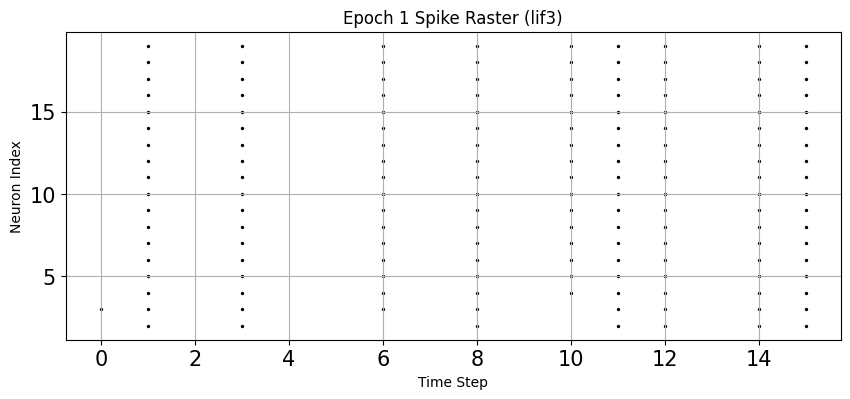

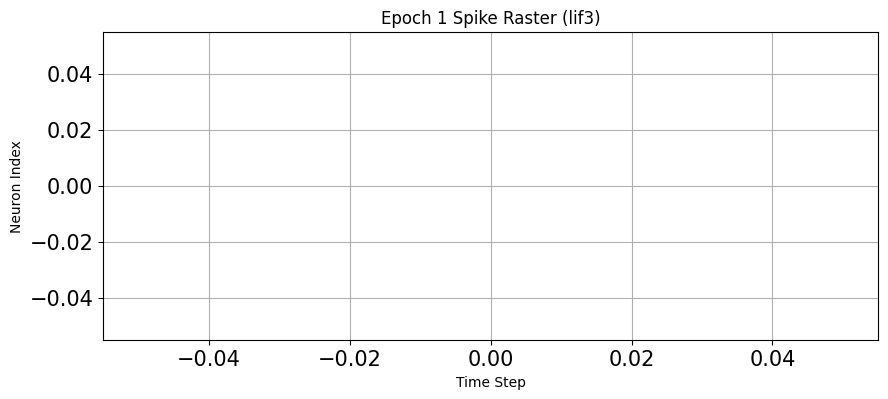

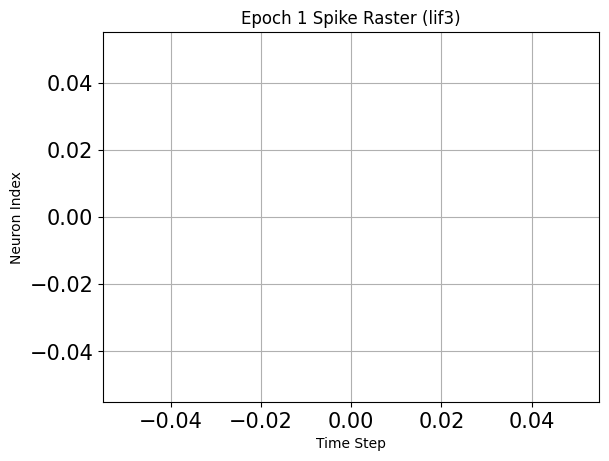

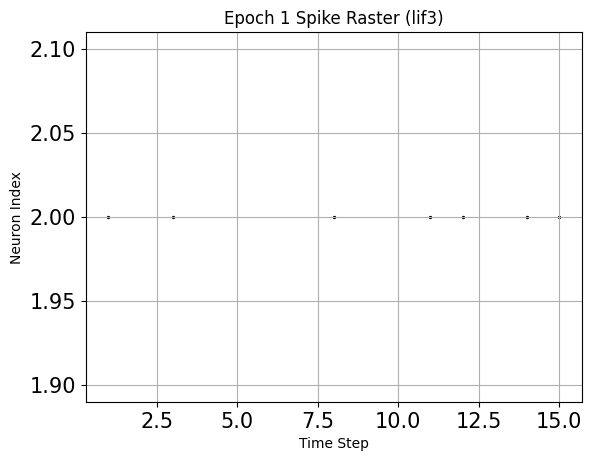

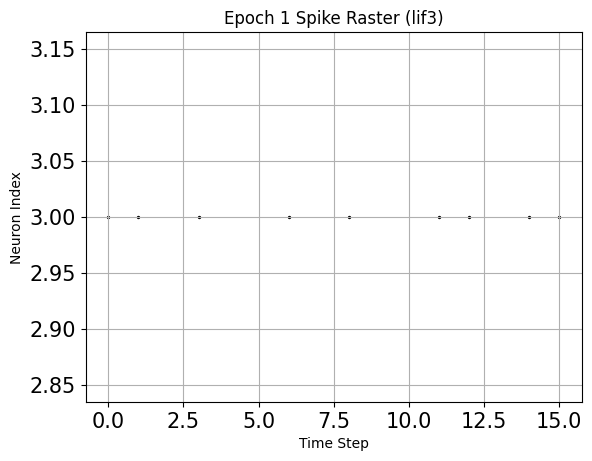

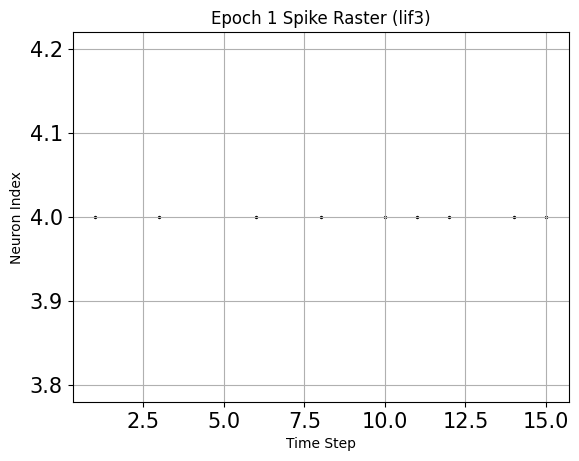

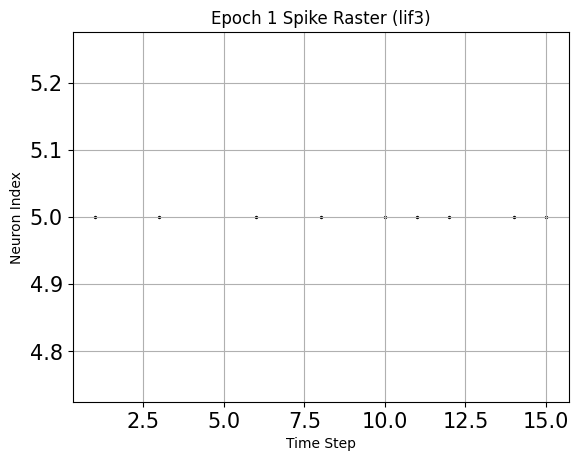

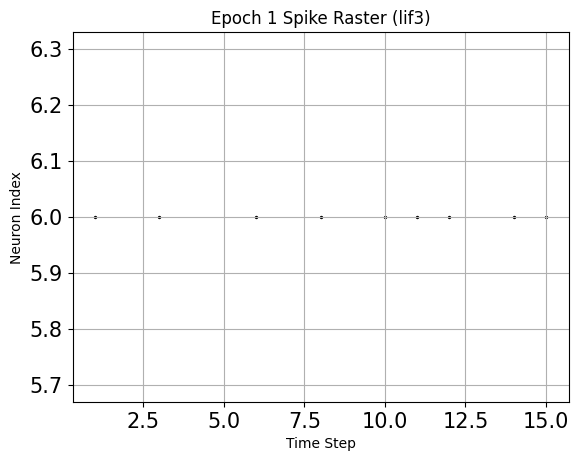

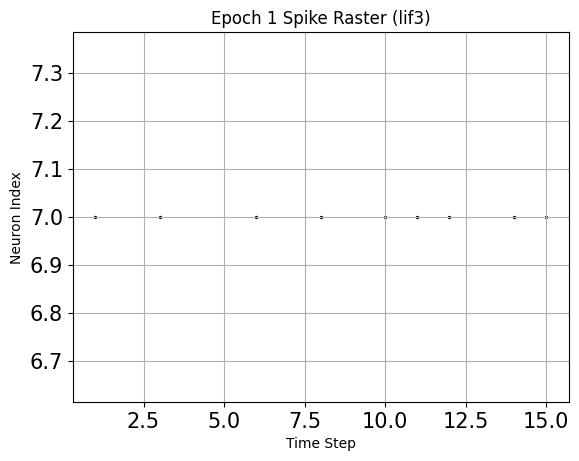

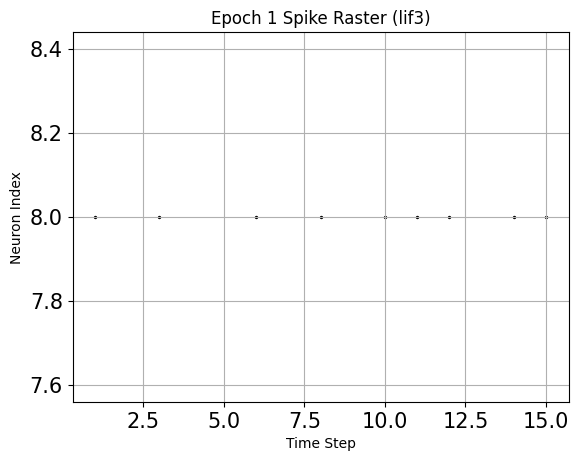

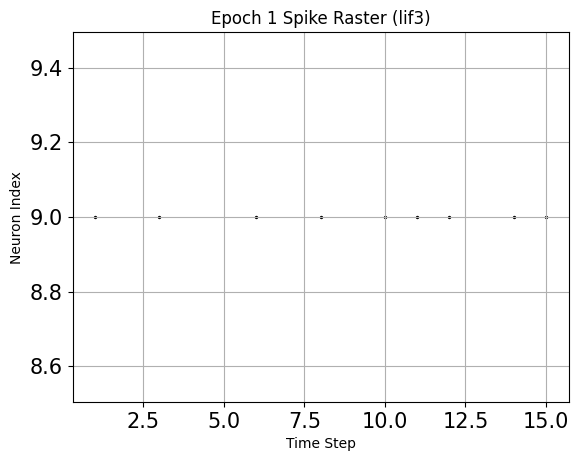

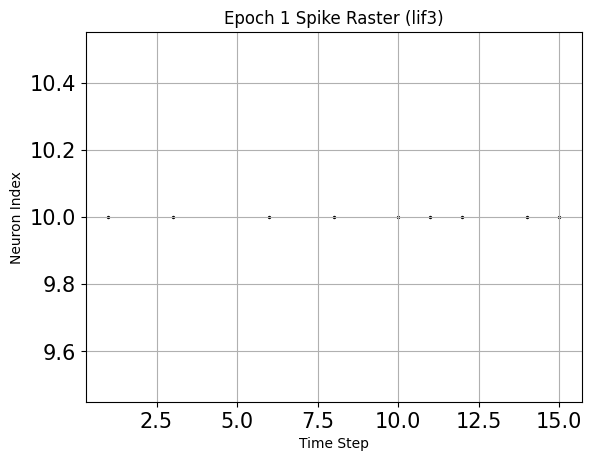

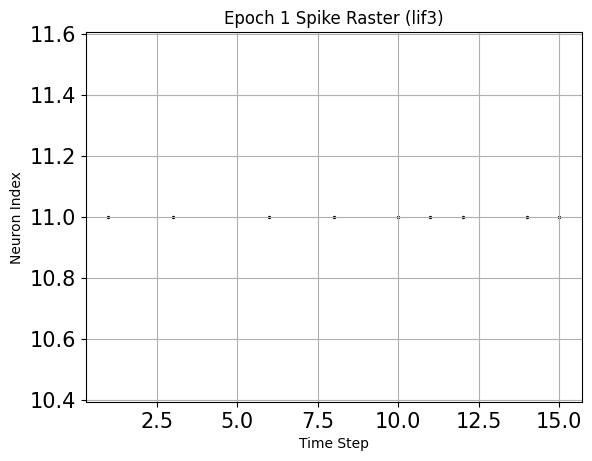

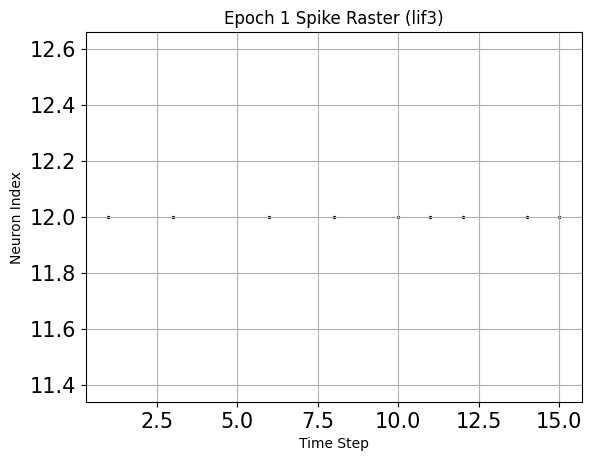

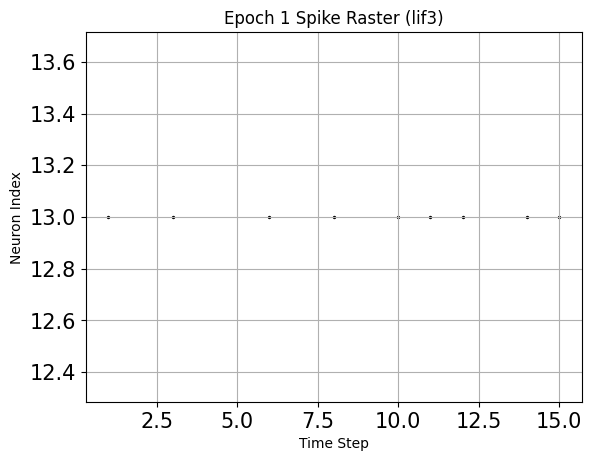

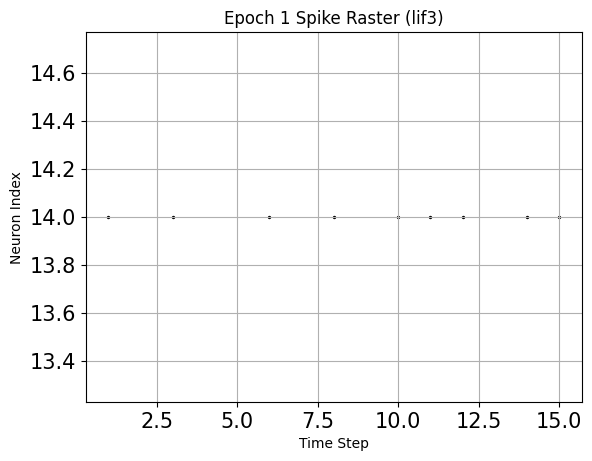

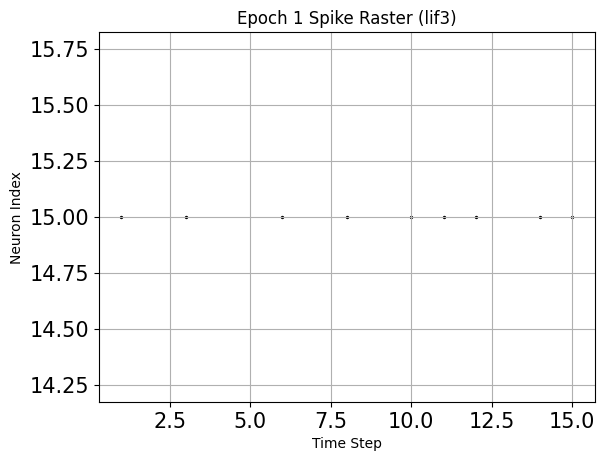

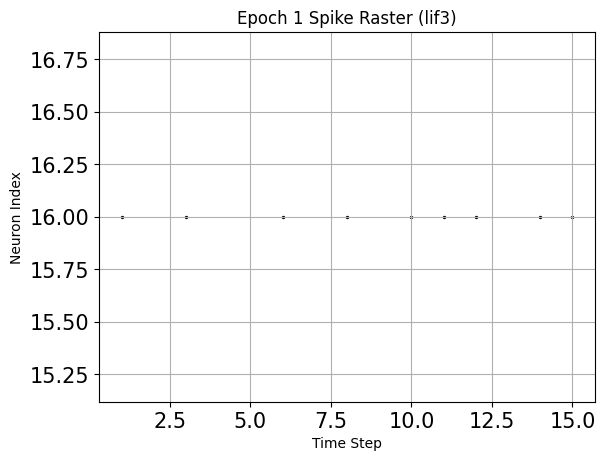

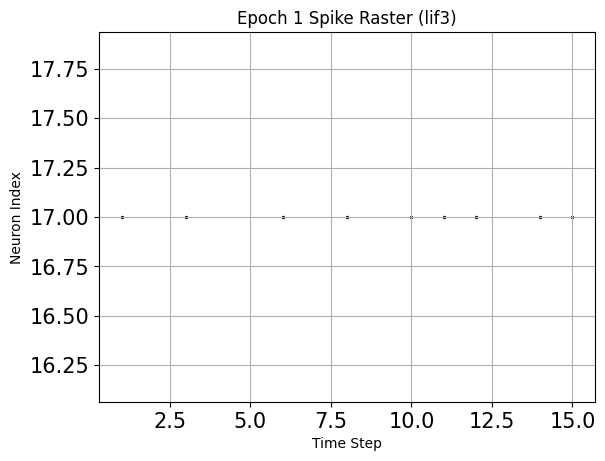

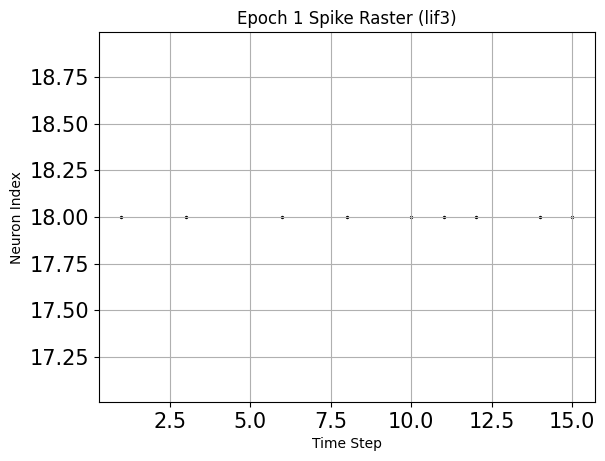

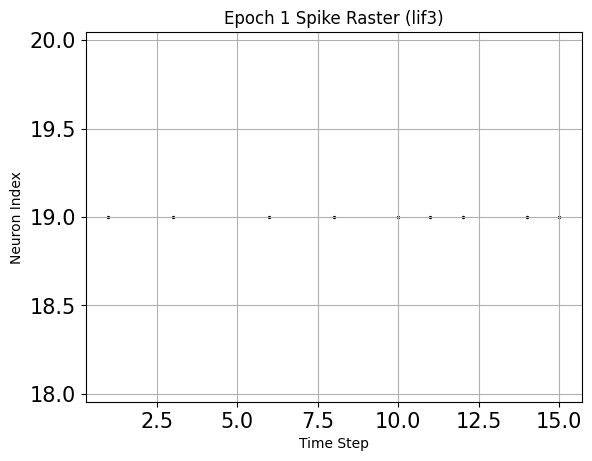


Epoch 2/10
📉 Prediction: -45.6580, True: -0.6187, MAE: 45.0393, RMSE: 45.0393
Total Energy: 0.000750 J
⚡ Total Energy (Loihi-style): 0.000750 J

RingSNN Total Energy: 0.0023 J
RingSNN Energy per Sample: 225.07 µJ


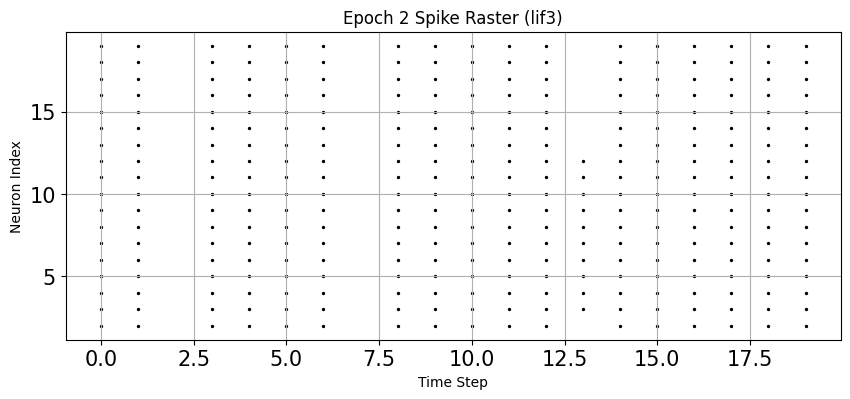

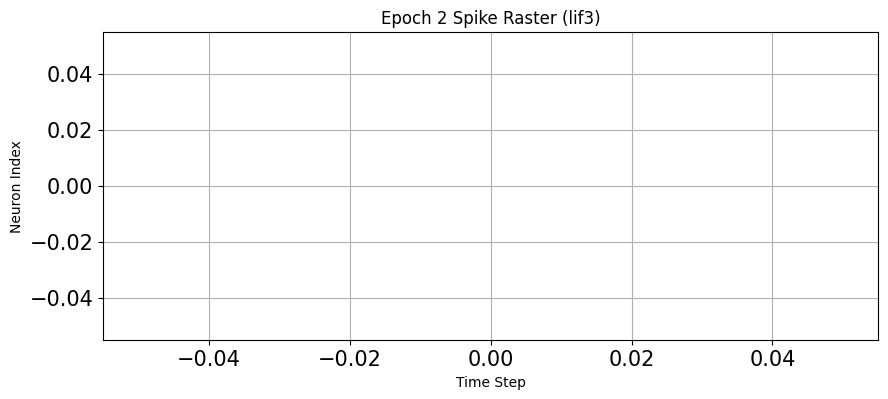

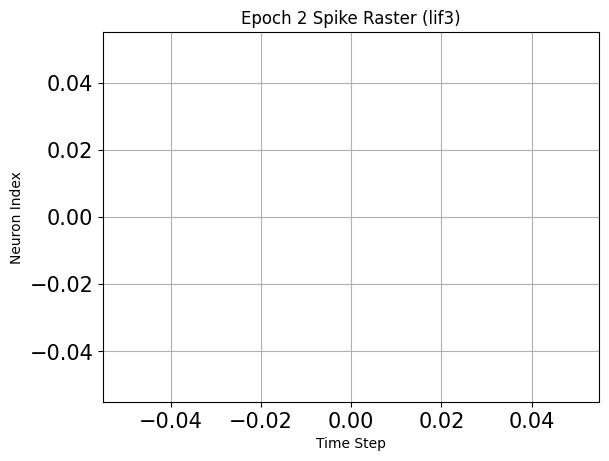

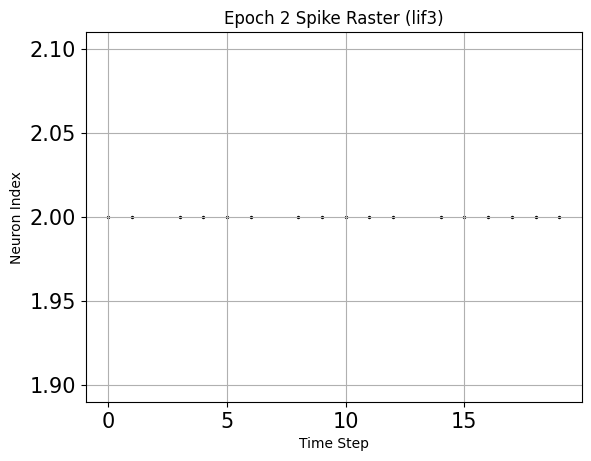

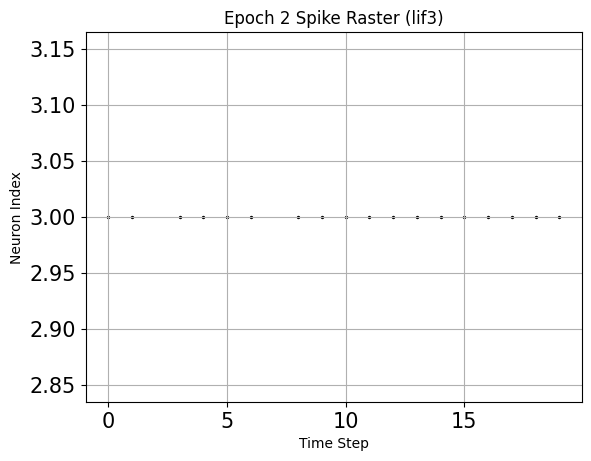

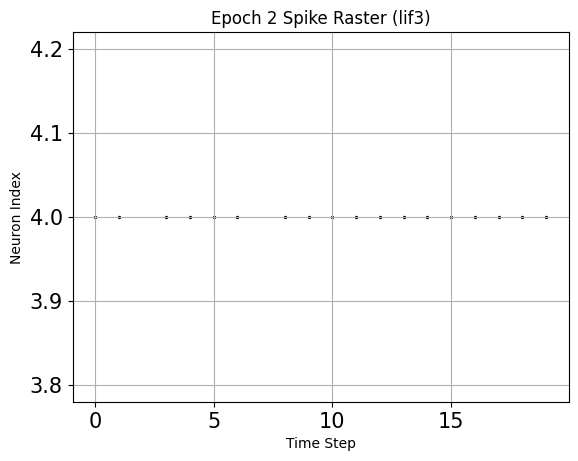

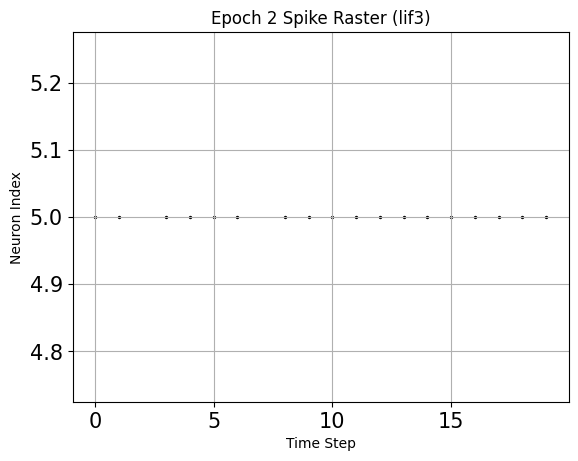

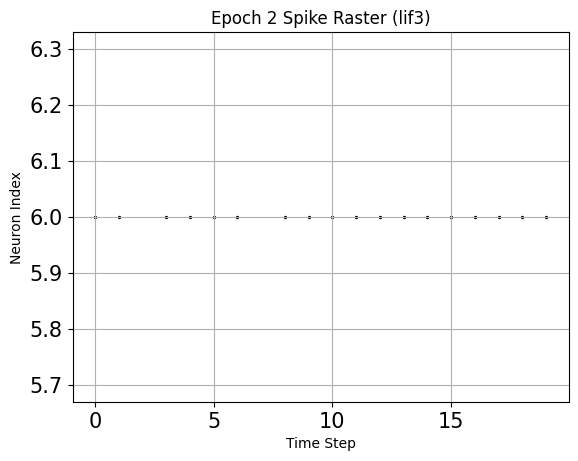

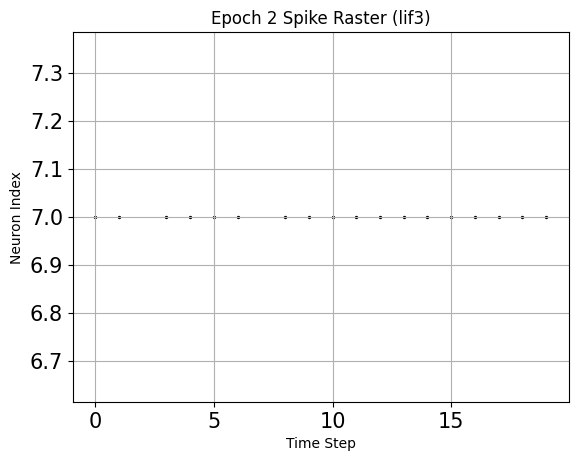

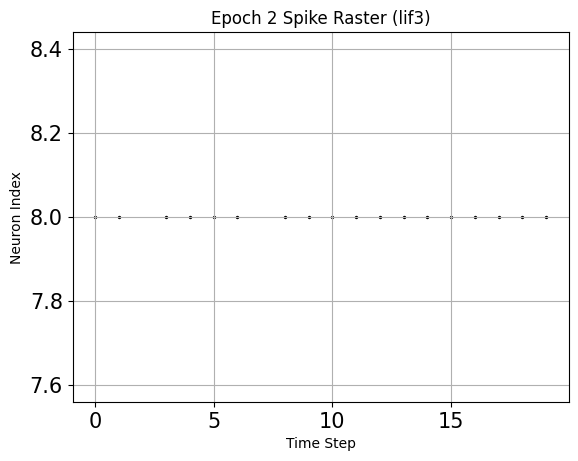

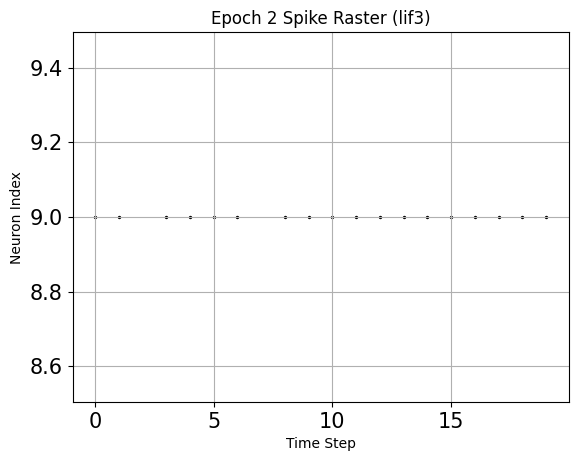

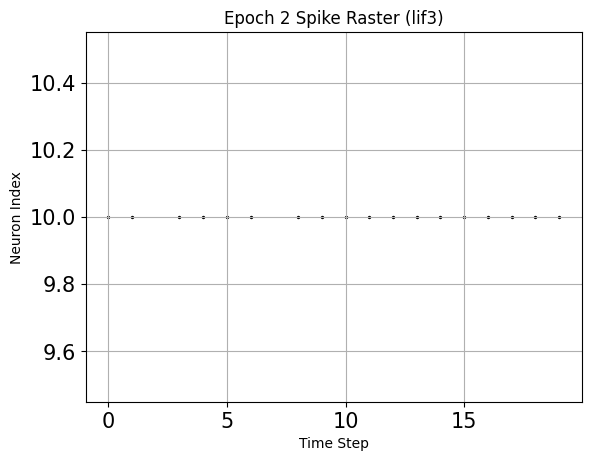

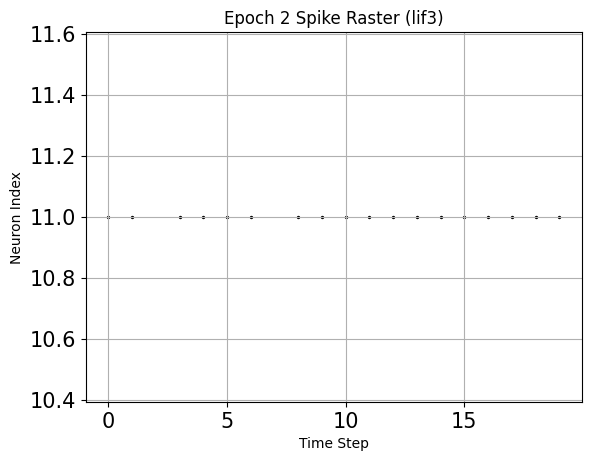

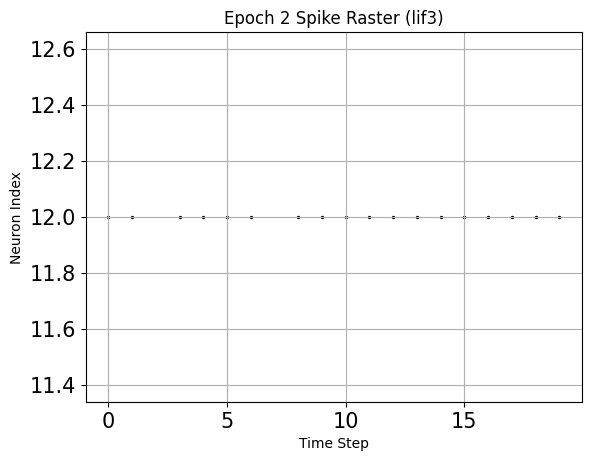

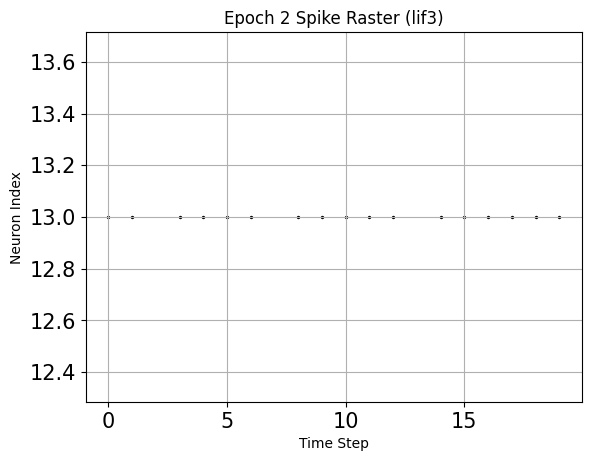

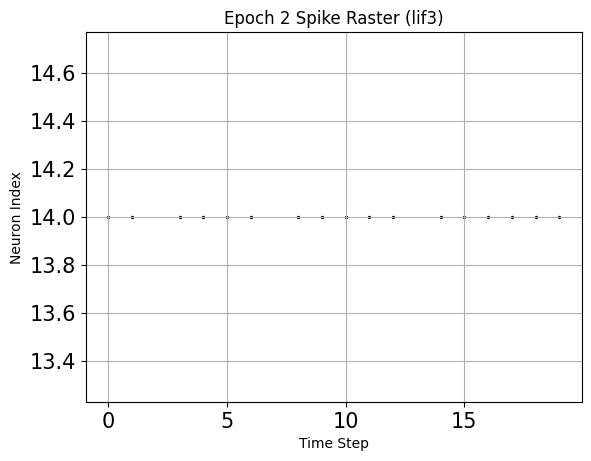

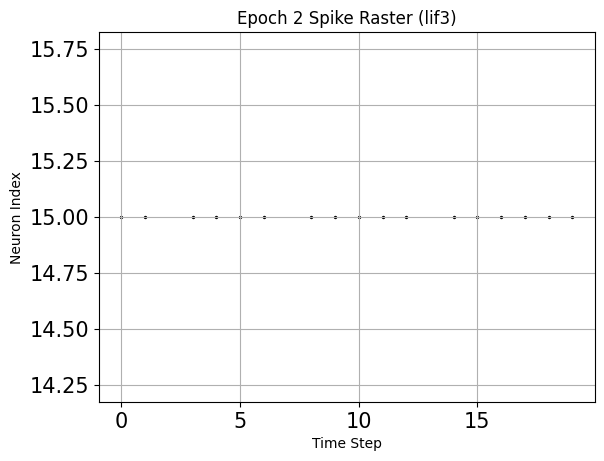

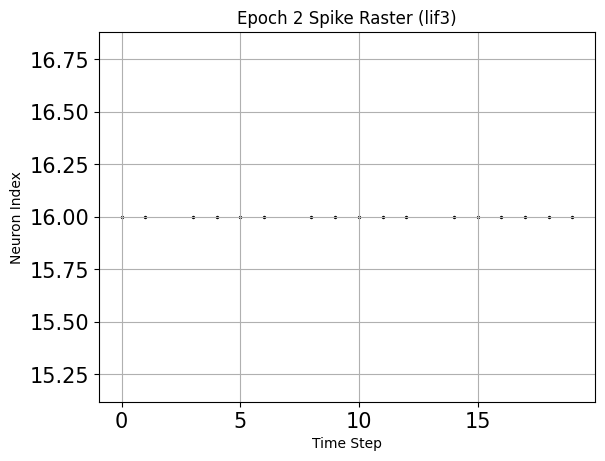

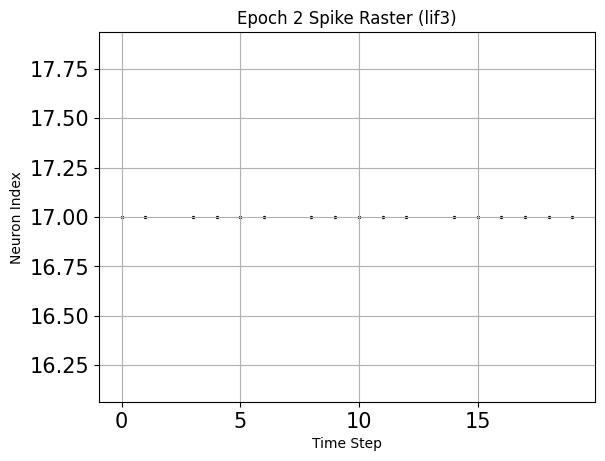

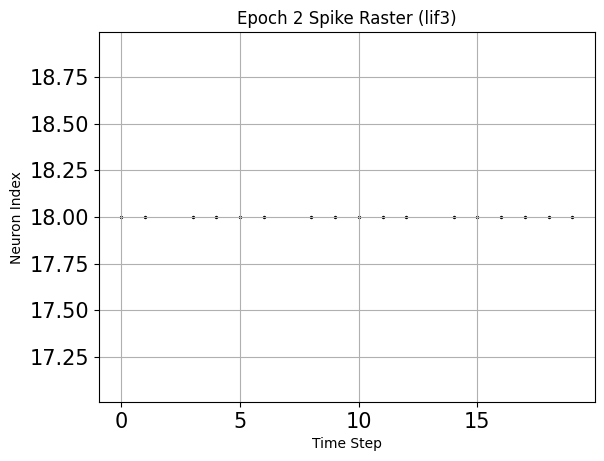

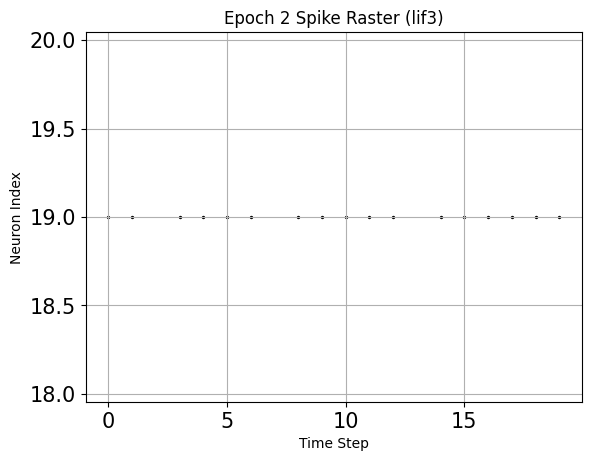


Epoch 3/10
📉 Prediction: -18.7434, True: -0.4311, MAE: 18.3124, RMSE: 18.3124
Total Energy: 0.000750 J
⚡ Total Energy (Loihi-style): 0.000750 J

RingSNN Total Energy: 0.0038 J
RingSNN Energy per Sample: 375.14 µJ


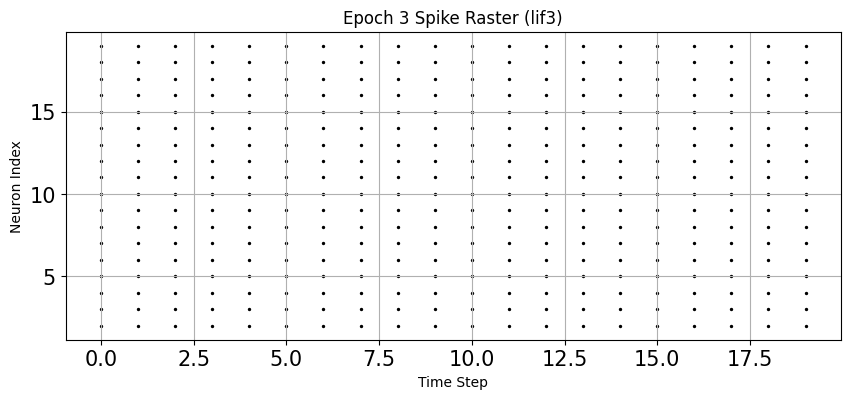

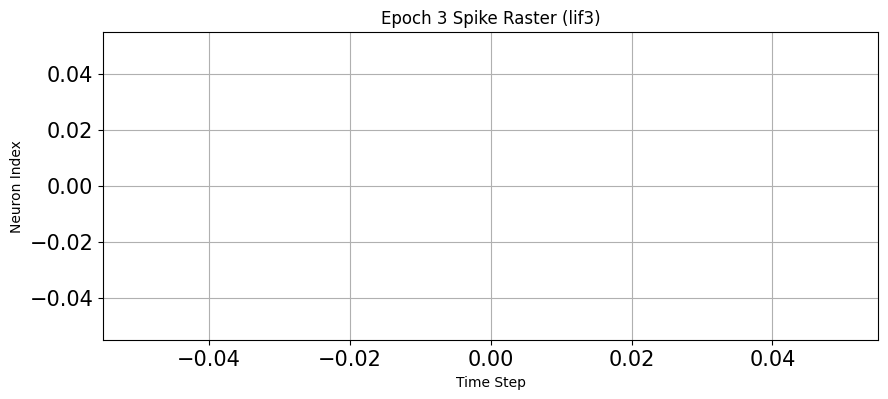

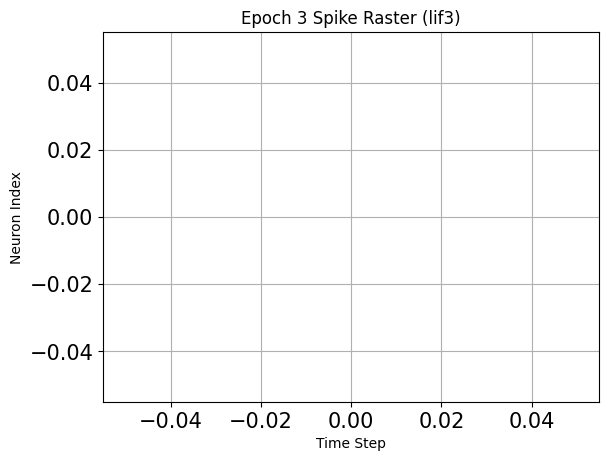

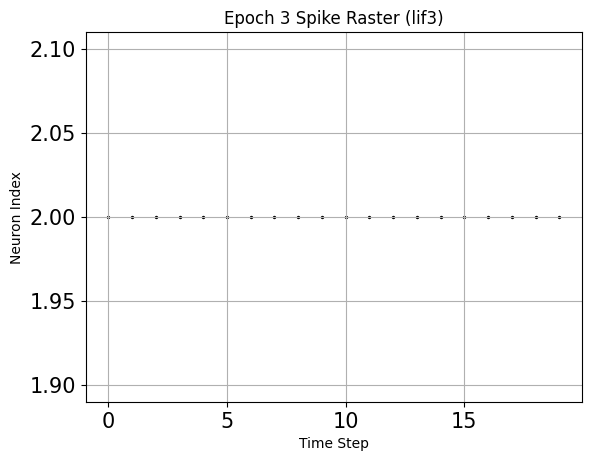

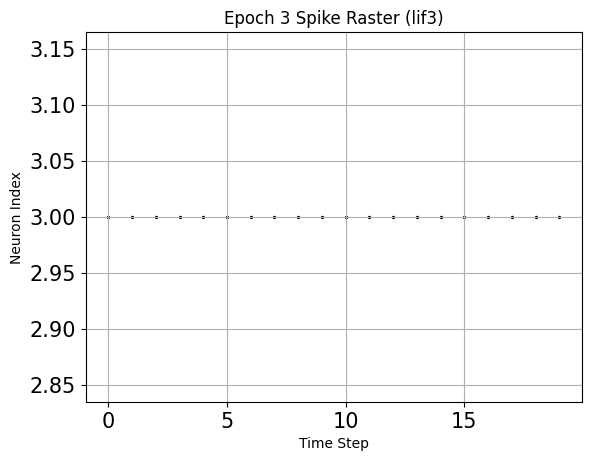

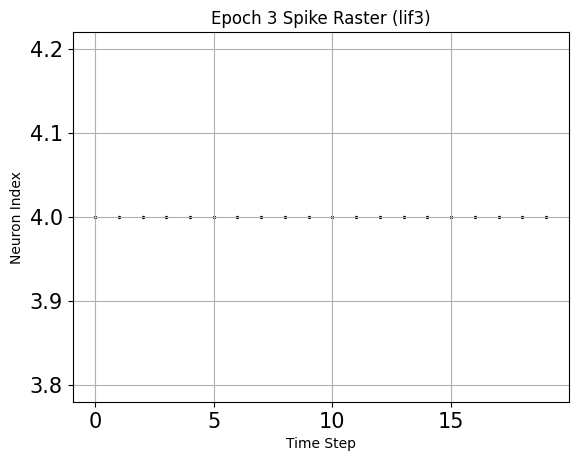

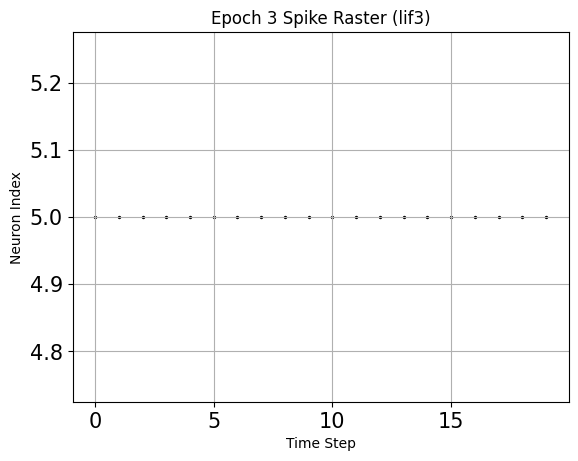

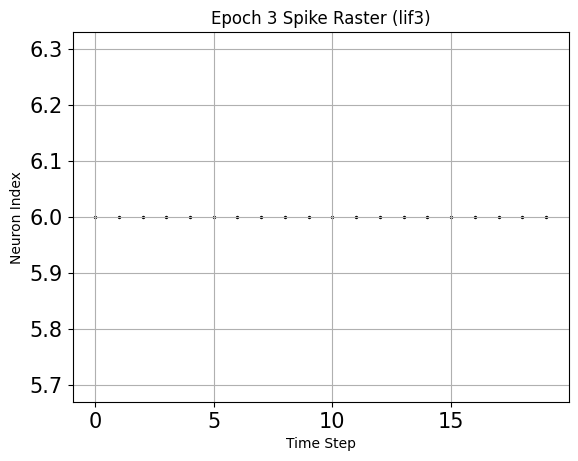

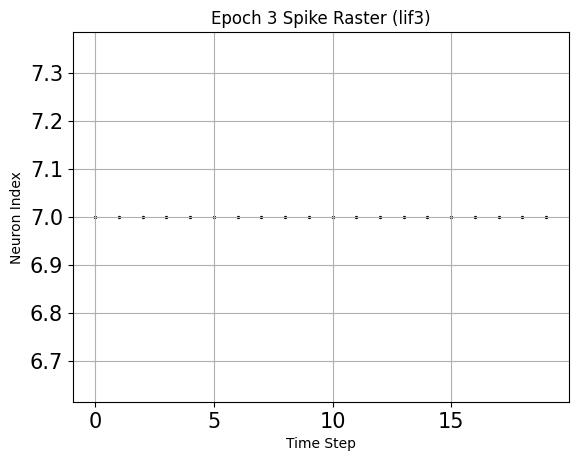

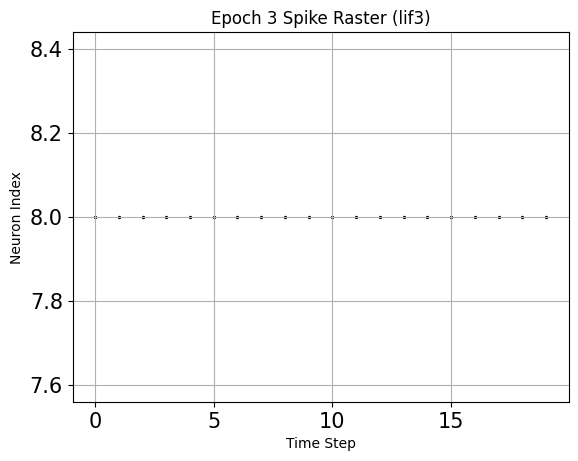

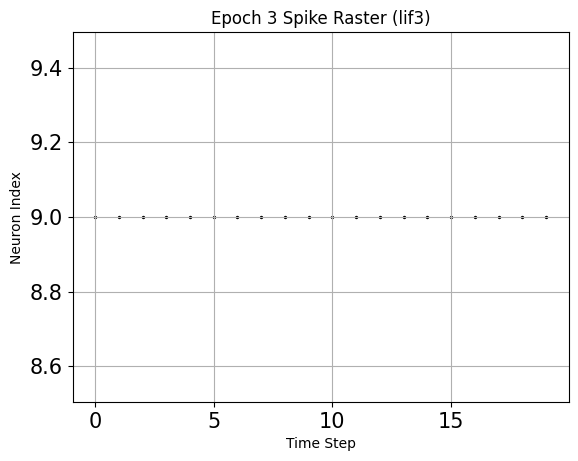

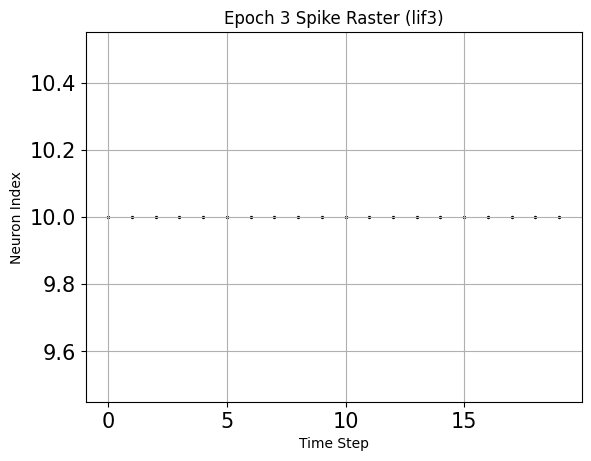

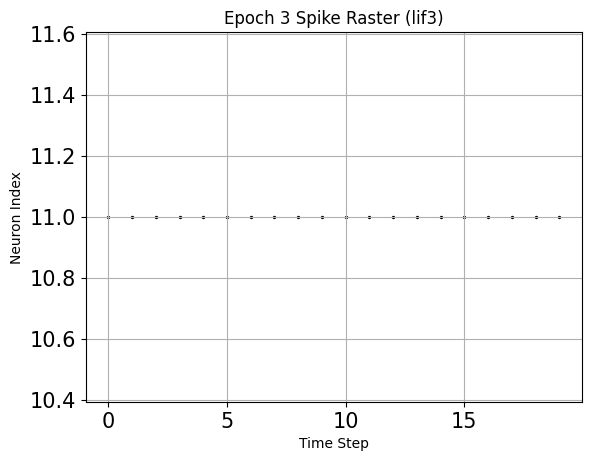

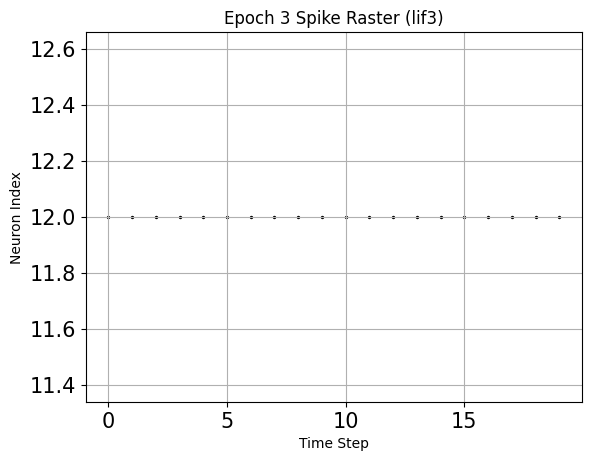

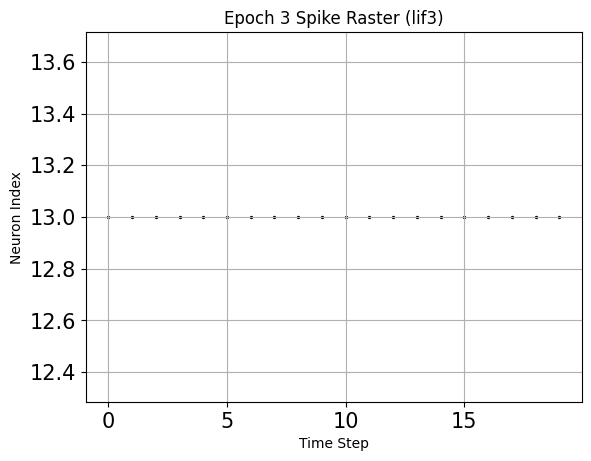

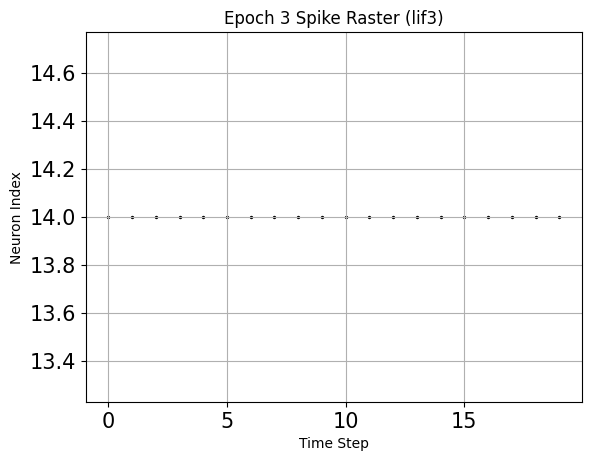

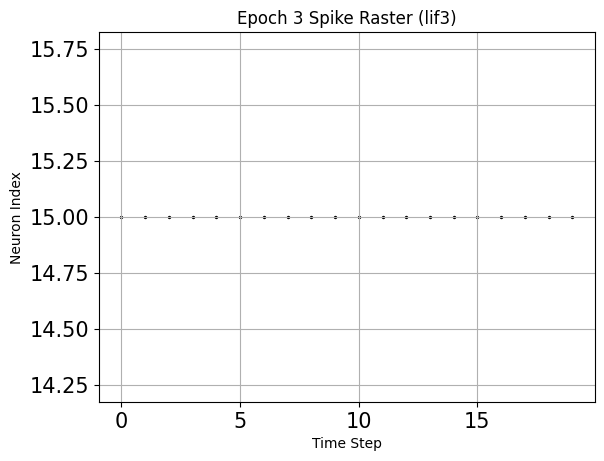

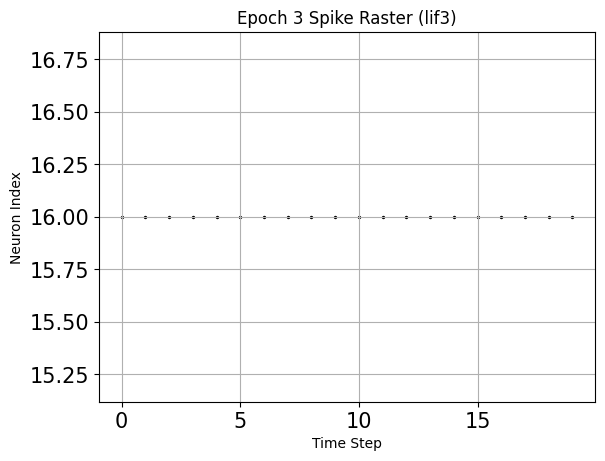

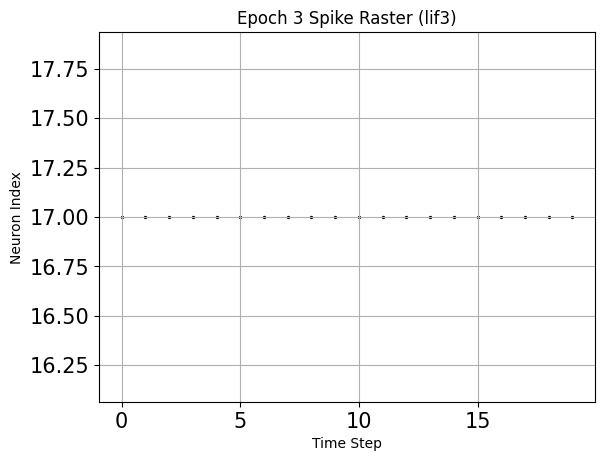

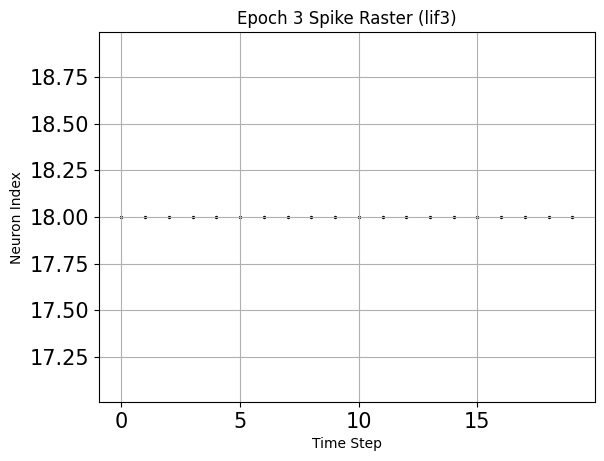

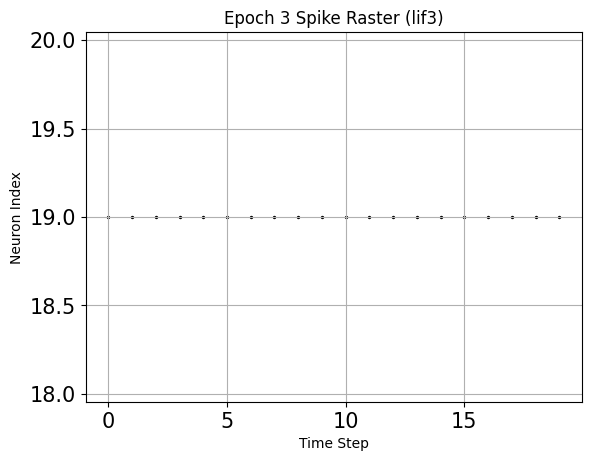


Epoch 4/10
📉 Prediction: 23.3433, True: -0.5619, MAE: 23.9052, RMSE: 23.9052
Total Energy: 0.000750 J
⚡ Total Energy (Loihi-style): 0.000750 J

RingSNN Total Energy: 0.0053 J
RingSNN Energy per Sample: 525.21 µJ


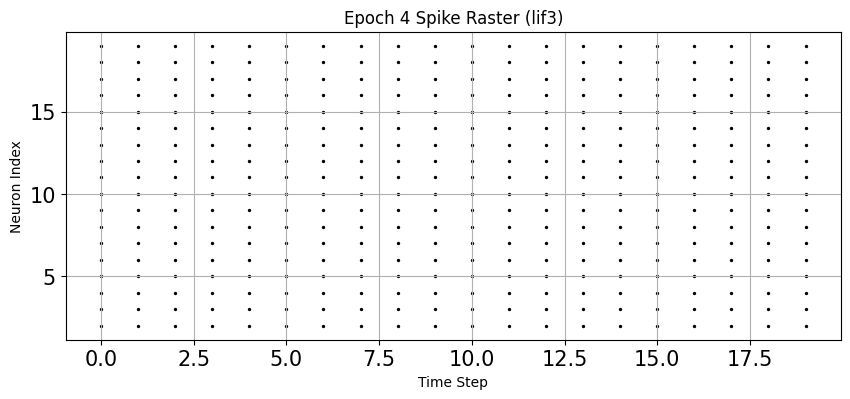

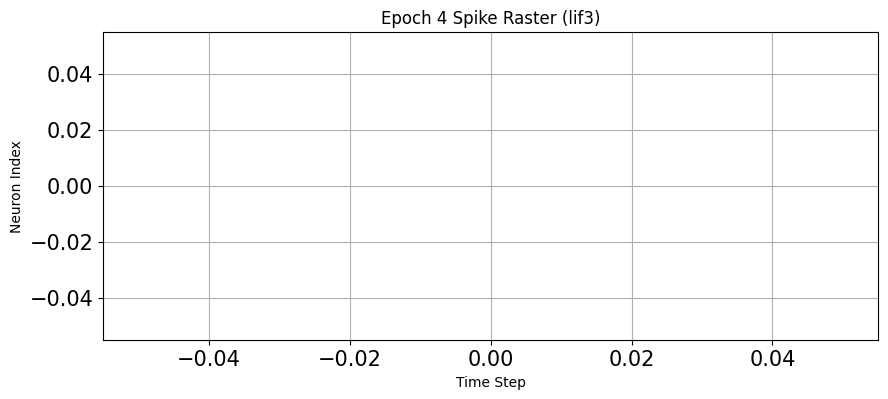

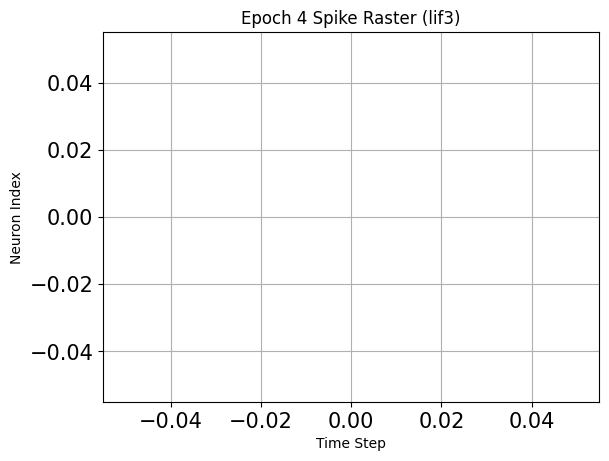

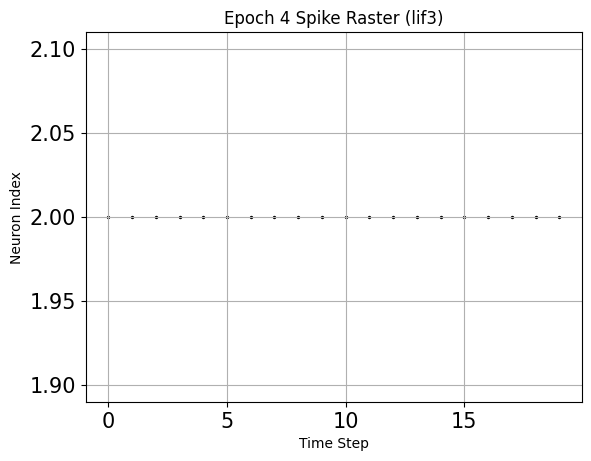

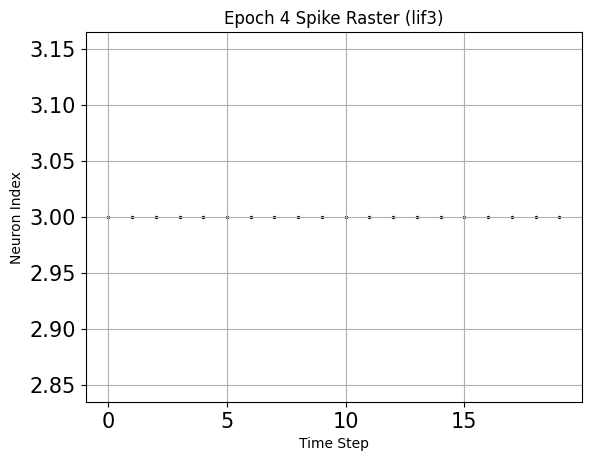

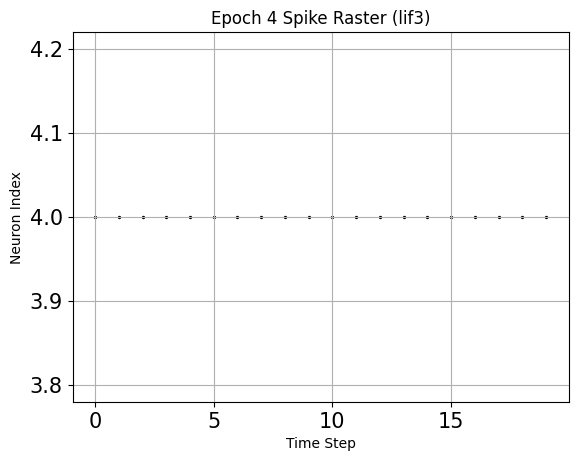

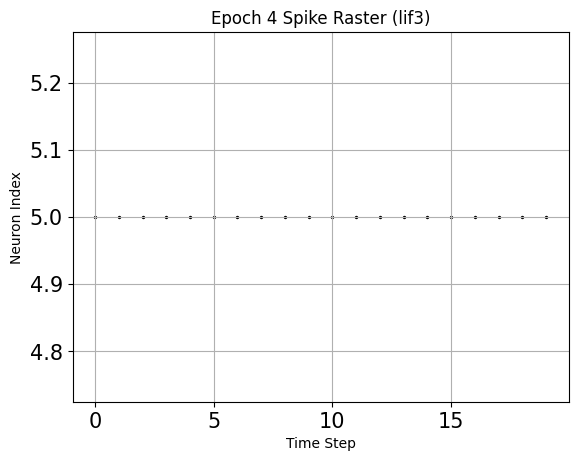

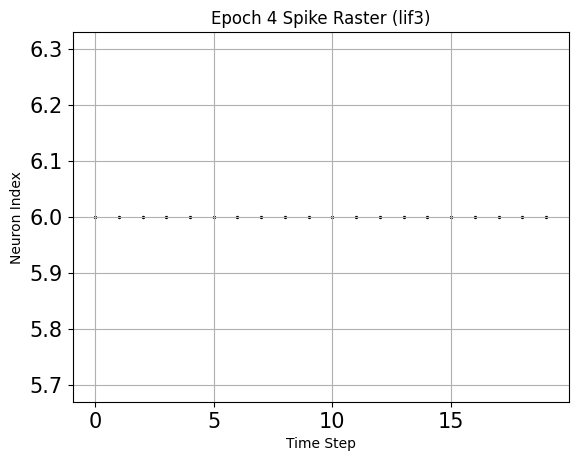

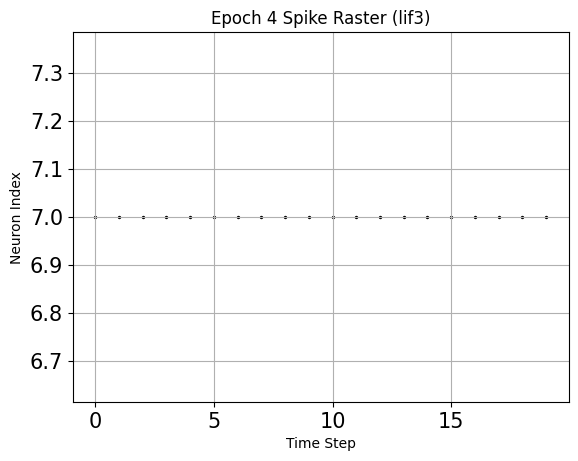

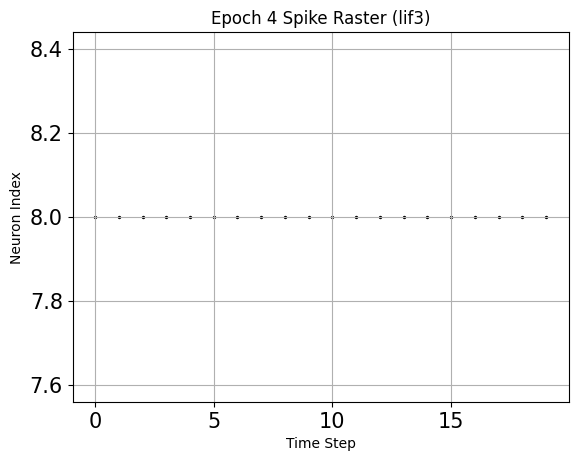

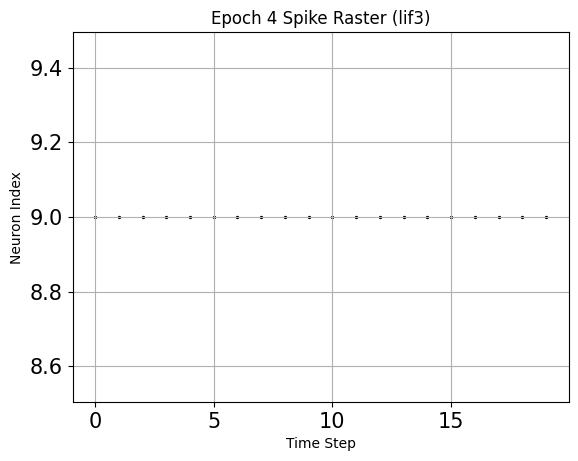

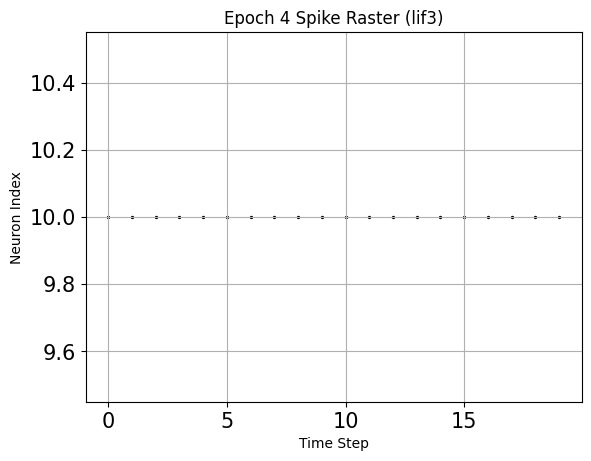

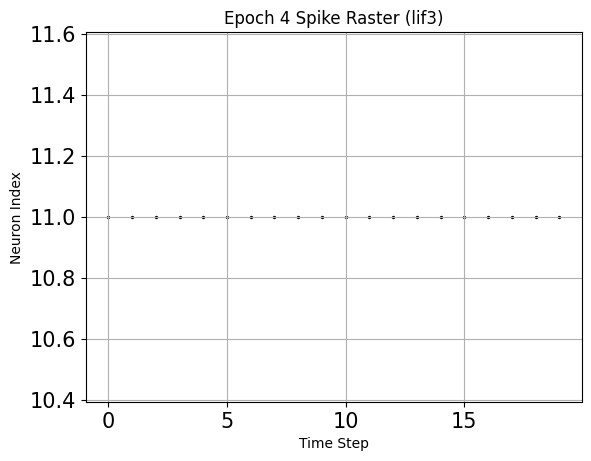

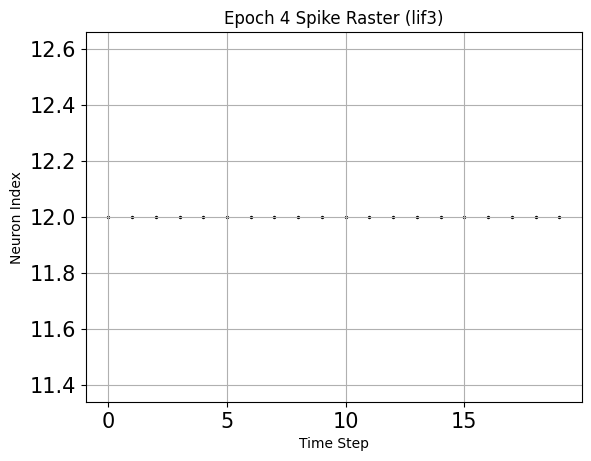

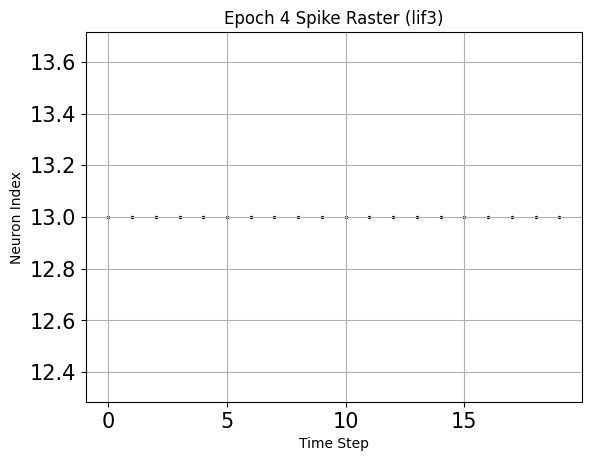

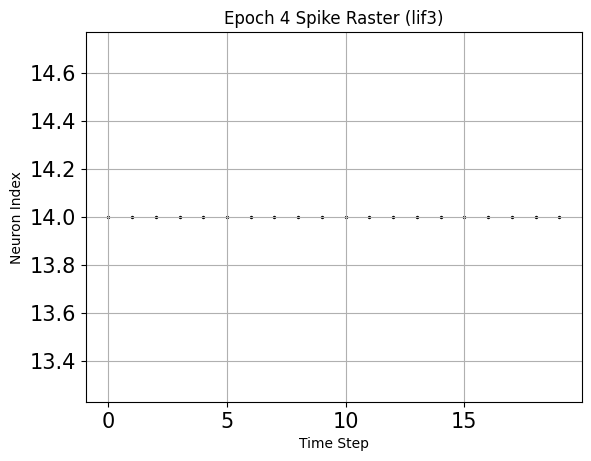

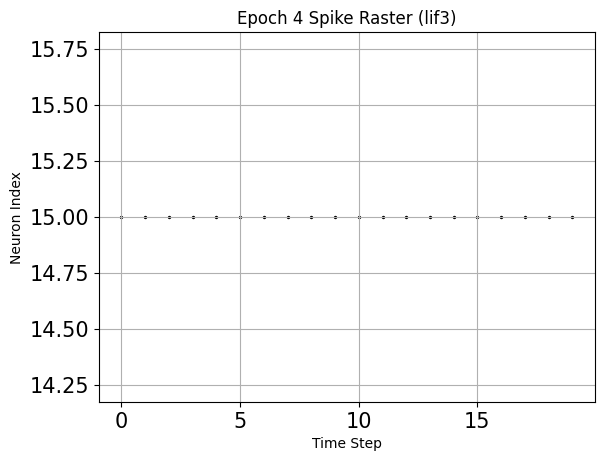

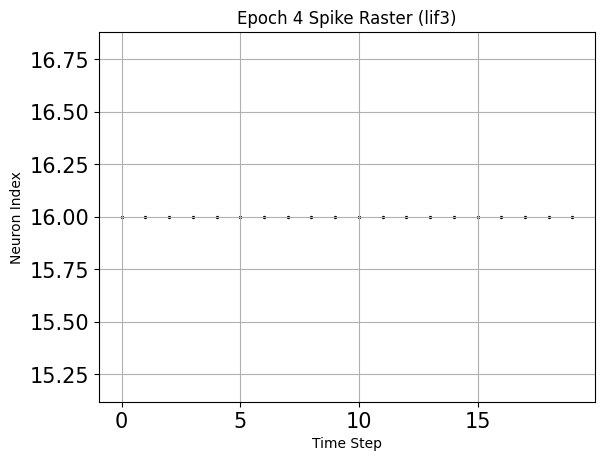

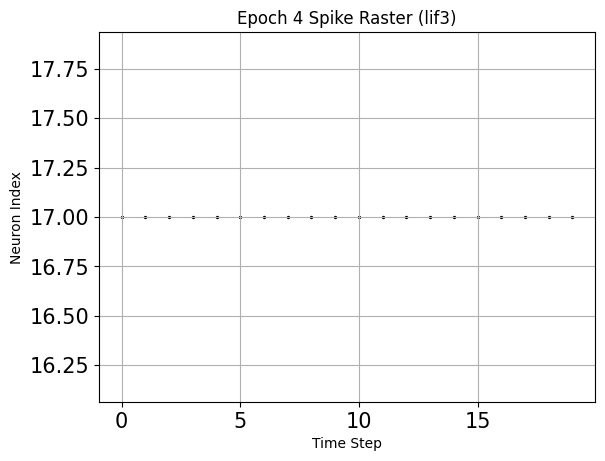

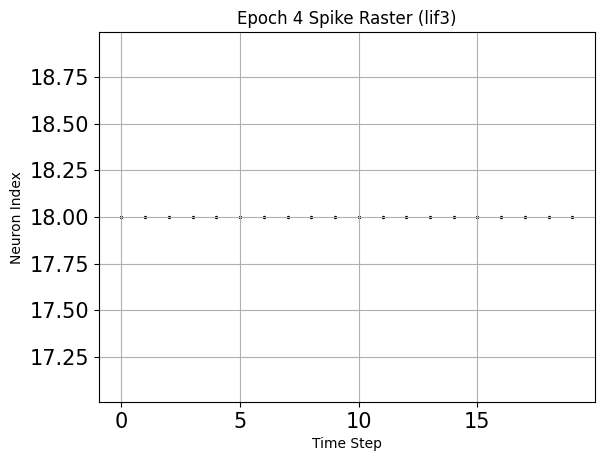

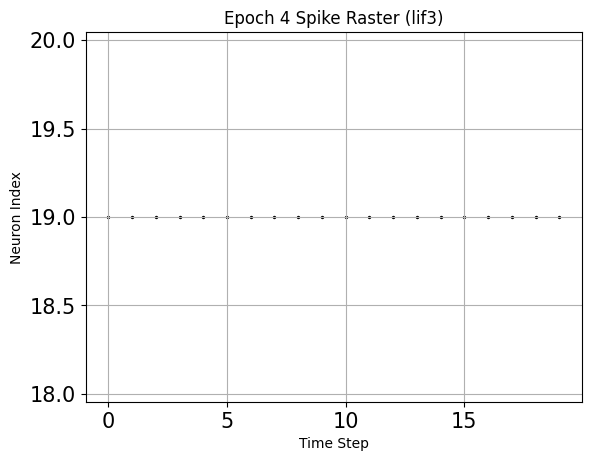


Epoch 5/10
📉 Prediction: 31.5386, True: -0.9198, MAE: 32.4584, RMSE: 32.4584
Total Energy: 0.000750 J
⚡ Total Energy (Loihi-style): 0.000750 J

RingSNN Total Energy: 0.0068 J
RingSNN Energy per Sample: 675.28 µJ


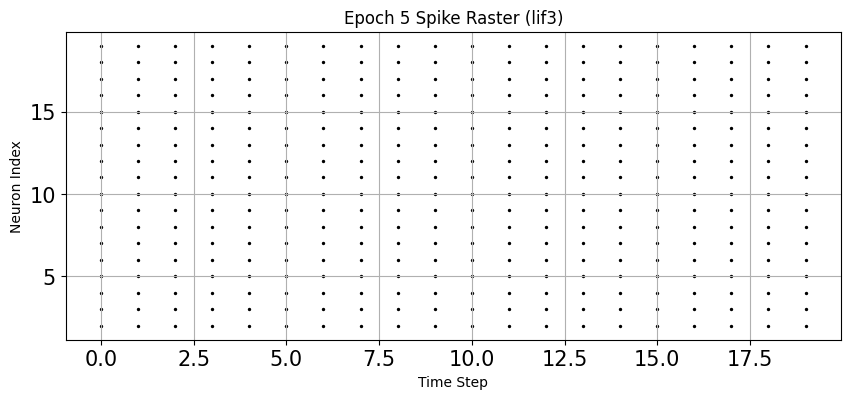

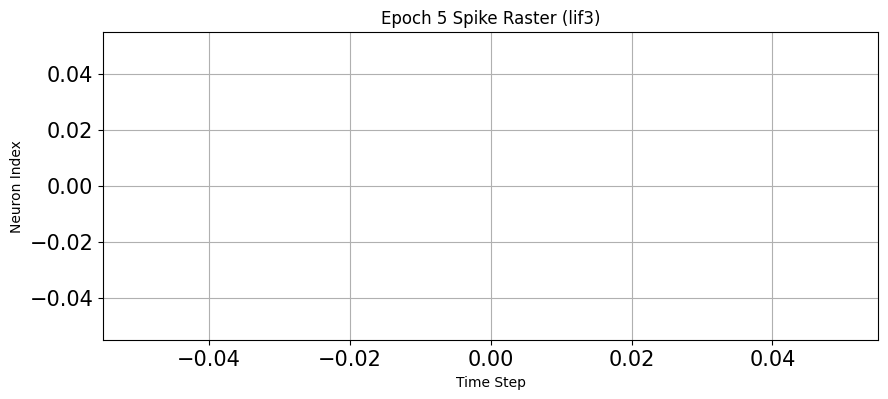

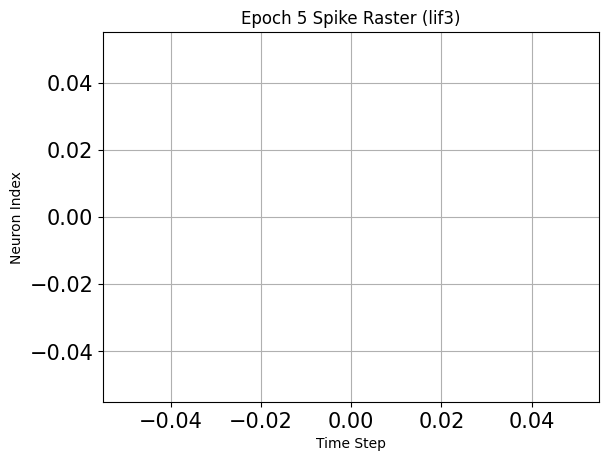

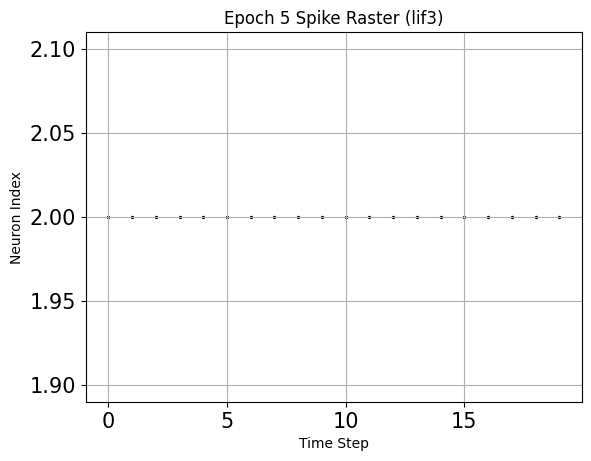

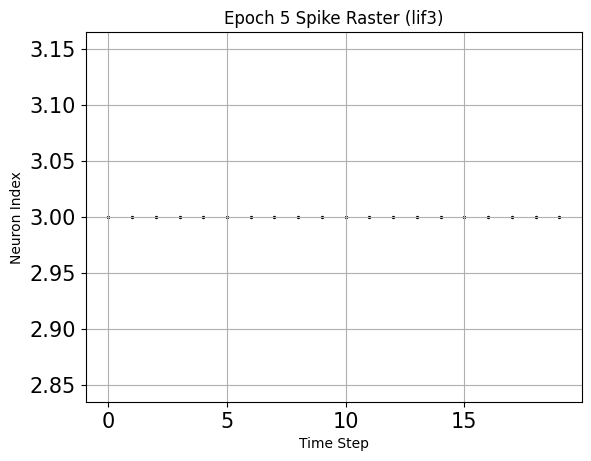

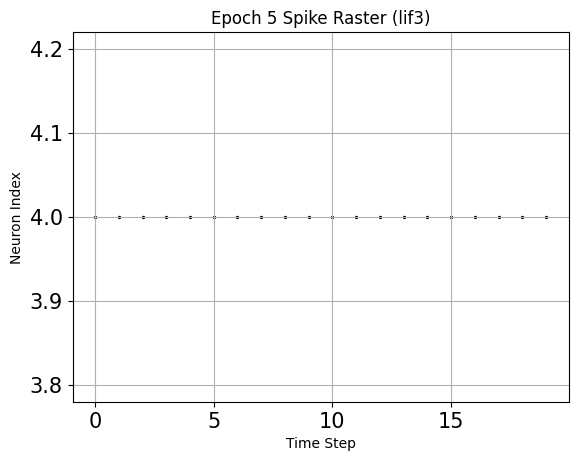

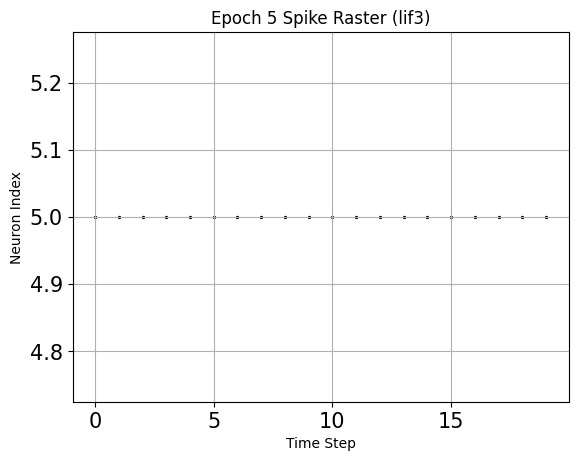

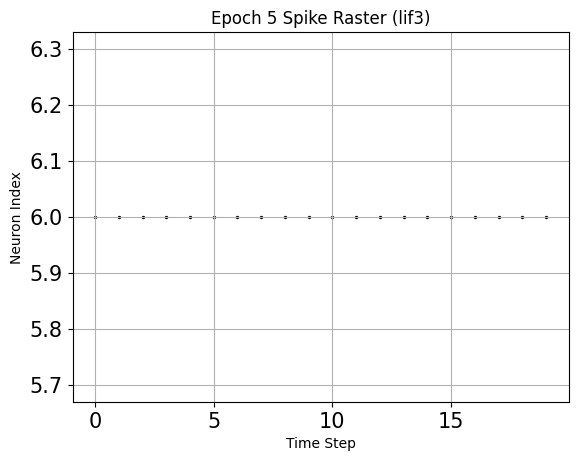

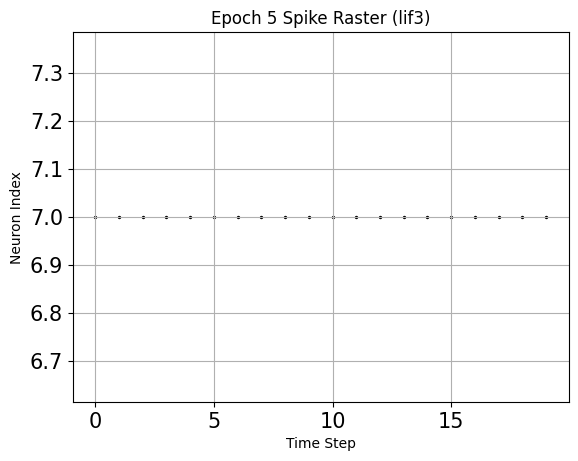

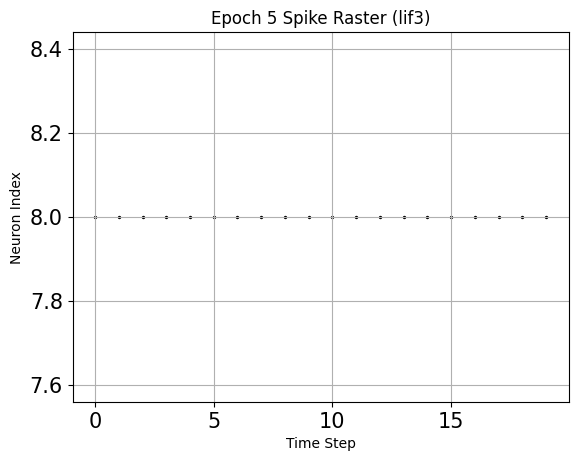

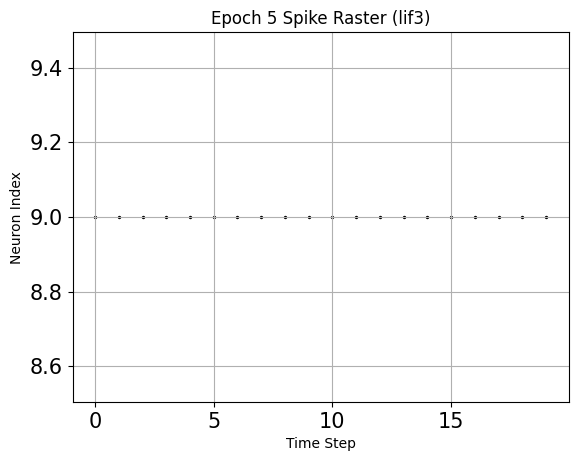

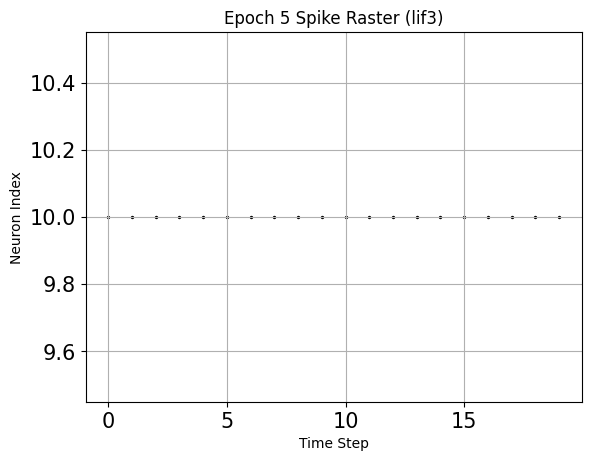

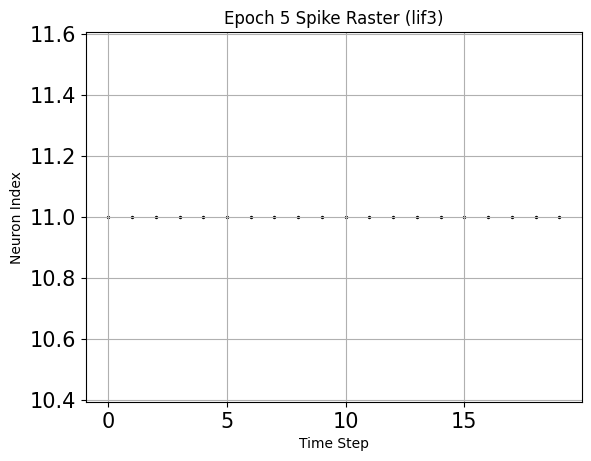

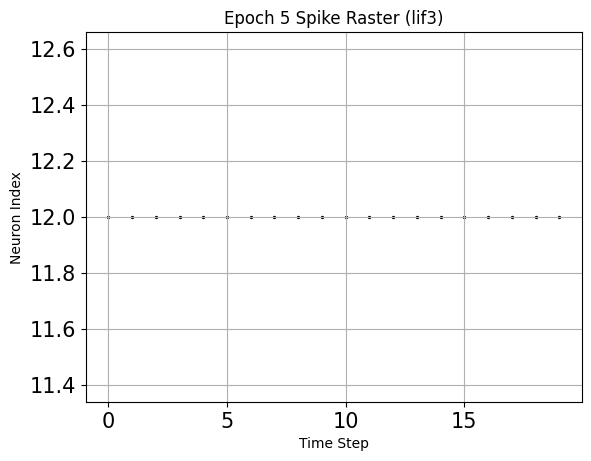

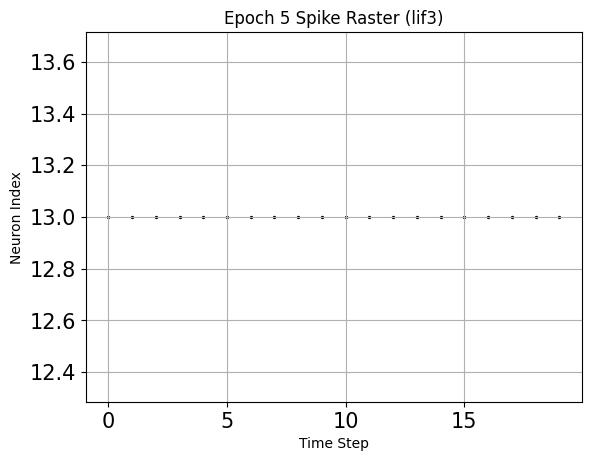

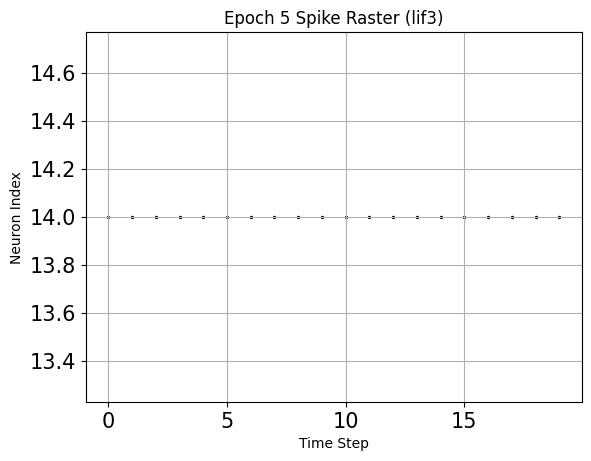

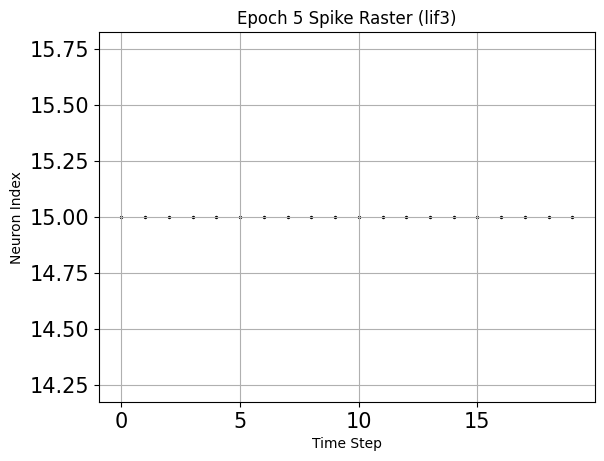

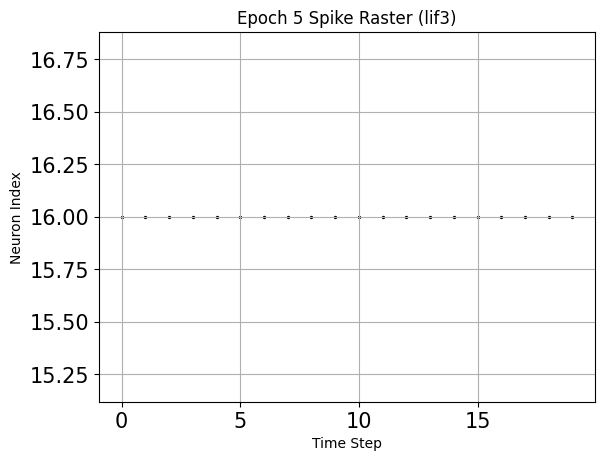

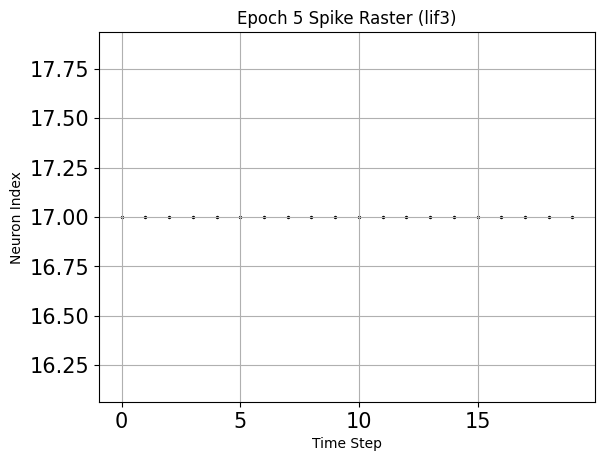

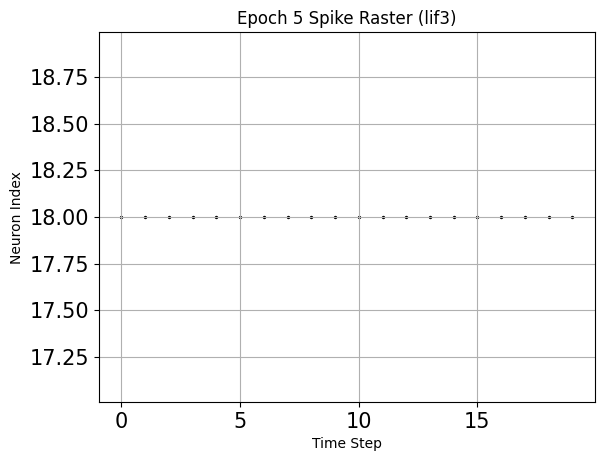

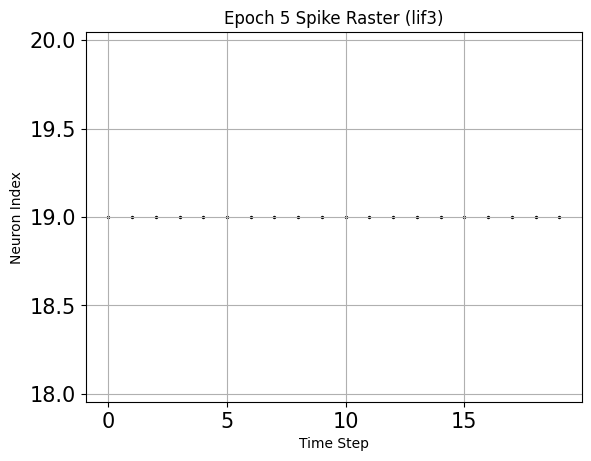


Epoch 6/10
📉 Prediction: 33.8628, True: -0.0665, MAE: 33.9293, RMSE: 33.9293
Total Energy: 0.000750 J
⚡ Total Energy (Loihi-style): 0.000750 J

RingSNN Total Energy: 0.0083 J
RingSNN Energy per Sample: 825.36 µJ


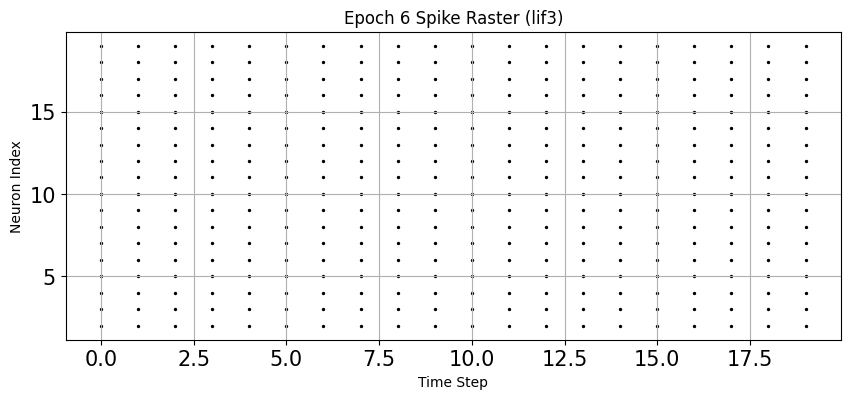

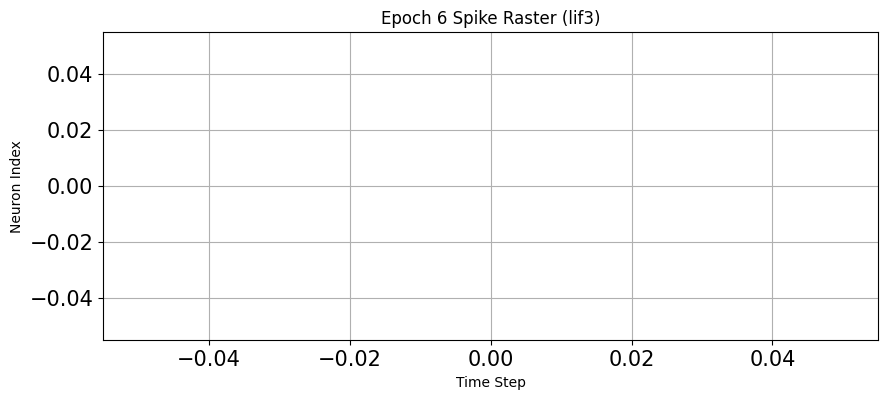

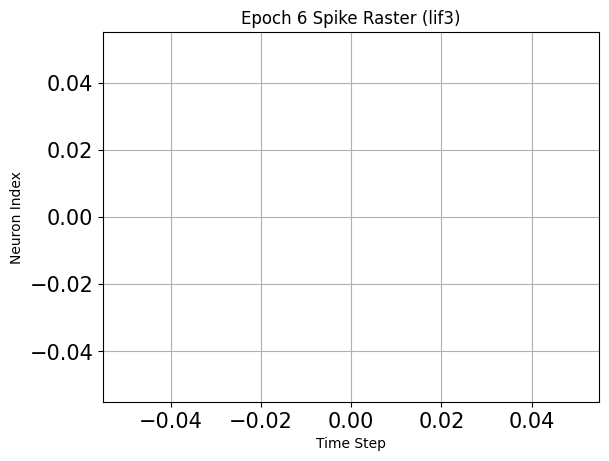

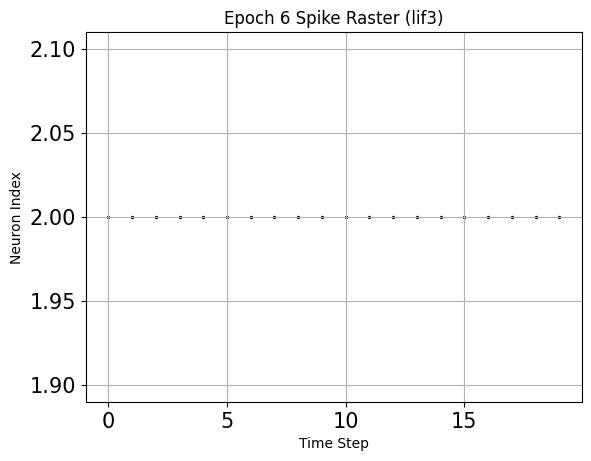

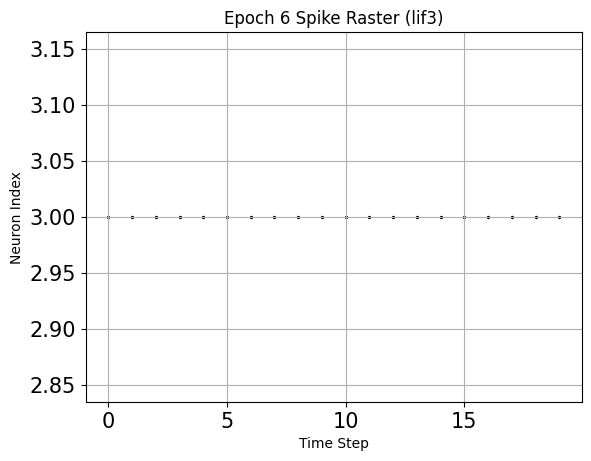

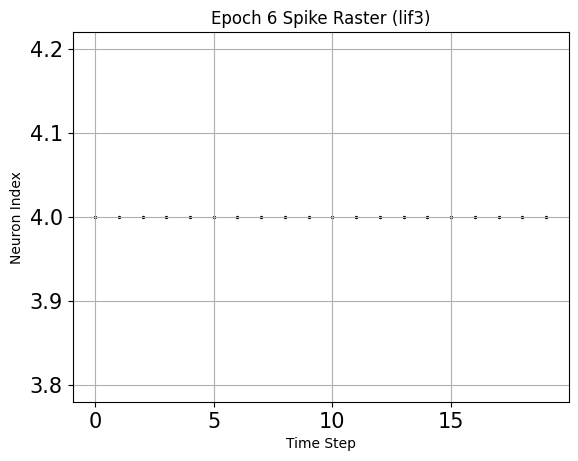

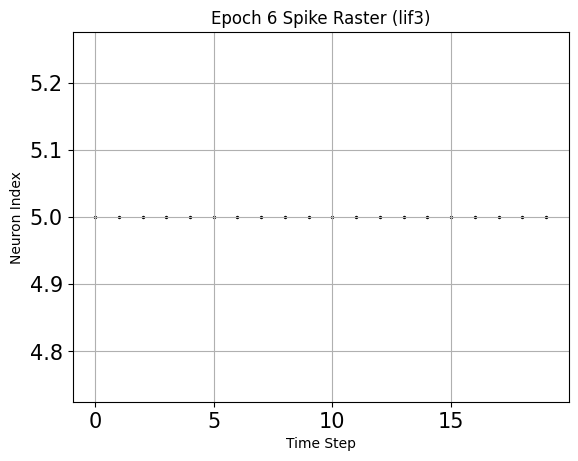

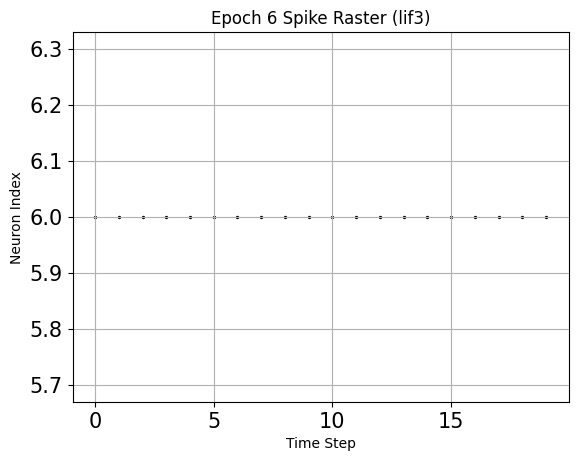

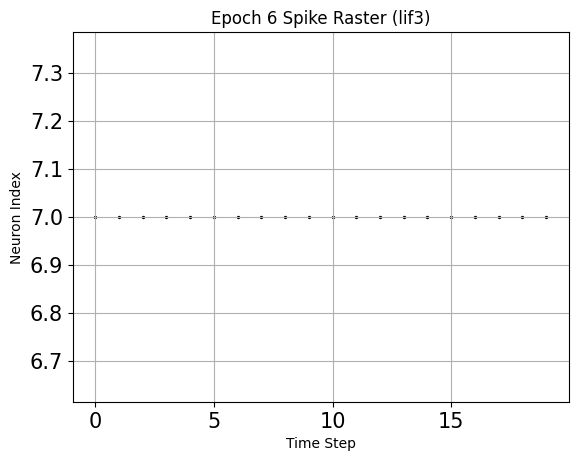

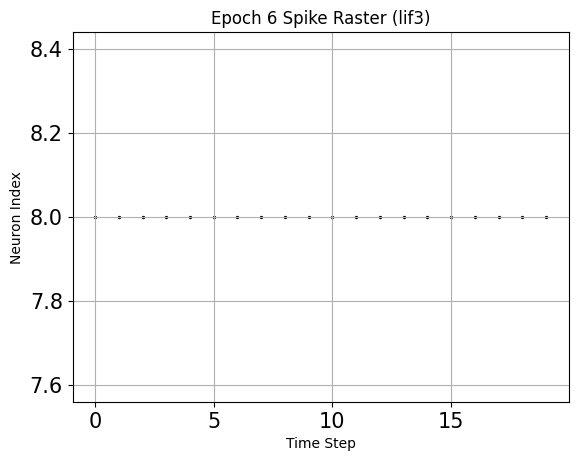

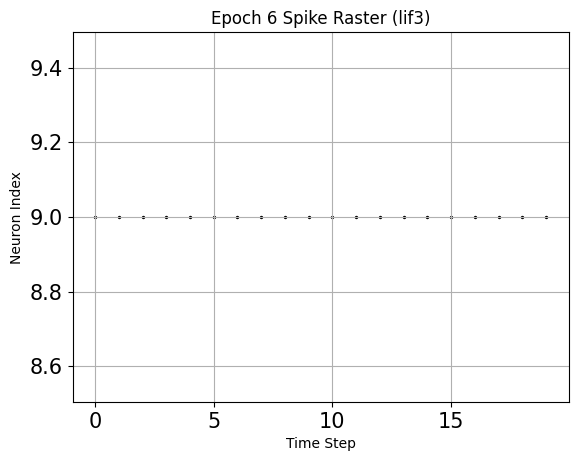

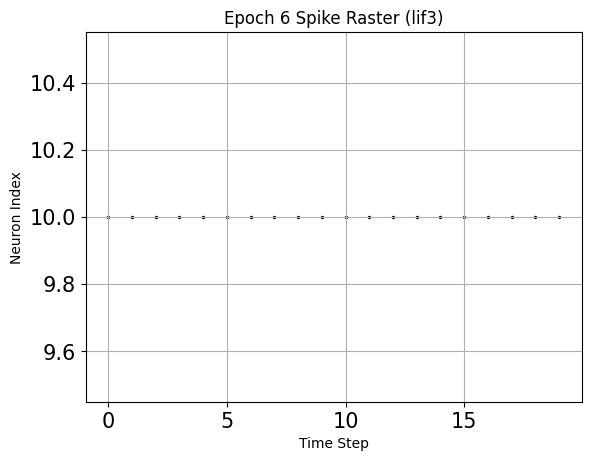

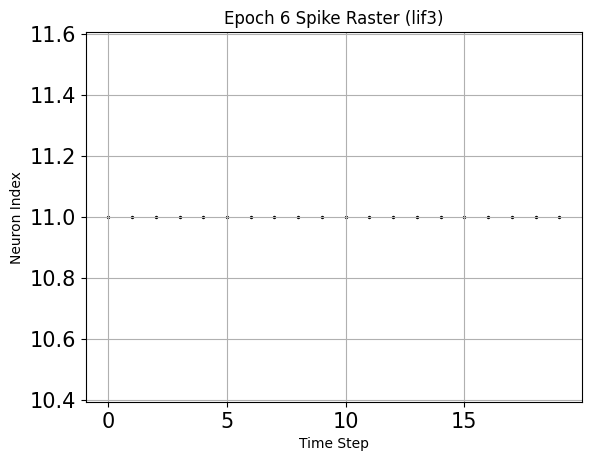

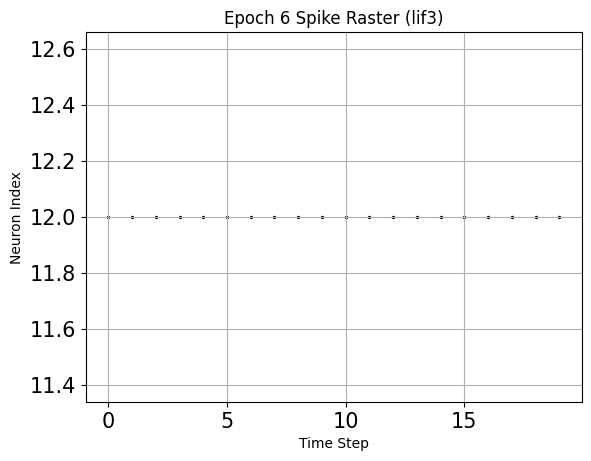

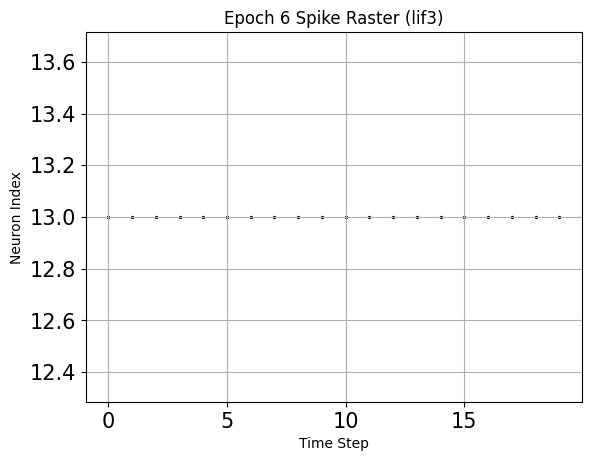

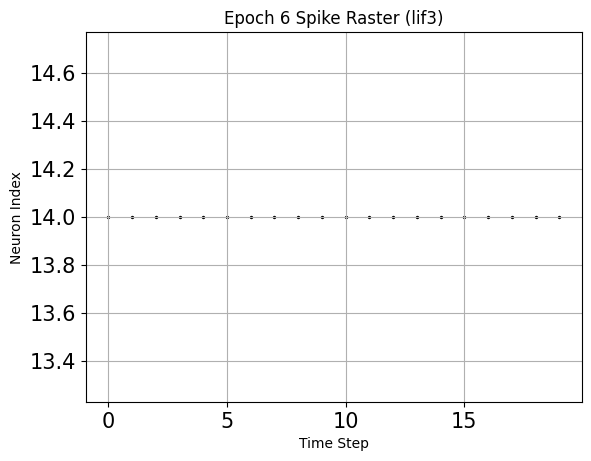

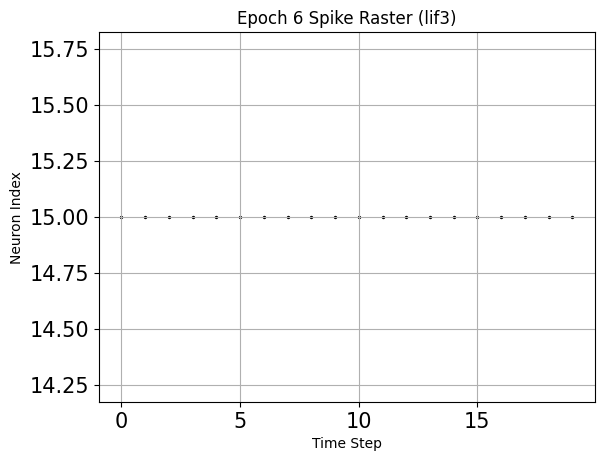

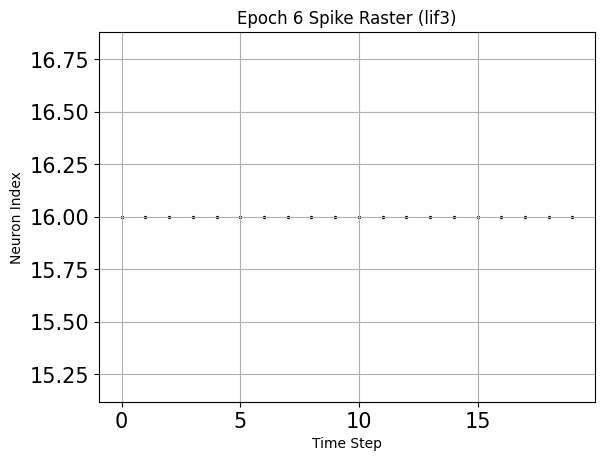

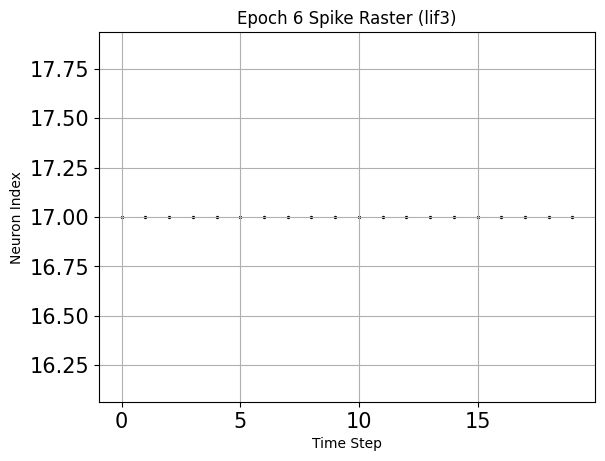

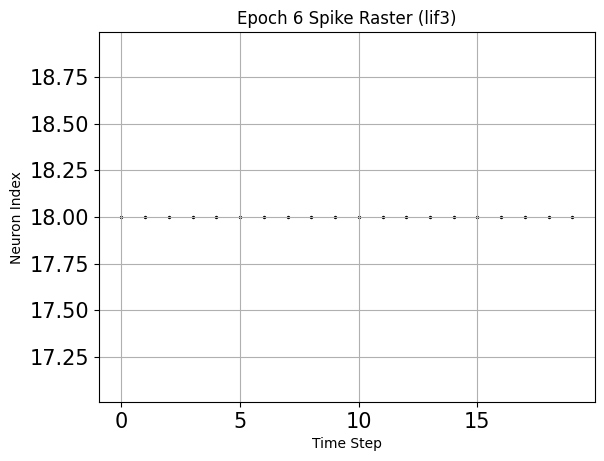

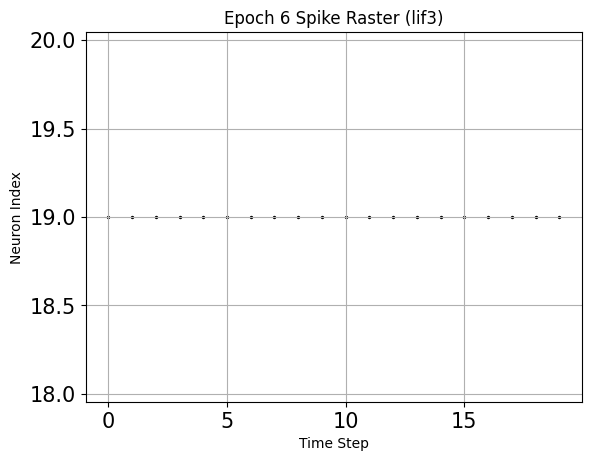


Epoch 7/10
📉 Prediction: 44.8539, True: -0.9260, MAE: 45.7799, RMSE: 45.7799
Total Energy: 0.000750 J
⚡ Total Energy (Loihi-style): 0.000750 J

RingSNN Total Energy: 0.0098 J
RingSNN Energy per Sample: 975.43 µJ


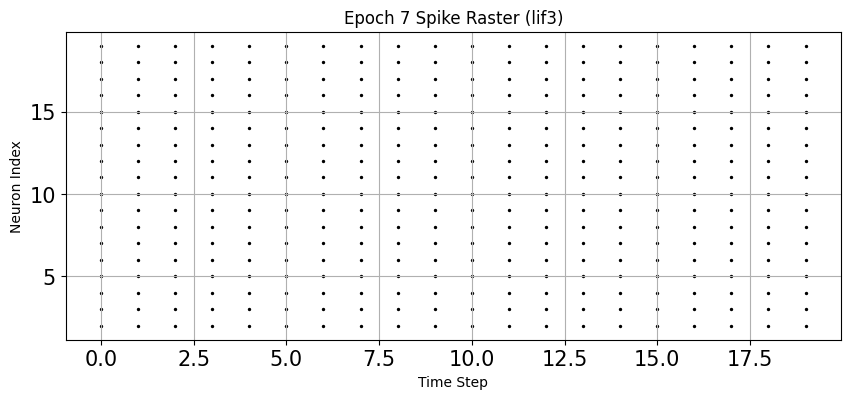

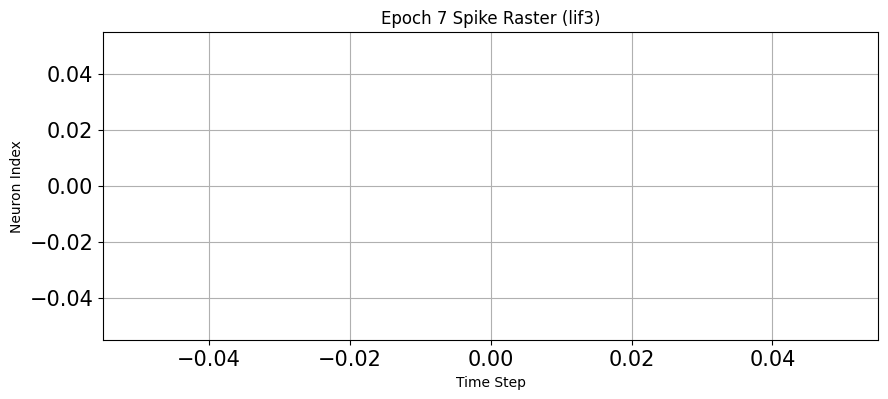

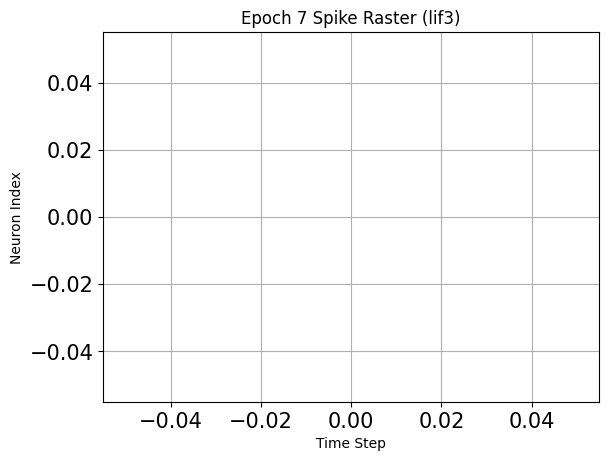

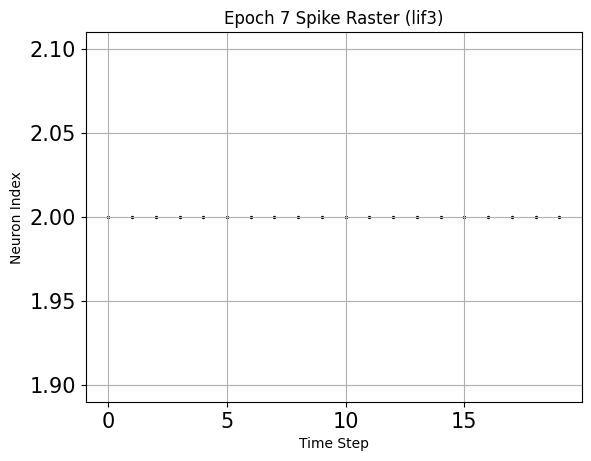

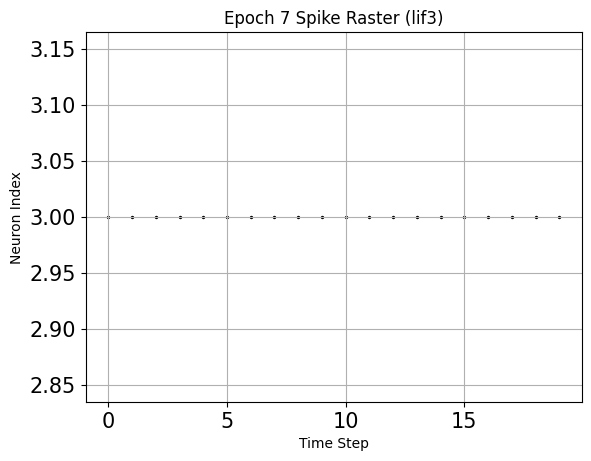

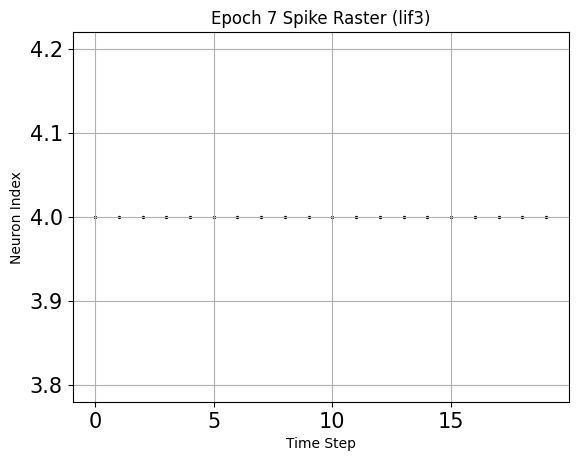

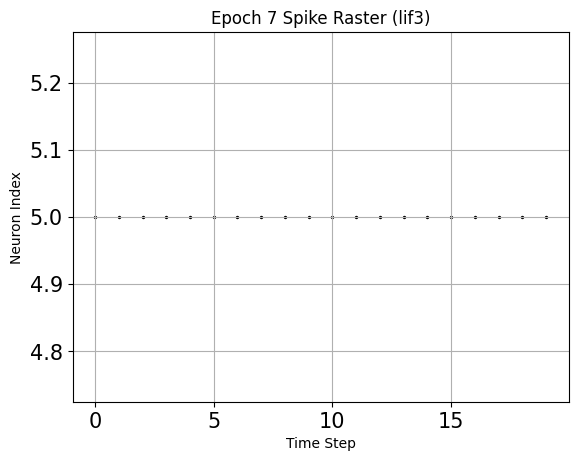

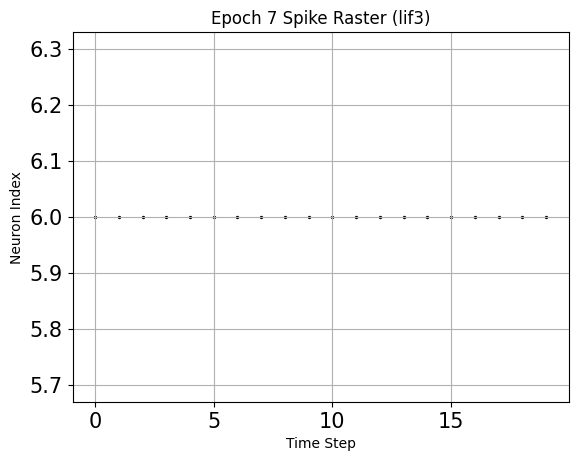

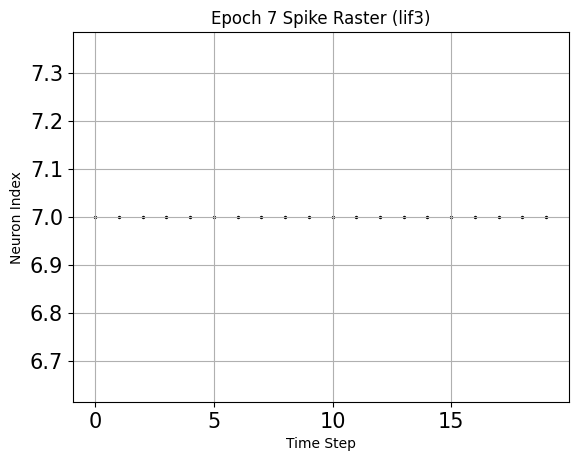

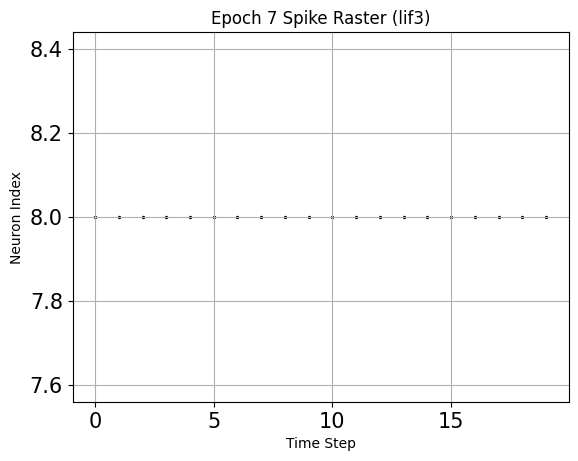

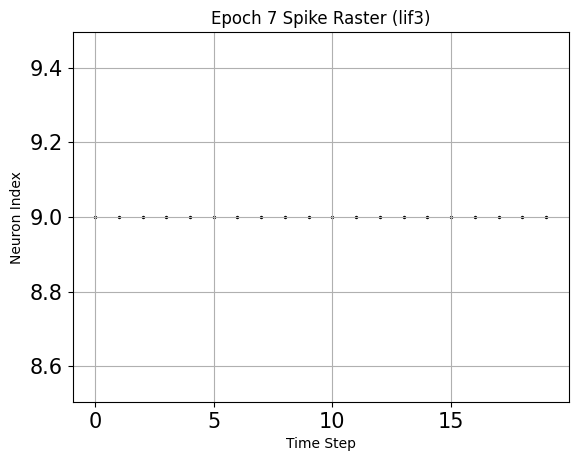

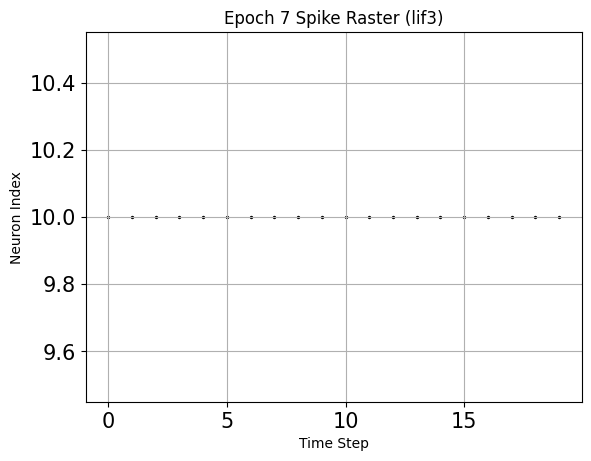

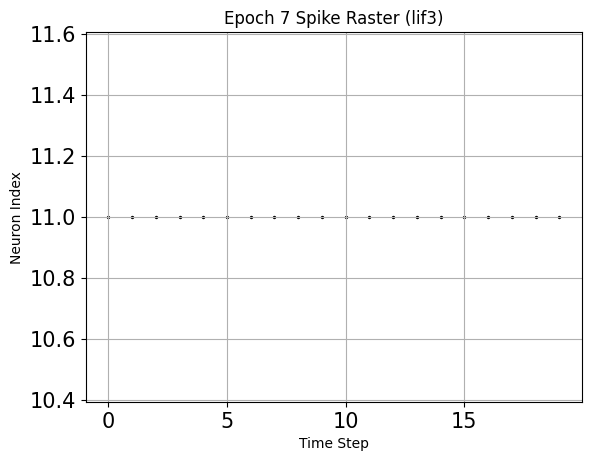

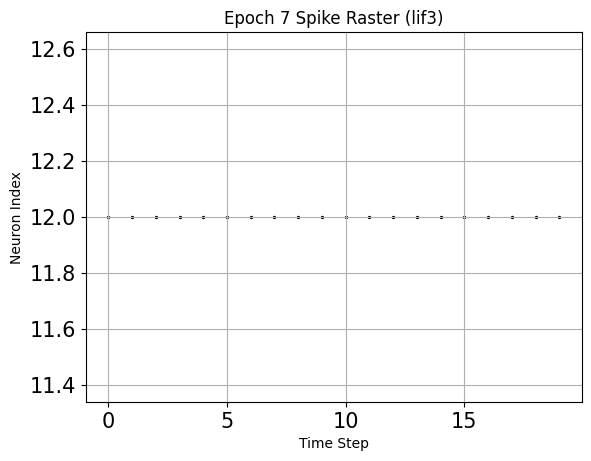

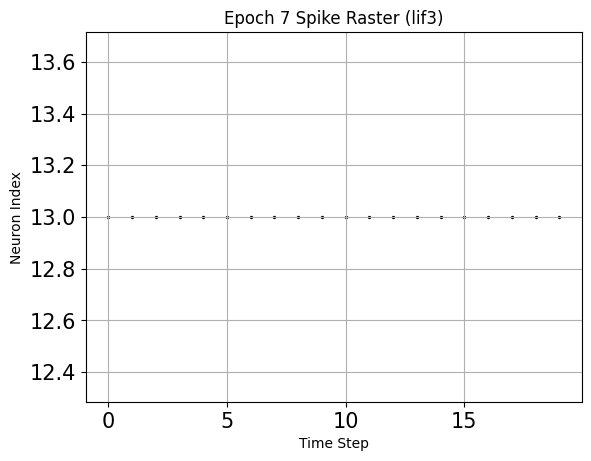

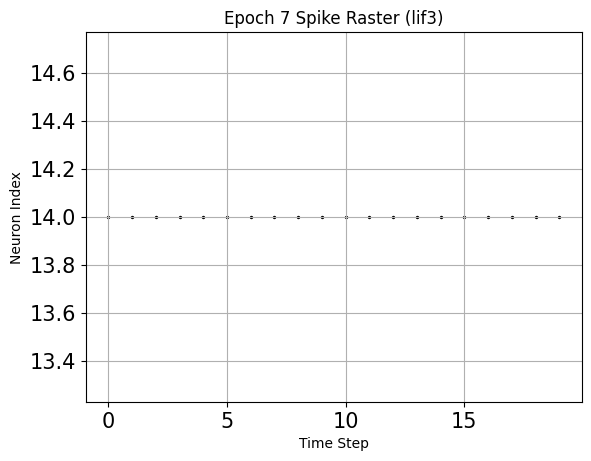

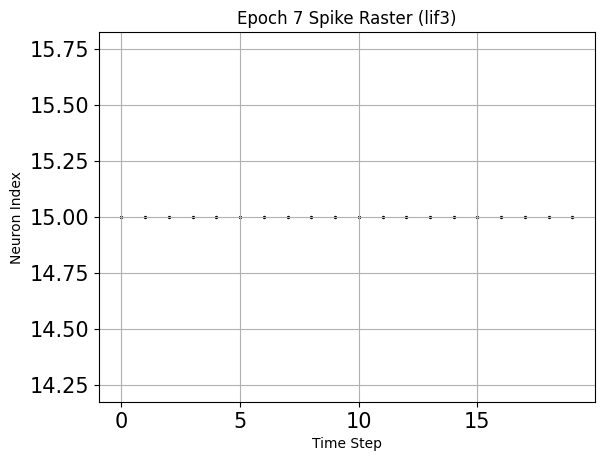

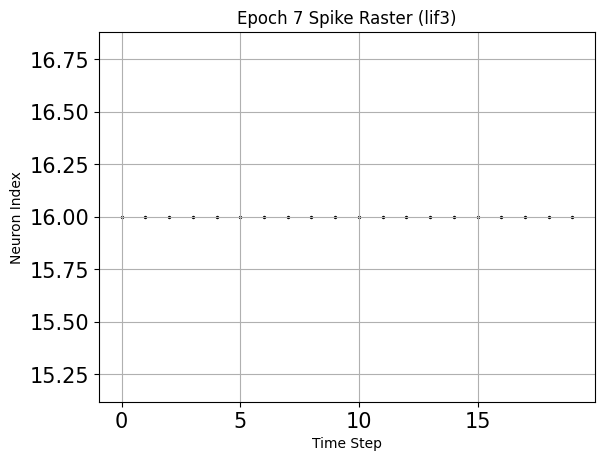

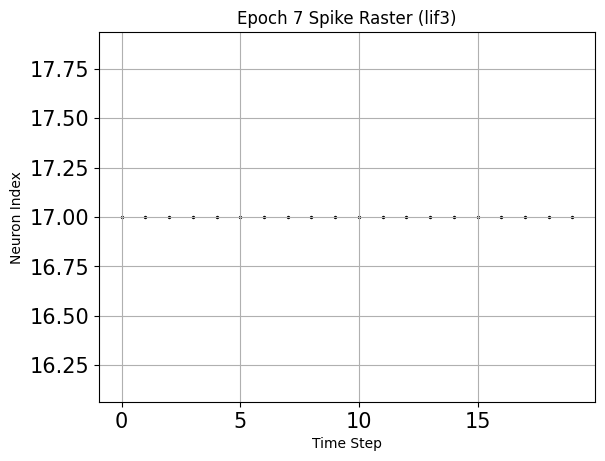

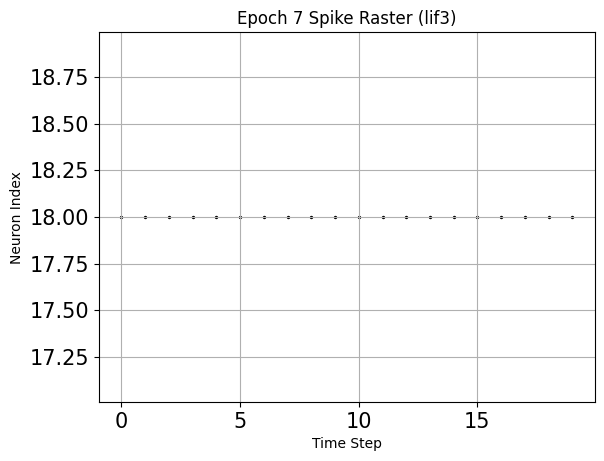

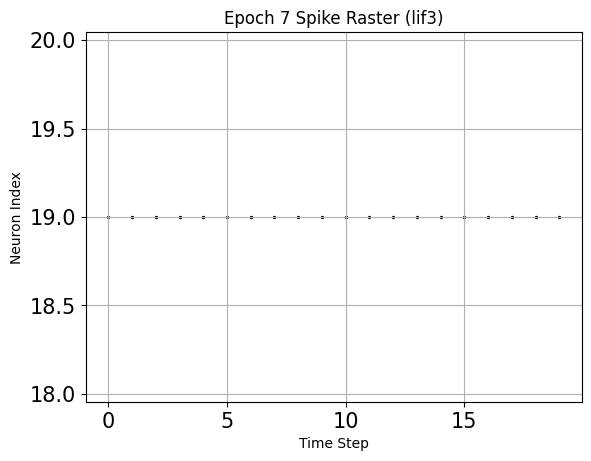


Epoch 8/10
📉 Prediction: 1.5964, True: 0.1113, MAE: 1.4851, RMSE: 1.4851
Total Energy: 0.000750 J
⚡ Total Energy (Loihi-style): 0.000750 J

RingSNN Total Energy: 0.0113 J
RingSNN Energy per Sample: 1125.51 µJ


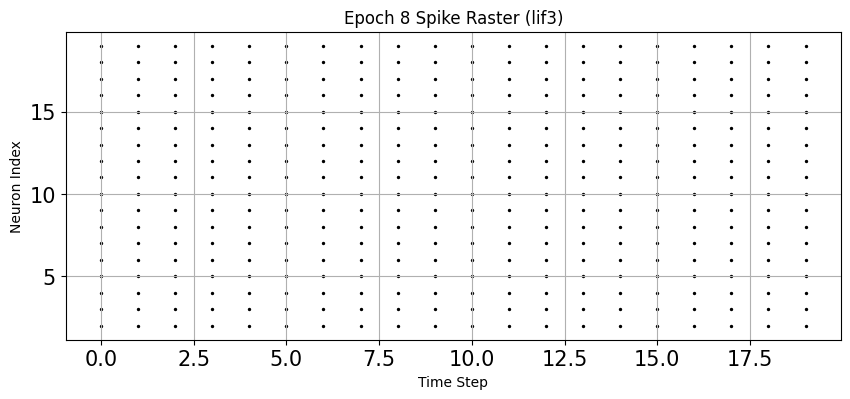

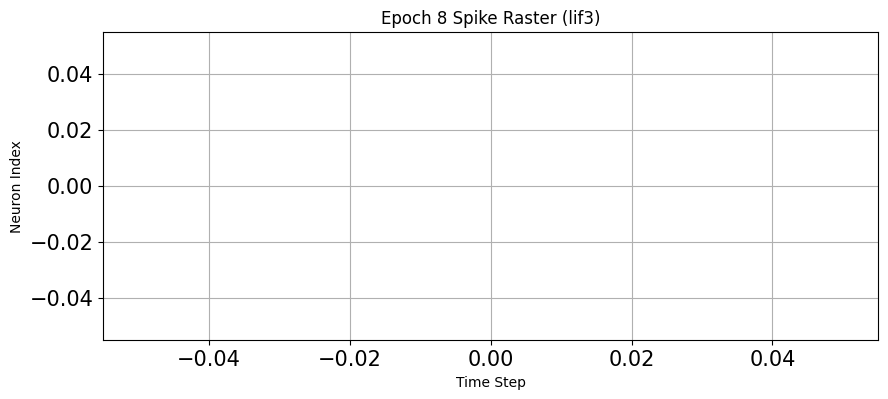

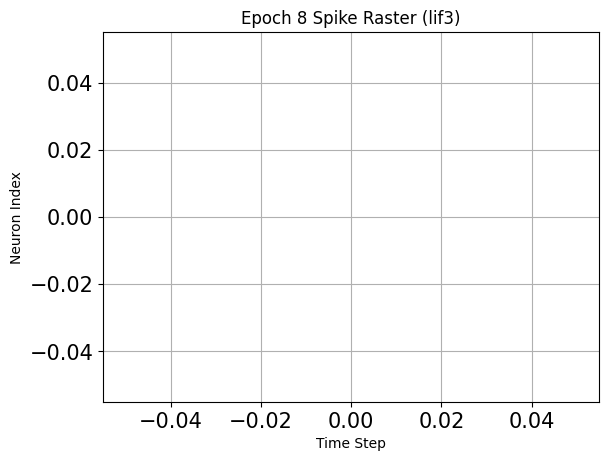

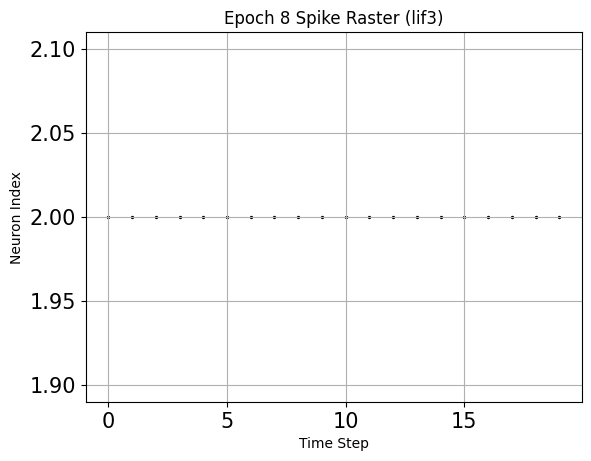

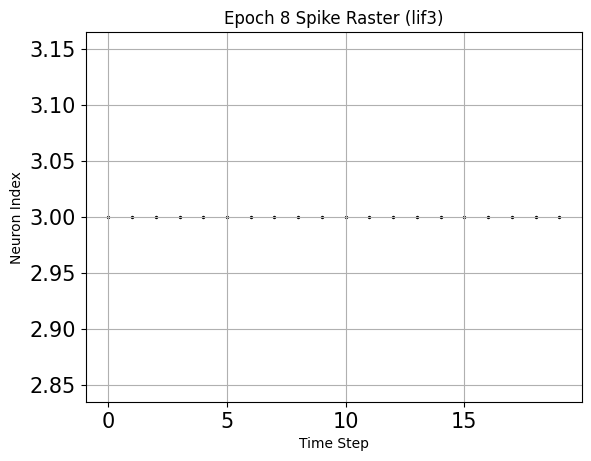

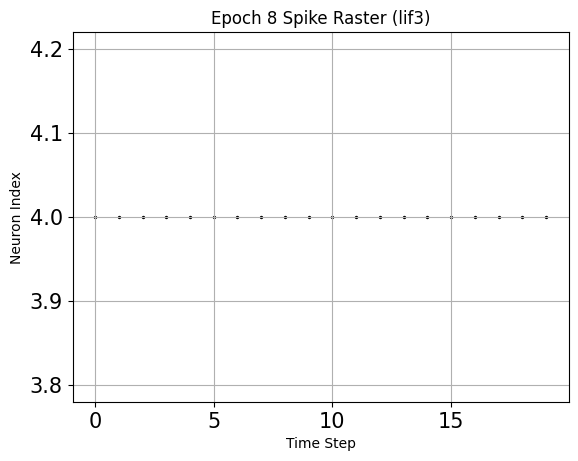

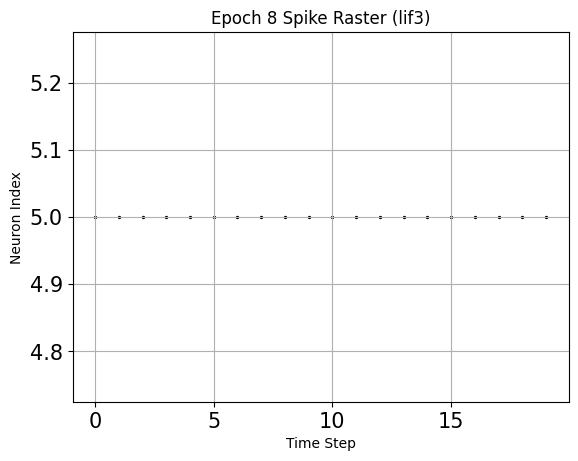

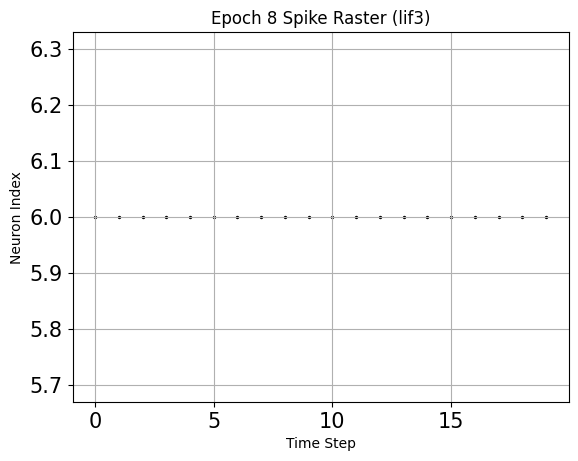

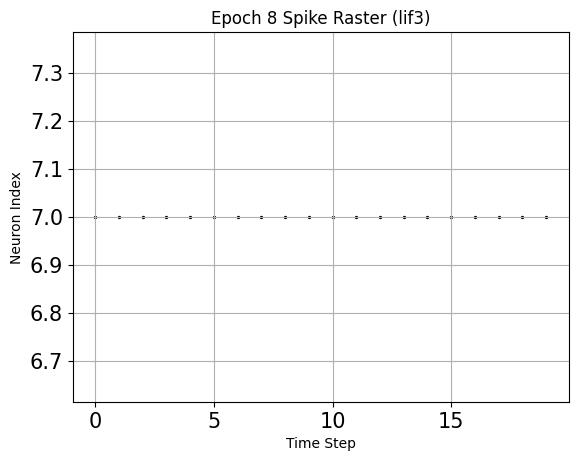

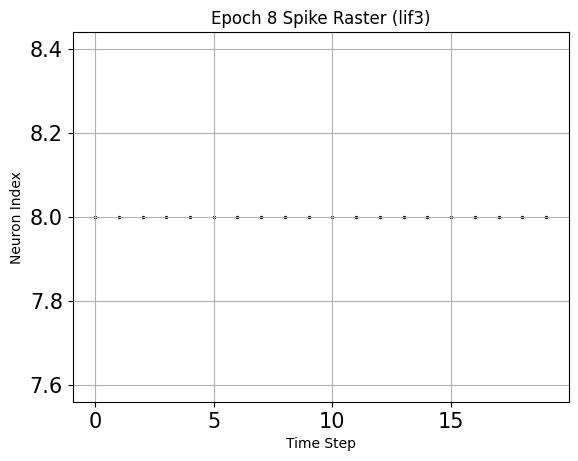

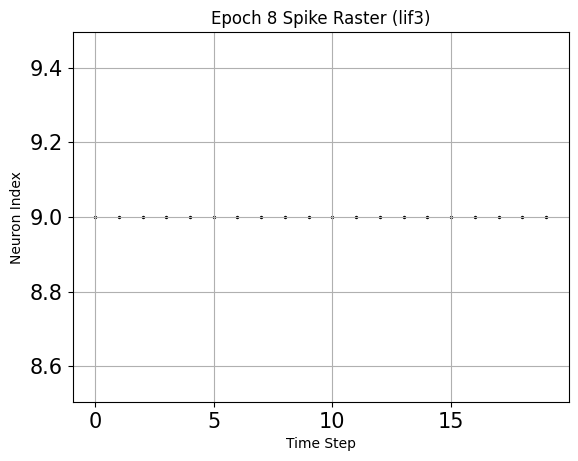

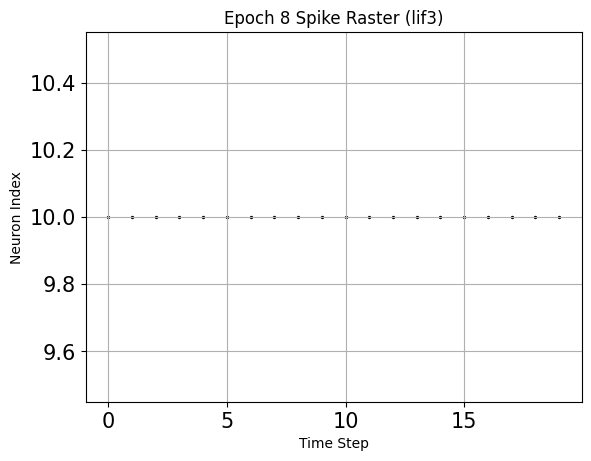

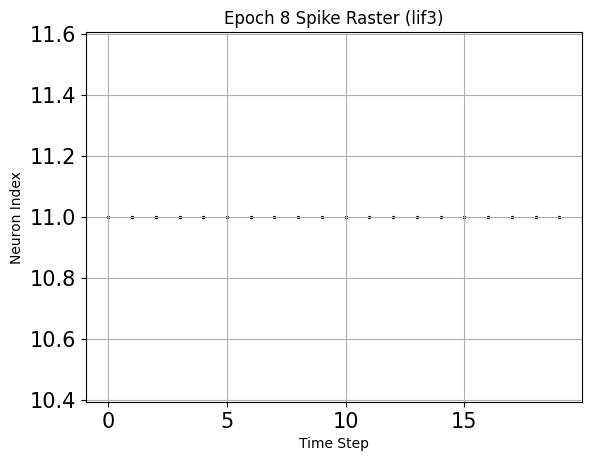

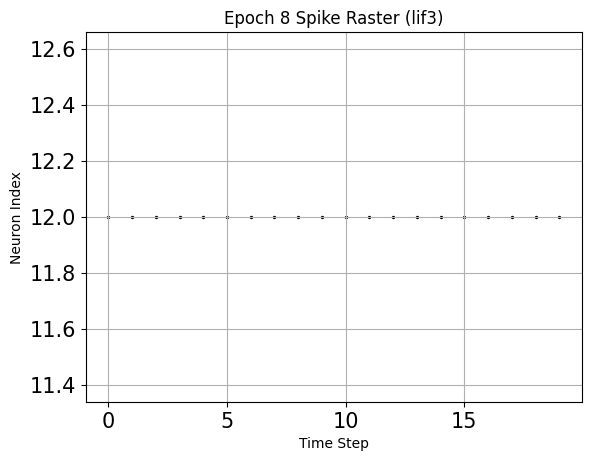

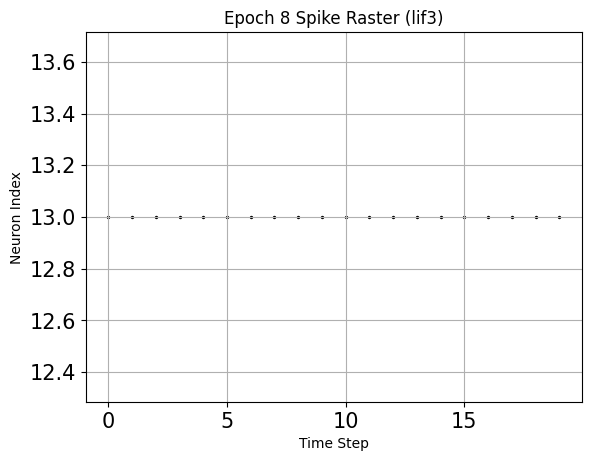

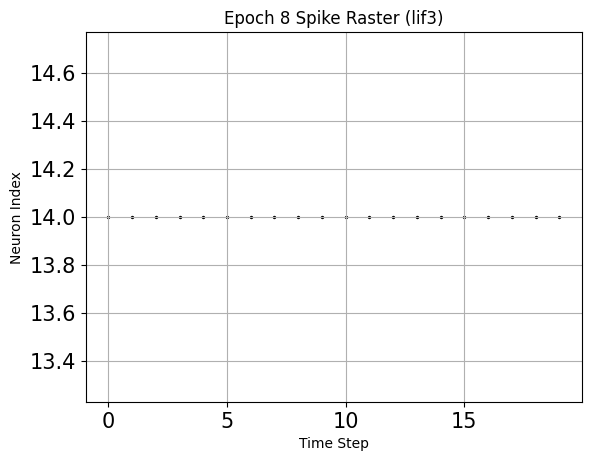

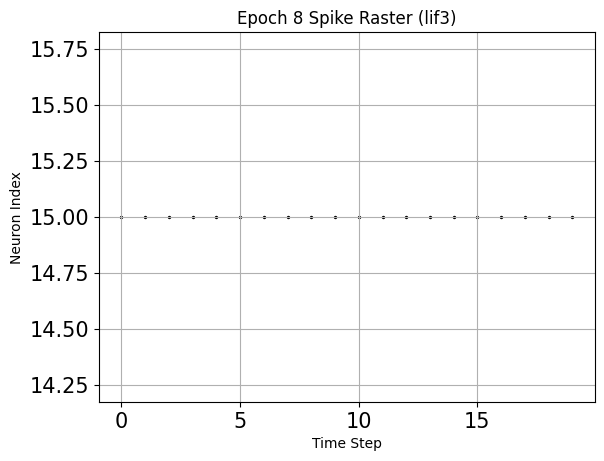

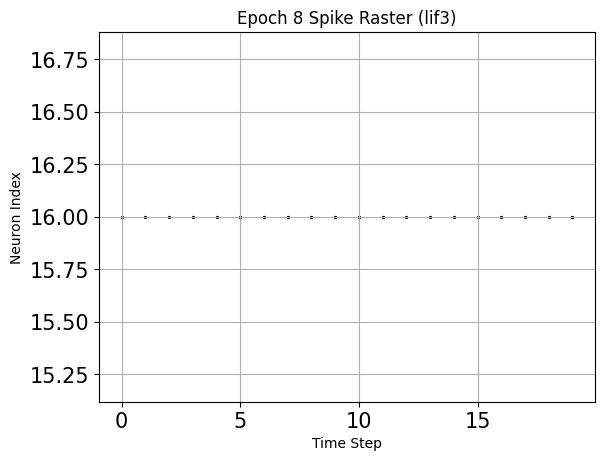

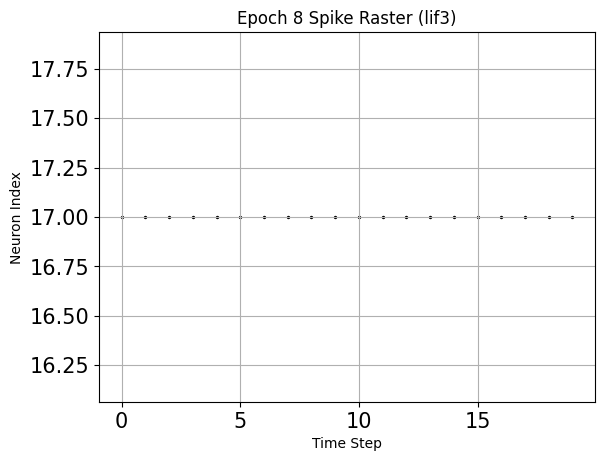

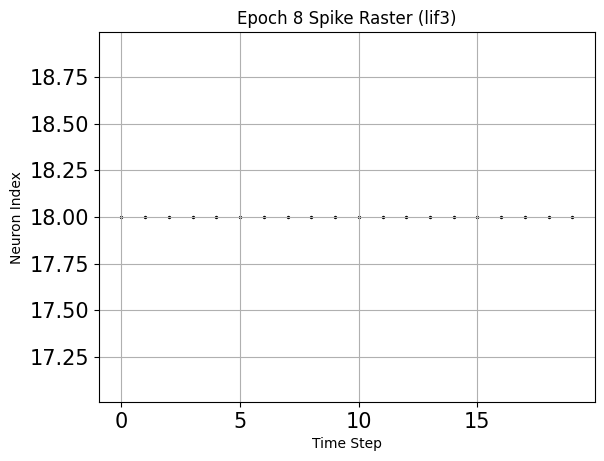

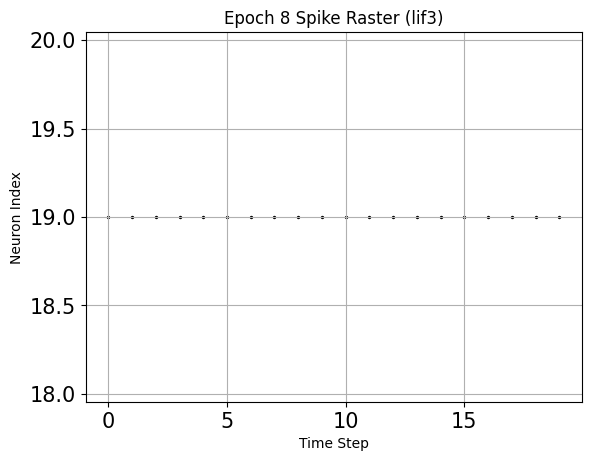


Epoch 9/10
📉 Prediction: -7.7112, True: -0.8445, MAE: 6.8667, RMSE: 6.8667
Total Energy: 0.000750 J
⚡ Total Energy (Loihi-style): 0.000750 J

RingSNN Total Energy: 0.0128 J
RingSNN Energy per Sample: 1275.58 µJ


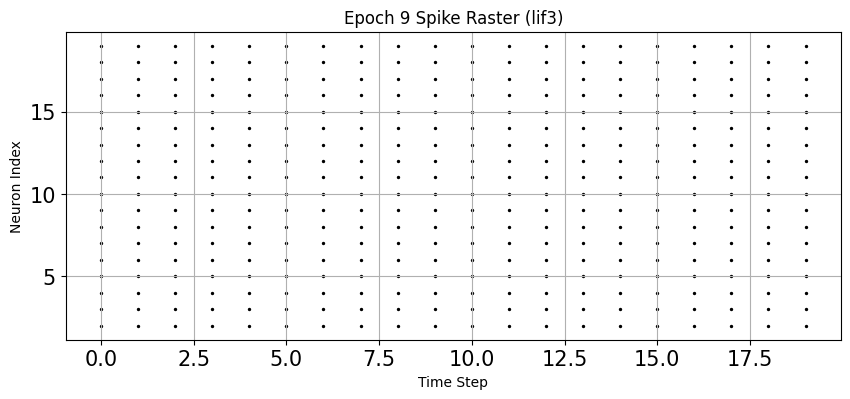

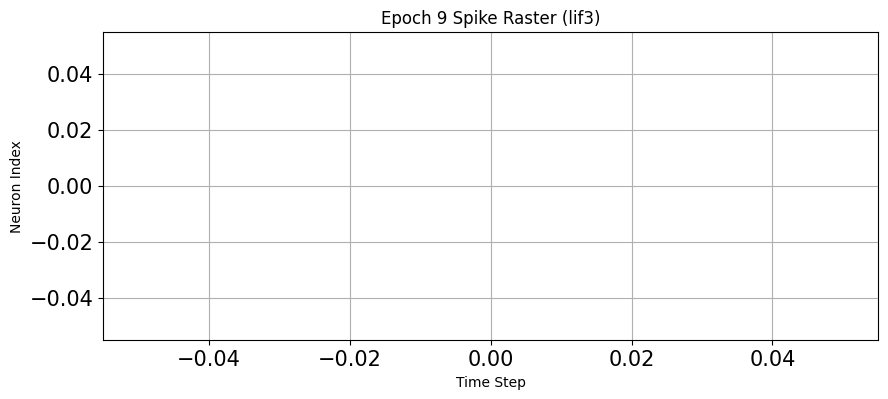

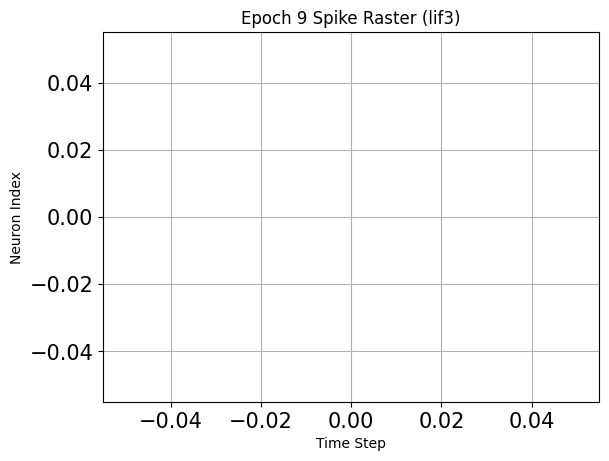

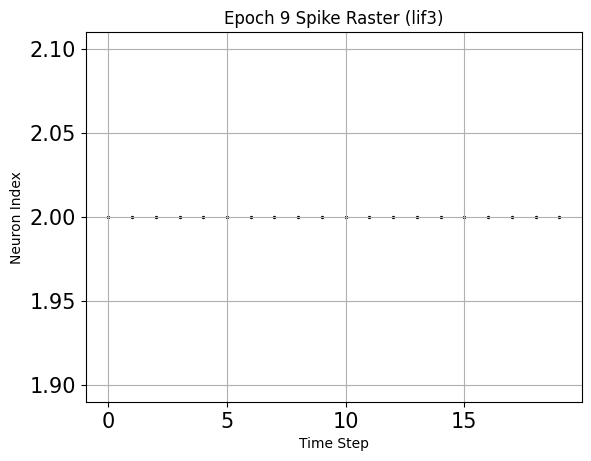

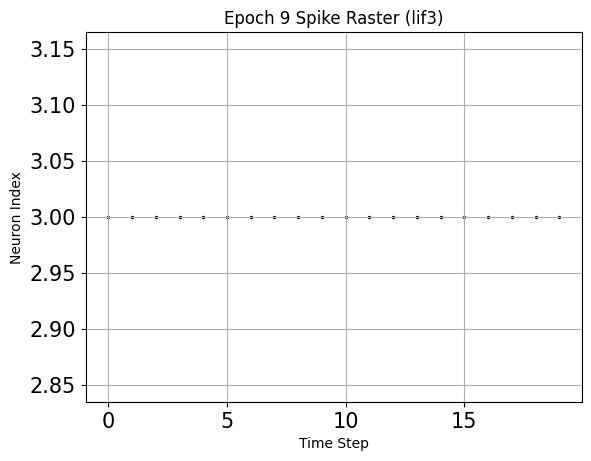

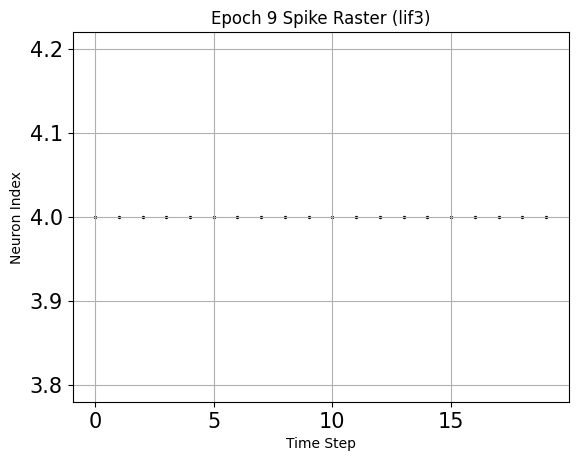

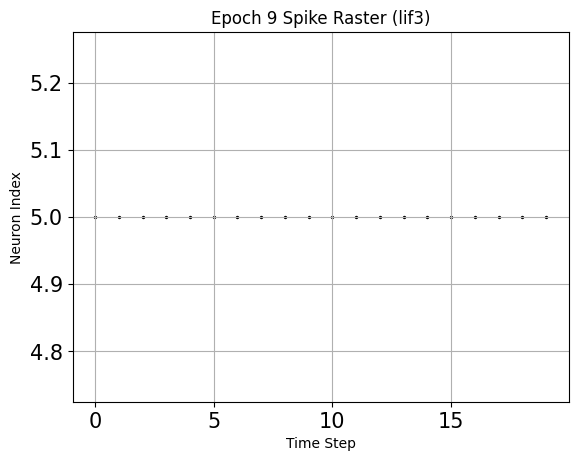

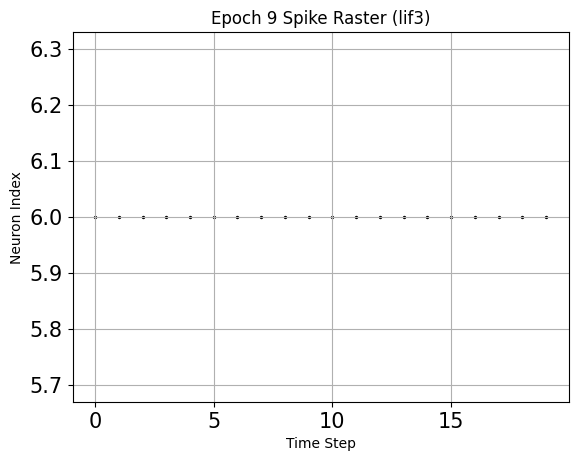

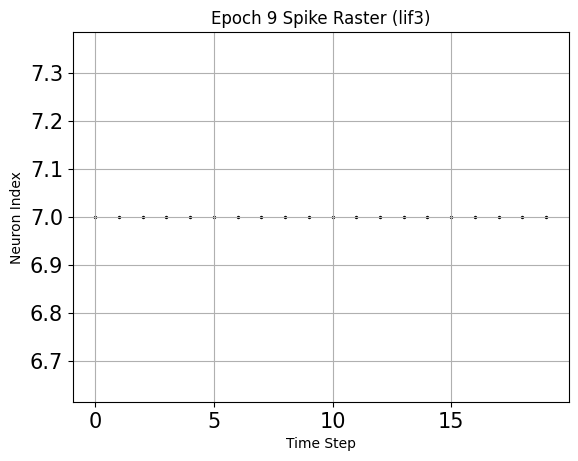

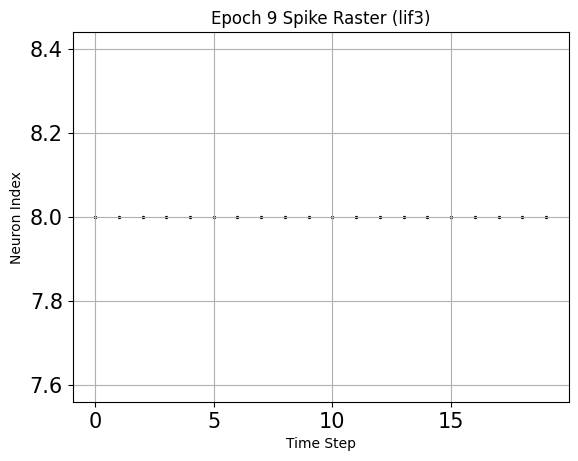

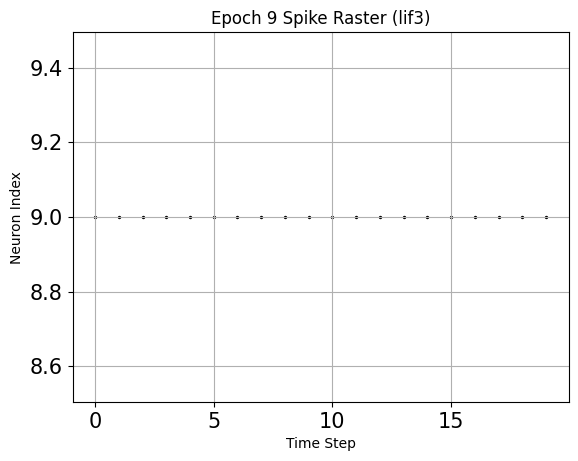

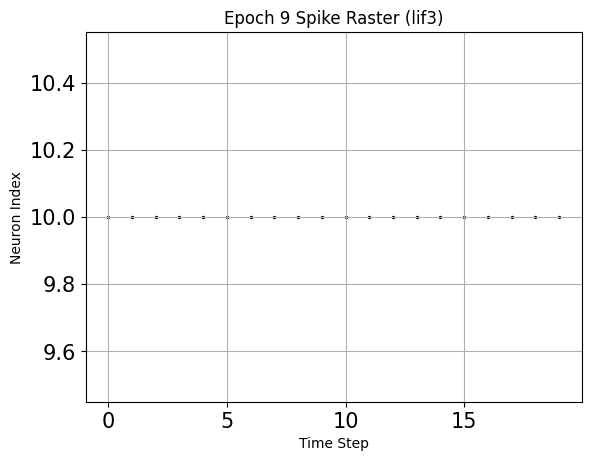

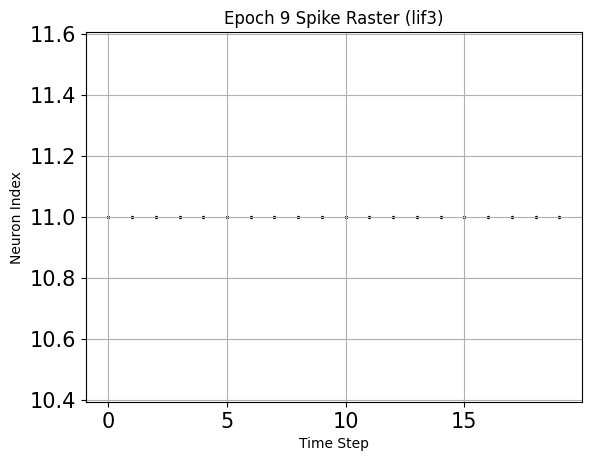

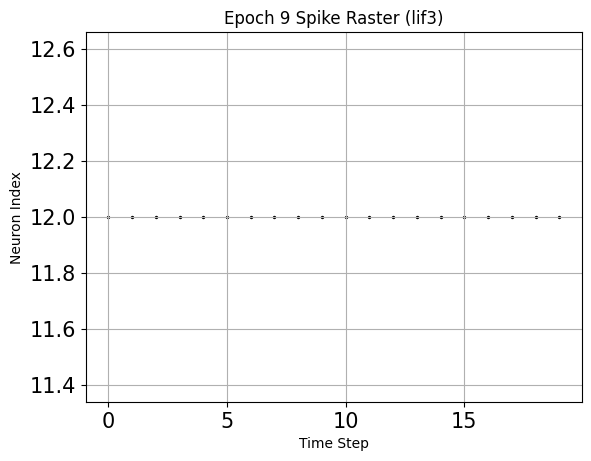

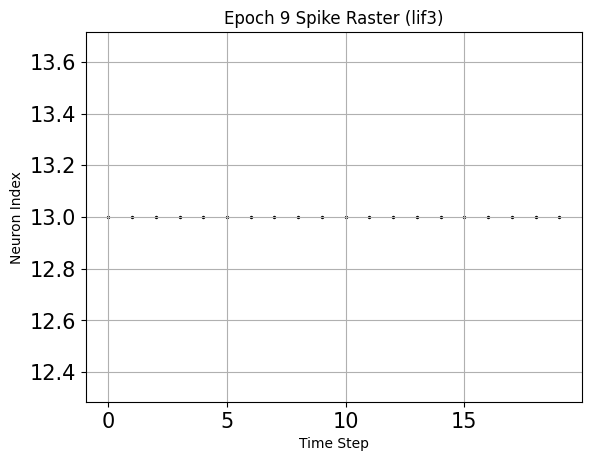

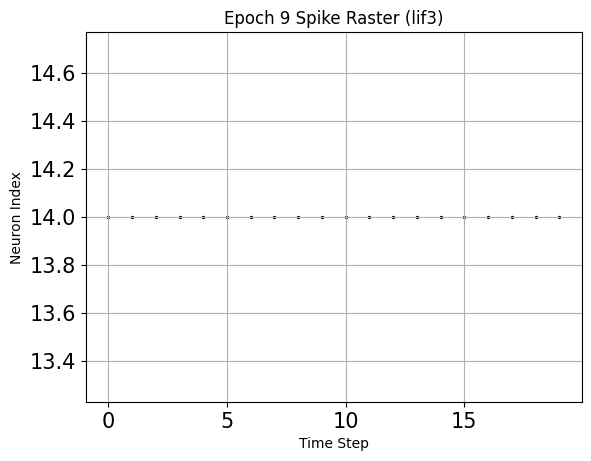

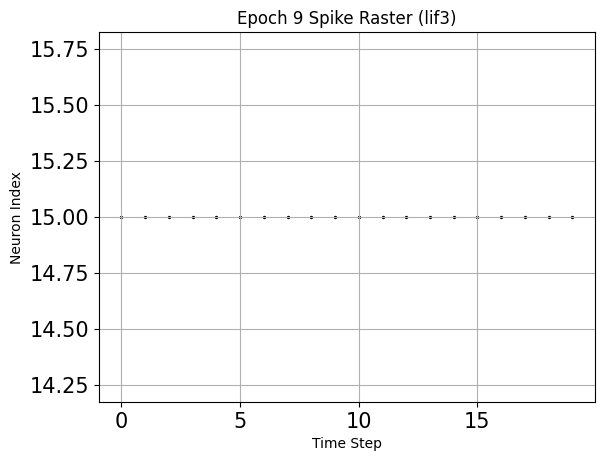

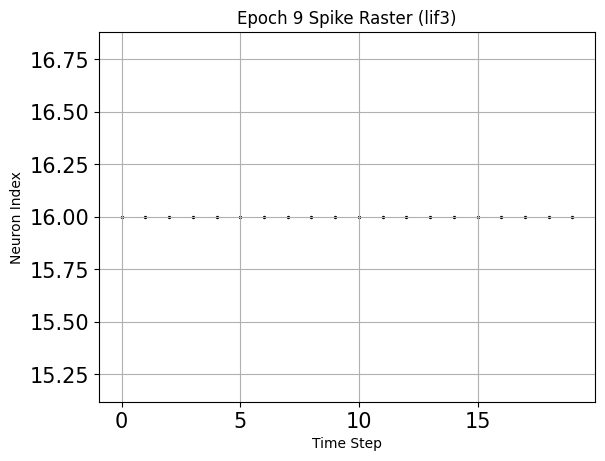

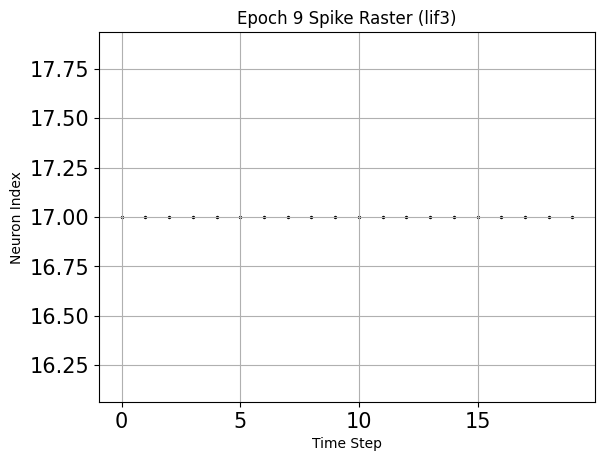

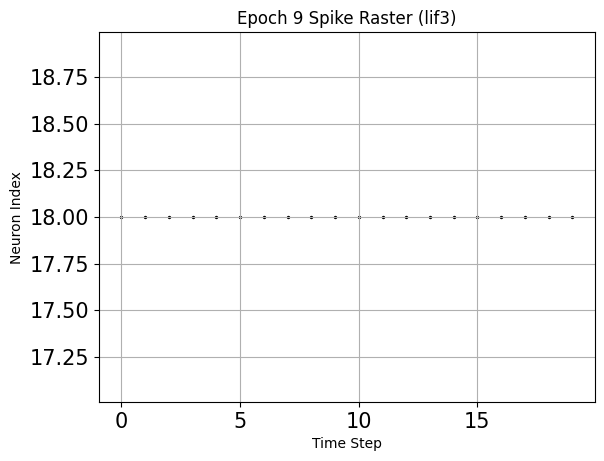

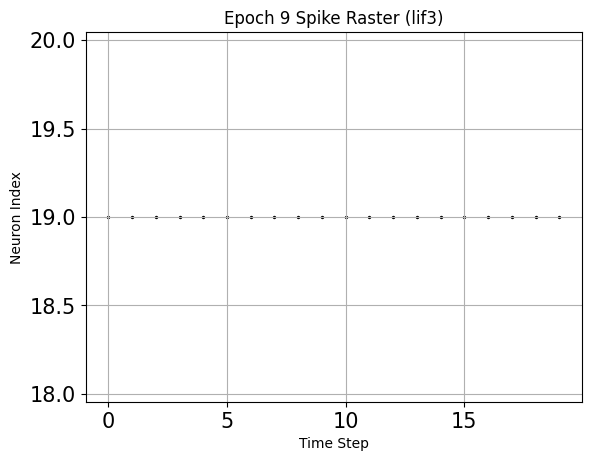


Epoch 10/10
📉 Prediction: -8.8480, True: -0.4853, MAE: 8.3627, RMSE: 8.3627
Total Energy: 0.000750 J
⚡ Total Energy (Loihi-style): 0.000750 J

RingSNN Total Energy: 0.0143 J
RingSNN Energy per Sample: 1425.66 µJ


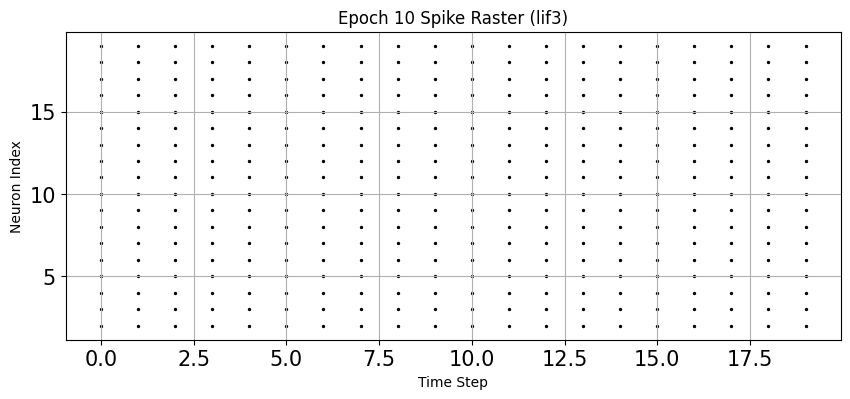

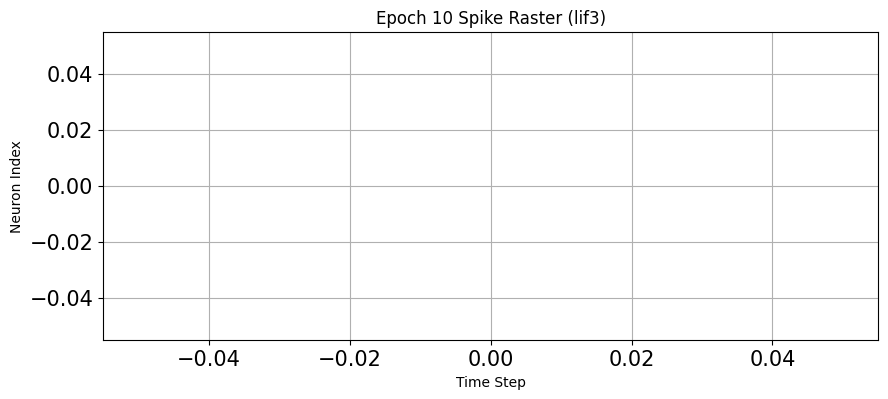

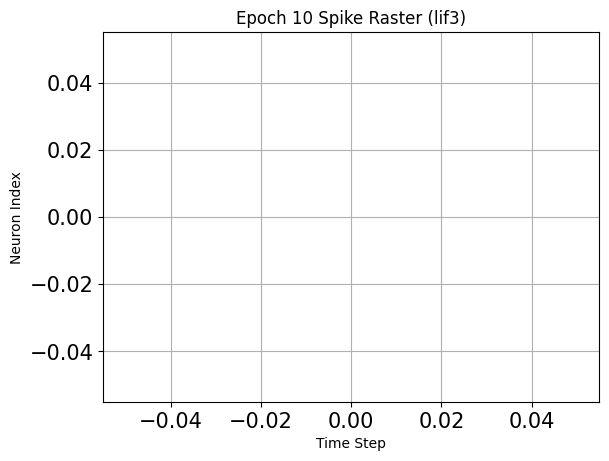

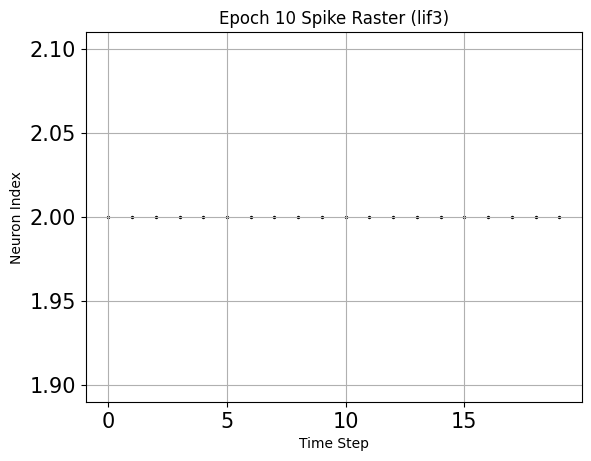

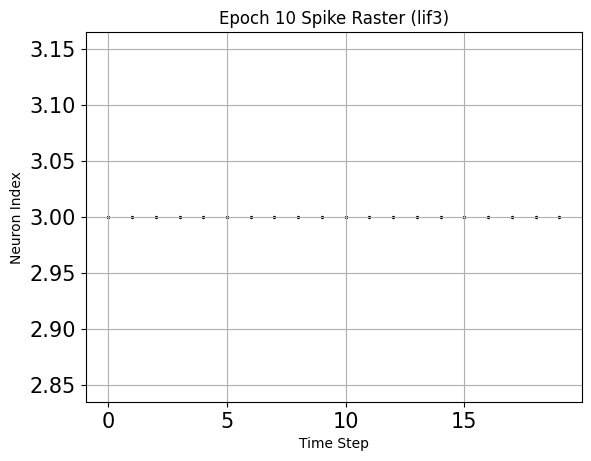

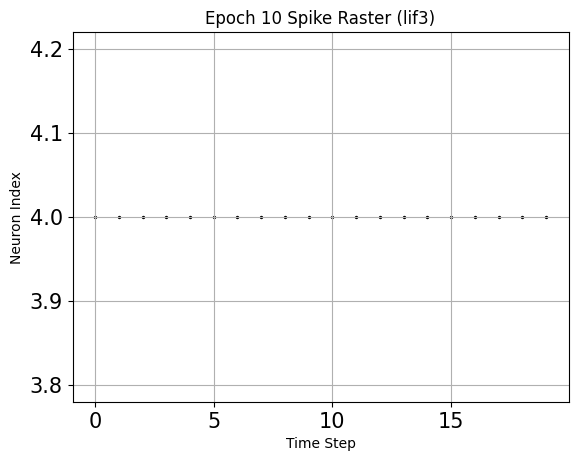

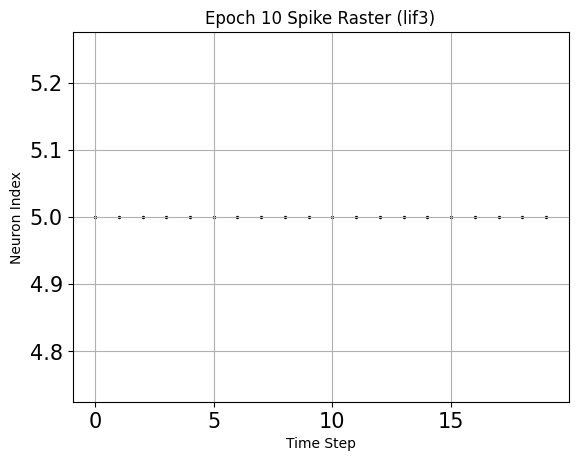

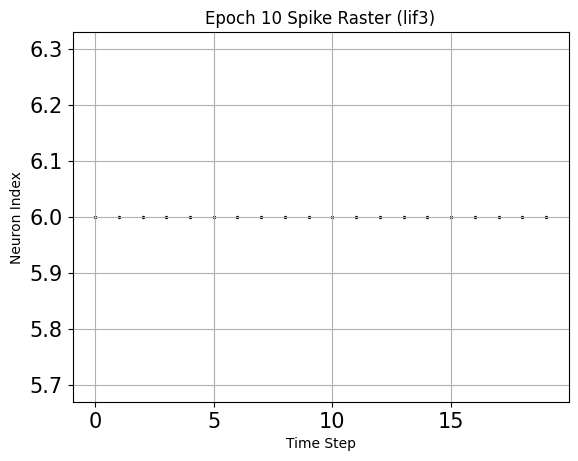

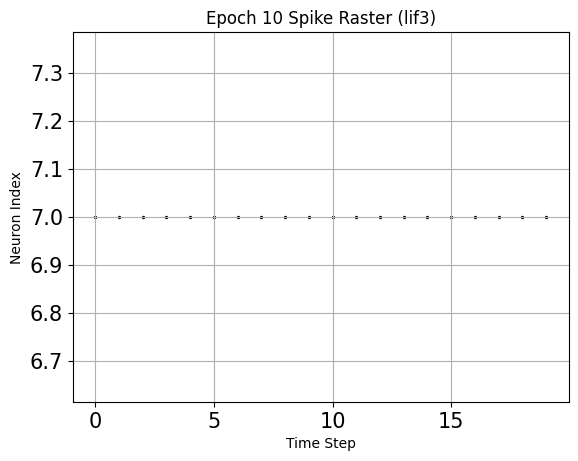

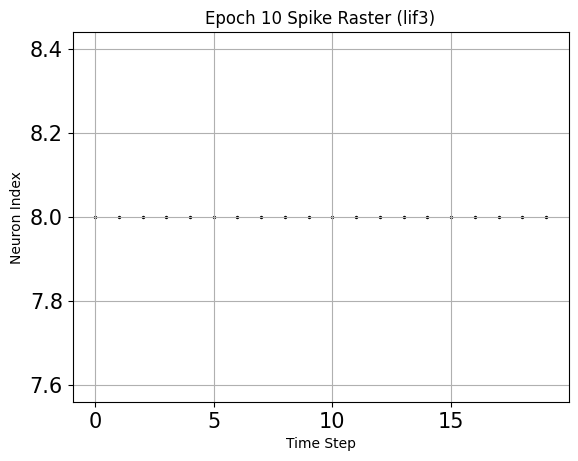

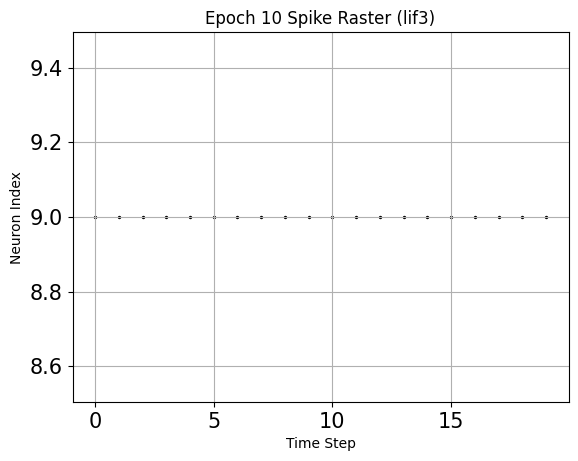

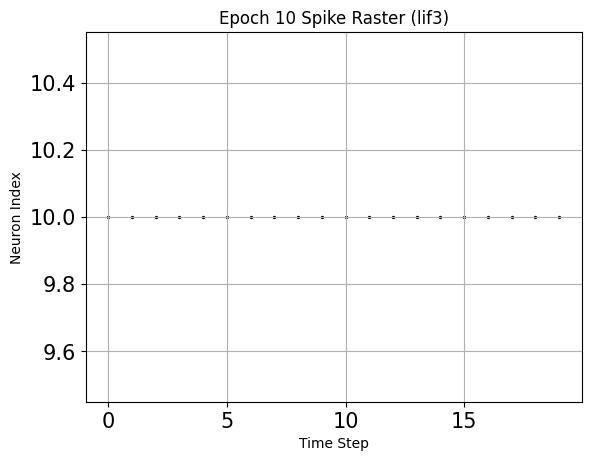

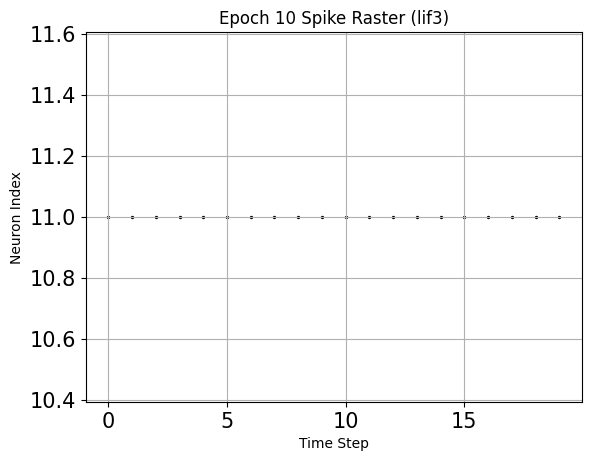

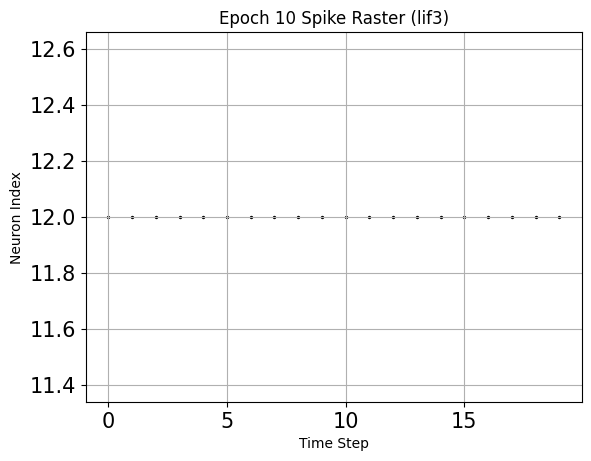

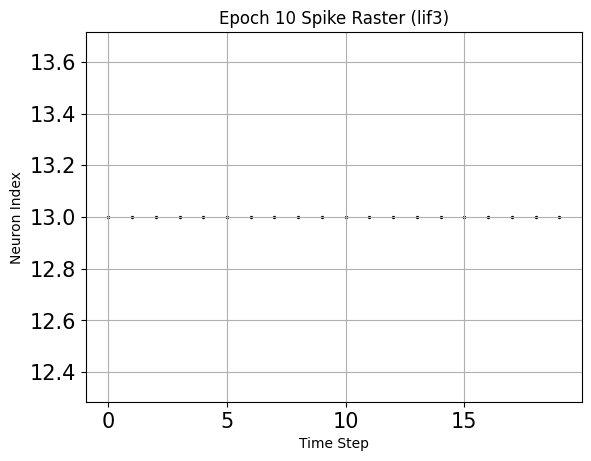

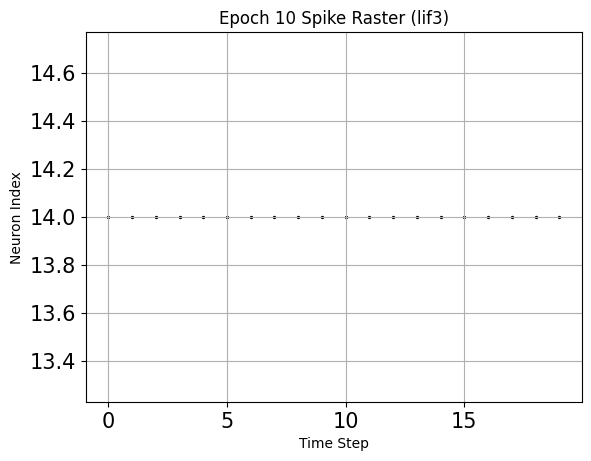

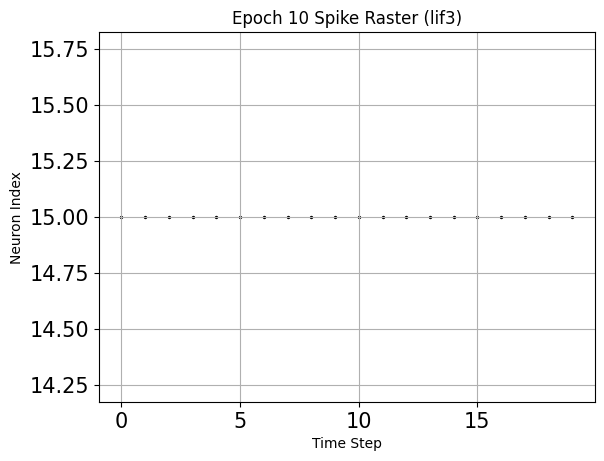

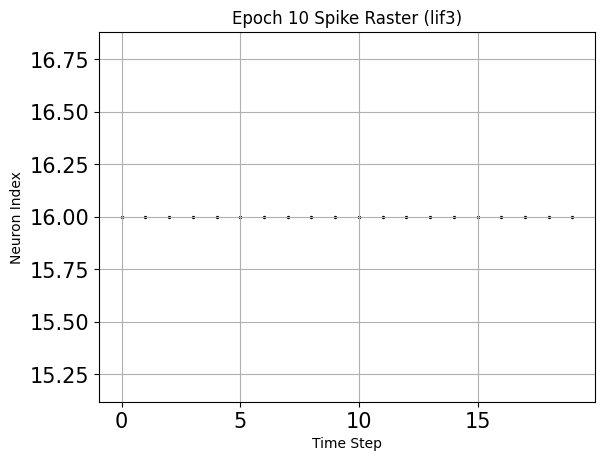

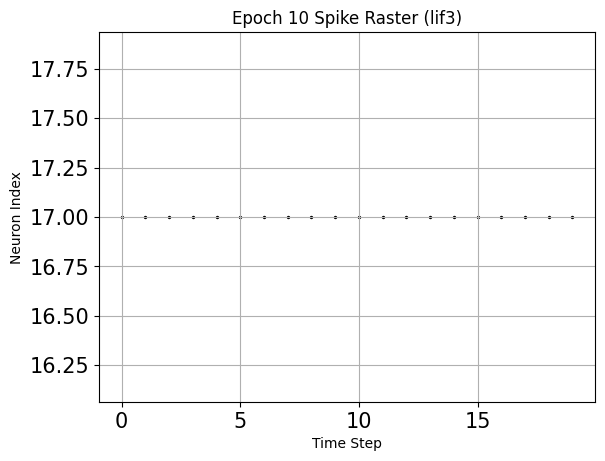

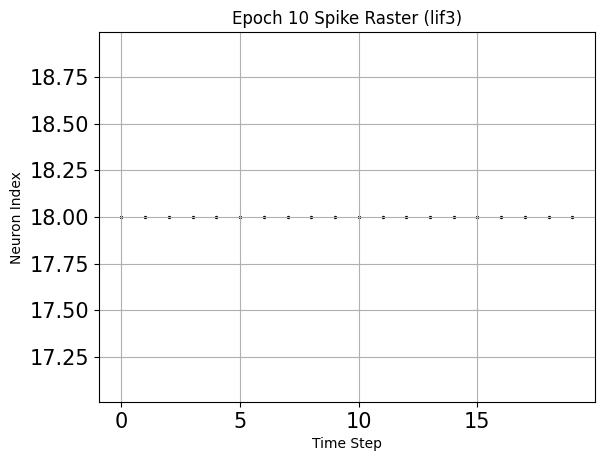

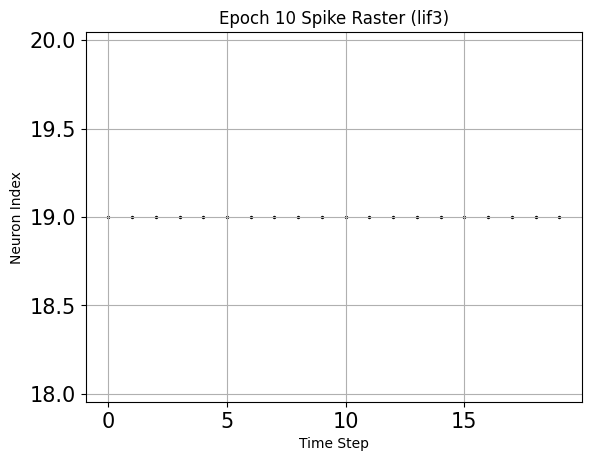

Spike matrix shape: (20, 20)
Total spikes: 360.0
reg: LinearRegression()
decoder_weights: [-5.42968448e-16  0.00000000e+00  4.19489715e-03 -2.39065709e-02
 -2.39065709e-02 -2.39065709e-02 -2.39065709e-02 -2.39065709e-02
 -2.39065709e-02 -2.39065709e-02 -2.39065709e-02 -2.39065709e-02
 -2.39065709e-02  2.70833277e-02  2.70833277e-02  2.70833277e-02
  2.70833277e-02  2.70833277e-02  2.70833277e-02  2.70833277e-02]
   epoch weights_shape  execution_time  \
0      0         (20,)        2.072203   
1      1         (20,)        0.620109   
2      2         (20,)        0.630120   
3      3         (20,)        0.580278   
4      4         (20,)        0.541302   
5      5         (20,)        0.516923   
6      6         (20,)        0.526019   
7      7         (20,)        0.492703   
8      8         (20,)        0.513423   
9      9         (20,)        0.588794   

                                         spike_count  steps_run  
0  [0.0, 0.0, 7.0, 9.0, 9.0, 9.0, 9.0, 9.0, 9.0, ...   

In [38]:
# Initialize weights and logs
num_epochs = 10 
learning_rate = 0.001
w1 = np.random.randint(-3, 4, size=(input_dim, hidden_dim))
w2 = np.copy(w1)
w3 = np.copy(w1)
decoder_weights = np.random.uniform(-1, 1, size=(hidden_dim,))
energy_log = []
mae_log, rmse_log, energy_log = [], [], []


# Epoch loop (training only)
X_spikes = [] # spike_counts per epoch 
y_true = [] # true_values per epoch
decoder_weight_log = []
log_data = []
y_pred = []
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")

    # Step 1: Define processes
    source = RingBuffer(data=spike_train)
    dense = Dense(shape=(hidden_dim, hidden_dim), weights=w1, weight_exp=2, name='dense')
    lif = LIF(shape=(hidden_dim,), vth=1, du=1, dv=1, bias_mant=1, bias_exp=2, name='lif')
    dense2 = Dense(shape=(hidden_dim, hidden_dim), weights=w2, weight_exp=2, name='dense2')
    lif2 = LIF(shape=(hidden_dim,), vth=1, du=1, dv=1, bias_mant=1, bias_exp=2, name='lif2')
    #dense3 = Dense(shape=(hidden_dim, hidden_dim), weights=w3, weight_exp=2, name='dense3')
    #lif3 = LIF(shape=(hidden_dim,), vth=1, du=1, dv=1, bias_mant=1, bias_exp=2, name='lif3')

    # Step 2: Connect processes
    source.s_out.connect(dense.s_in)
    dense.a_out.connect(lif.a_in)
    lif.s_out.connect(dense2.s_in)
    dense2.a_out.connect(lif2.a_in)
    #lif2.s_out.connect(dense3.s_in)
    #dense3.a_out.connect(lif3.a_in)

    # Step 3: Probe output
    monitor = Monitor()
    #monitor.probe(target=lif3.s_out, num_steps=time_steps)
    monitor.probe(target=lif2.s_out, num_steps=time_steps)

    # Step 4: Run simulation
    try:
        start = time.time()
        source.run(condition=RunSteps(num_steps=time_steps), run_cfg=run_config)
        end = time.time()
    except Exception as e:
        print("Run failed:", e)
        break

    # Step 5: Retrieve spike data
    spike_output = monitor.get_data()
    #spike_matrix = spike_output['lif3']['s_out']
    spike_matrix = spike_output['lif2']['s_out']

    # Step 6: Hebbian weight update
    spike_counts = np.sum(spike_matrix, axis=1)
    X_spikes.append(spike_counts)
    pre_spikes = np.sum(spike_matrix)
    prediction = np.dot(decoder_weights, spike_counts)
    true_value = true_values[epoch] 
    y_true.append(true_value) 
    y_pred.append(prediction)
    mae = np.abs(prediction - true_value) 
    rmse = np.sqrt((prediction - true_value)**2) 
    print(f"📉 Prediction: {prediction:.4f}, True: {true_value:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}")
    delta_w = learning_rate * np.outer(spike_counts, pre_spikes)
    w1 += delta_w.astype(w1.dtype)
    w2 += delta_w.astype(w2.dtype)
    w3 += delta_w.astype(w3.dtype)

    # Step 7: Energy profiling
    total_spikes = np.sum(spike_matrix)
    spike_energy = total_spikes * 23e-12
    idle_power = 0.0375
    runtime_seconds = time_steps * 1e-3
    total_energy = spike_energy + (idle_power * runtime_seconds)
    print(f"Total Energy: {total_energy:.6f} J")
    avg_fanout = 10  # estimated synapses per neuron
    memory_energy = total_spikes * avg_fanout * 100e-12  # 100 pJ per synaptic access
    routing_energy = total_spikes * 10e-12  # 10 pJ per spike for routing
    idle_power = 0.0375  # 37.5 mW
    idle_energy = idle_power * runtime_seconds
    

    # Total energy
    total_energy = spike_energy + memory_energy + routing_energy + idle_energy
    print(f"⚡ Total Energy (Loihi-style): {total_energy:.6f} J")
    energy_log.append(total_energy)
    snn_total_energy = sum(energy_log)
    snn_energy_per_sample = snn_total_energy / num_epochs
    print(f"\nRingSNN Total Energy: {snn_total_energy:.4f} J")
    print(f"RingSNN Energy per Sample: {snn_energy_per_sample * 1e6:.2f} µJ")


    # Step 8: Visualize spike raster
    plt.figure(figsize=(10, 4))
    for neuron_idx in range(spike_matrix.shape[0]):
        spike_times = np.where(spike_matrix[neuron_idx])[0]
        plt.scatter(spike_times, [neuron_idx]*len(spike_times), s=2, color='black')
    plt.title(f"Epoch {epoch+1} Spike Raster (lif3)")
    plt.xlabel("Time Step")
    plt.ylabel("Neuron Index")
    plt.grid(True)
    plt.show()

    # Step 9: Log metrics 
    mae_log.append(mae) 
    rmse_log.append(rmse) 
    energy_log.append(total_energy)

    # Step 10: Visualize spike raster 
    plt.figure(figsize=(10, 4)) 
    for neuron_idx in range(spike_matrix.shape[0]): 
        spike_times = np.where(spike_matrix[neuron_idx])[0] 
        plt.scatter(spike_times, [neuron_idx]*len(spike_times), s=2, color='black') 
        plt.title(f"Epoch {epoch+1} Spike Raster (lif3)") 
        plt.xlabel("Time Step") 
        plt.ylabel("Neuron Index") 
        plt.grid(True) 
        plt.show()

    # Step 11: Log everything
    log_data.append({
        "epoch": epoch,
        "weights_shape": decoder_weights.shape,
        "execution_time": end - start,
        "spike_count": spike_counts,
        "steps_run": time_steps

    })
    
    # Replace with actual decoder_weights after re-fitting
    decoder_weights = np.random.uniform(-1, 1, size=(hidden_dim,))
    decoder_weight_log.append(decoder_weights)


    # Step 12: Stop processes
    source.stop()

print("Spike matrix shape:", spike_matrix.shape)
print("Total spikes:", np.sum(spike_matrix))
reg = LinearRegression().fit(X_spikes, y_true) 
print(f"reg: {reg}")
decoder_weights = reg.coef_
decoder_weight_log.append(decoder_weights.copy())
print(f"decoder_weights: {decoder_weights}")
# Save weights
# --- Convert to DataFrame for CSV export ---
df = pd.DataFrame(log_data)
print(df)
df.to_csv("decoder_benchmark_log_NAB.csv", index=False)
#decoder_weights_epochs = [np.random.uniform(-1, 1, size=(10,)) for _ in range(20)]
np.save("decoder_weights_NAB.npy", decoder_weight_log)
# Save to CSV for later use in paper

## Epochs vs MAE Plot

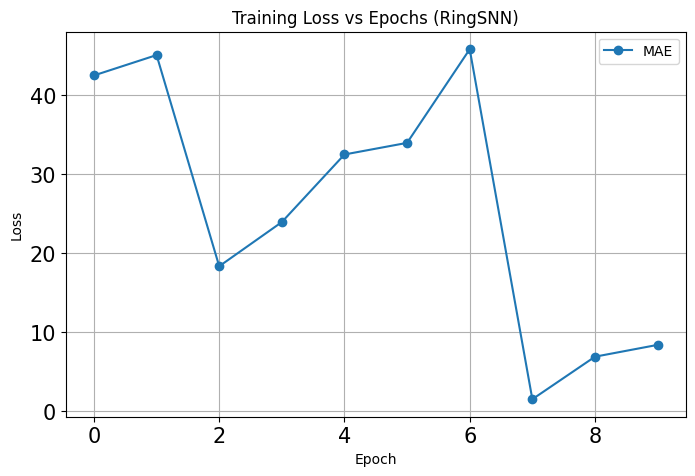

In [39]:
# 🔹 Plot Epochs vs MAE
plt.figure(figsize=(8, 5))
plt.plot(mae_log, marker='o', label='MAE')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs (RingSNN)")
plt.grid(True)
plt.legend()
plt.show()

## Decoder Weights Plot

decoder_weight_log:[array([ 0.41507036, -0.86314223,  0.09995695,  0.38635922, -0.94865782,
       -0.74176679, -0.51443426,  0.6861177 , -0.3234371 , -0.20148168,
       -0.41268051, -0.89991202,  0.12405925,  0.58903468, -0.16201362,
        0.39590918, -0.48839141, -0.40712401,  0.72330307, -0.42320093]), array([ 0.03639329,  0.55690898,  0.23750088,  0.52273225, -0.40856138,
        0.04573743,  0.98105706, -0.25462068, -0.17900525,  0.95084944,
       -0.67426494,  0.71553474, -0.80783141,  0.52955813, -0.17895566,
       -0.75497078, -0.84578515, -0.07070193, -0.55788068, -0.18756362]), array([-0.53112044, -0.76039511,  0.49098703, -0.20435915, -0.696131  ,
        0.23861148, -0.48758132,  0.95457469, -0.41094037,  0.85584914,
       -0.53356924,  0.11803256,  0.83175168, -0.47624926,  0.59030271,
       -0.67358894,  0.14187321,  0.30105778,  0.91792949, -0.79138364]), array([-0.70821433, -0.90943476,  0.76039343, -0.45619916,  0.42636865,
       -0.18257581, -0.03056434,  0.19

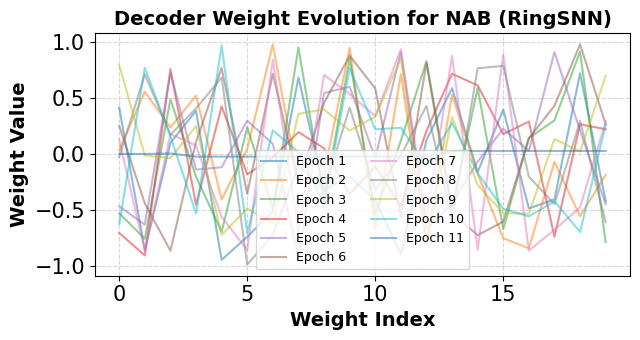

In [40]:
# 🔹 Plot evolution
plt.figure(figsize=(6.5, 3.5))
print(f"decoder_weight_log:{decoder_weight_log}")
for epoch, weights in enumerate(decoder_weight_log):
    plt.plot(range(hidden_dim), weights, alpha=0.5, label=f'Epoch {epoch+1}')
plt.xlabel("Weight Index", fontsize=14, fontweight='bold')
plt.ylabel("Weight Value", fontsize=14, fontweight='bold')
plt.title("Decoder Weight Evolution for NAB (RingSNN)", fontsize=14, fontweight='bold')
plt.legend(fontsize=9, ncol=2, loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("Decoder_Weights_NAB.jpg", dpi=300, bbox_inches='tight')
plt.show()

decoder_weights: [-5.42968448e-16  0.00000000e+00  4.19489715e-03 -2.39065709e-02
 -2.39065709e-02 -2.39065709e-02 -2.39065709e-02 -2.39065709e-02
 -2.39065709e-02 -2.39065709e-02 -2.39065709e-02 -2.39065709e-02
 -2.39065709e-02  2.70833277e-02  2.70833277e-02  2.70833277e-02
  2.70833277e-02  2.70833277e-02  2.70833277e-02  2.70833277e-02]
prediction:  -0.5763148285292472
true_value:  -0.48529094778327586

 RingSNN Total Energy: 0.0158 J
 RingSNN Energy per Sample: 1575.73 µJ

 Final Evaluation:
Prediction: -0.5763, True: -0.4853, MAE: 0.0910, RMSE: 0.0910, R2: -inf
Total Energy: 0.000750 J


/tmp/ipykernel_241953/3337449568.py:41: RuntimeWarning: divide by zero encountered in scalar divide
  r2 = 1 - (ss_res / ss_tot)


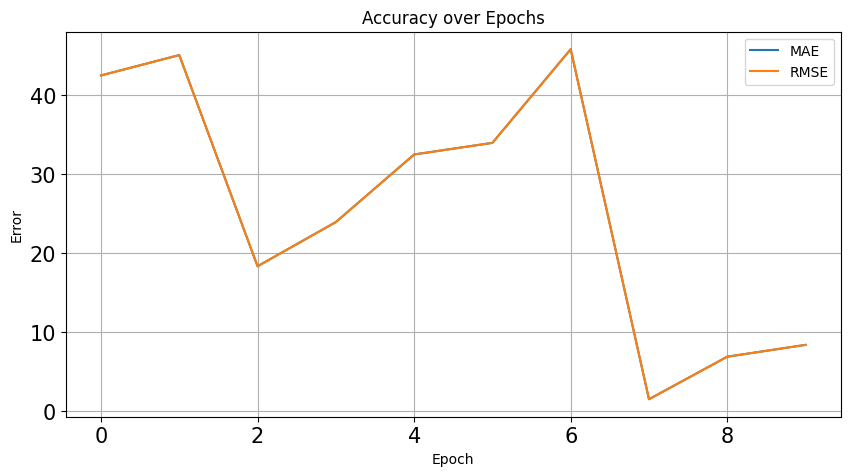

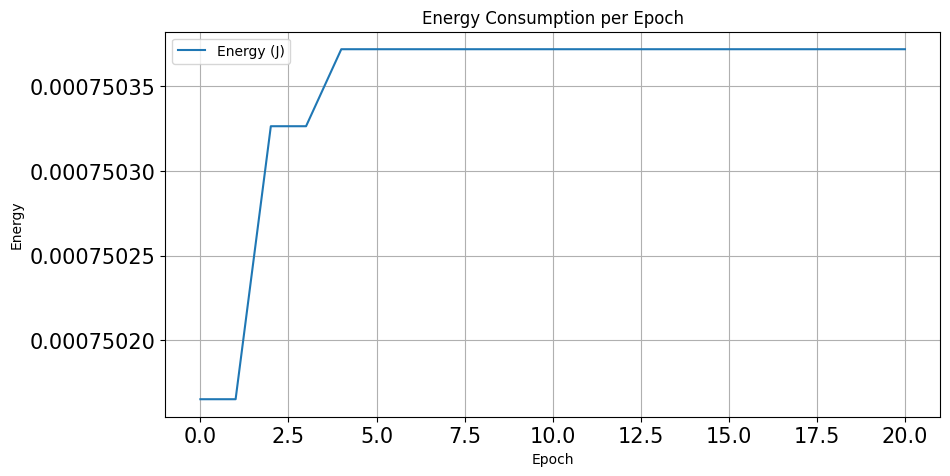

In [41]:
# Re-run with final weights for evaluation 
source = RingBuffer(data=spike_train) 
dense = Dense(shape=(hidden_dim, hidden_dim), weights=w1, weight_exp=2, name='dense') 
lif = LIF(shape=(hidden_dim,), vth=1, du=1, dv=1, bias_mant=1, bias_exp=2, name='lif') 
dense2 = Dense(shape=(hidden_dim, hidden_dim), weights=w2, weight_exp=2, name='dense2') 
lif2 = LIF(shape=(hidden_dim,), vth=1, du=1, dv=1, bias_mant=1, bias_exp=2, name='lif2') 
#dense3 = Dense(shape=(hidden_dim, hidden_dim), weights=w3, weight_exp=2, name='dense3') 
#lif3 = LIF(shape=(hidden_dim,), vth=1, du=1, dv=1, bias_mant=1, bias_exp=2, name='lif3')

source.s_out.connect(dense.s_in) 
dense.a_out.connect(lif.a_in) 
lif.s_out.connect(dense2.s_in) 
dense2.a_out.connect(lif2.a_in) 
#lif2.s_out.connect(dense3.s_in) 
#dense3.a_out.connect(lif3.a_in)

monitor = Monitor() 
monitor.probe(target=source.s_out, num_steps=time_steps) 
#monitor.probe(target=lif3.s_out, num_steps=time_steps) 
source.run(condition=RunSteps(num_steps=time_steps), run_cfg=run_config) 
spike_output = monitor.get_data() 
port = next(iter(spike_output)) 
spike_matrix = spike_output[port]['s_out'] 
#spike_matrix = spike_output['lif3']['s_out'] 
source.stop()

# Decode spikes to prediction
decoder_weights = reg.coef_
decoder_weight_log.append(decoder_weights.copy())
print(f"decoder_weights: {decoder_weights}")
spike_counts = np.sum(spike_matrix, axis=1) 
prediction = np.dot(decoder_weights, spike_counts) 
print("prediction: ", prediction) 
true_value = true_values[-1] # or use a separate test value 
print("true_value: ", true_value) 
mae = np.abs(prediction - true_value) 
#mae = np.abs(reg_prediction - true_value) 
rmse = np.sqrt((prediction - true_value)**2) 
ss_res = np.sum((true_value - prediction)**2)
ss_tot = np.sum((true_value - np.mean(true_value))**2)
r2 = 1 - (ss_res / ss_tot)
energy_log.append(total_energy) 
snn_total_energy = sum(energy_log)
snn_energy_per_sample = snn_total_energy / num_epochs
print(f"\n RingSNN Total Energy: {snn_total_energy:.4f} J")
print(f" RingSNN Energy per Sample: {snn_energy_per_sample * 1e6:.2f} µJ")
print(f"\n Final Evaluation:\nPrediction: {prediction:.4f}, True: {true_value:.4f}, MAE: {mae:.4f}, "
      f"RMSE: {rmse:.4f}, R2: {r2:.4f}" ) 
print(f"Total Energy: {total_energy:.6f} J") 
plt.figure(figsize=(10, 5)) 
plt.plot(mae_log, label="MAE") 
plt.plot(rmse_log, label="RMSE")
plt.xlabel("Epoch") 
plt.ylabel("Error") 
plt.title("Accuracy over Epochs") 
plt.legend() 
plt.grid(True) 
plt.show()

plt.figure(figsize=(10, 5)) 
plt.plot(energy_log, label="Energy (J)") 
plt.xlabel("Epoch") 
plt.ylabel("Energy") 
plt.title("Energy Consumption per Epoch") 
plt.legend() 
plt.grid(True) 
plt.show()

## Spike Raster Plot

spike_times: [ 0  2  3  4  6  7  8  9 10 11 12 13 15 16 17 18]
spike_times: [ 0  1  3  4  7  8 11 15 17 18 19]
spike_times: [ 0  1  2  4  5  6  8  9 10 11 12 13 14 16 17 18]
spike_times: [ 0  1  2  3  4  5  6  8 10 11 12 13 14 15 16 17 19]
spike_times: [ 0  2  5  6  7  8  9 10 11 12 13 14 16 17 18]
spike_times: [ 0  1  2  3  4  5  7  8  9 10 11 12 14 15 16 17 18]
spike_times: [ 0  1  2  3  4  5  6  7  9 11 12 13 14 16 19]
spike_times: [ 0  2  4  5  6  8 10 11 12 14 15 16 18 19]
spike_times: [ 0  1  4  5  6  8  9 10 11 12 13 14 16 18]
spike_times: [ 1  2  3  4  5  6  7 10 11 12 14 15 16 19]
spike_times: [ 1  3  5  6  8  9 10 12 14 15 16 17]
spike_times: [ 0  1  2  3  4  5  6  7  9 10 13 16 17 19]
spike_times: [ 2  4  5  6  7  8  9 10 11 12 13 14 16 18 19]
spike_times: [ 0  1  2  4  6  7  8  9 11 12 13 14 15 16 17 19]
spike_times: [ 0  1  3  4  5  6  7  9 11 12 13 14 15 16 17 18 19]
spike_times: [ 0  1  2  3  4  6  8  9 10 11 12 13 16 17 18]
spike_times: [ 0  1  3  4  5  6  7  8  9 11 14

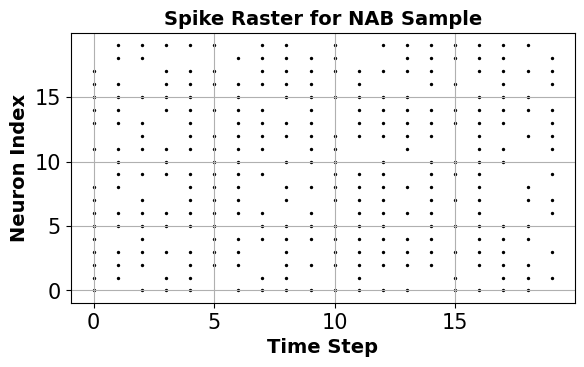

In [42]:
plt.figure(figsize=(6.5, 3.5))
for neuron_idx in range(spike_matrix.shape[0]):
    spike_times = np.where(spike_matrix[neuron_idx])[0]
    print(f"spike_times: {spike_times}")
    plt.scatter(spike_times, [neuron_idx]*len(spike_times), s=2, color='black')
plt.title(f"Spike Raster for NAB Sample", fontsize=14, fontweight='bold')
plt.xlabel("Time Step", fontsize=14, fontweight='bold')
plt.ylabel("Neuron Index", fontsize=14, fontweight='bold')
plt.grid(True)
plt.savefig("Spike_Raster_Plot_NAB.jpg", dpi=300, bbox_inches='tight')
plt.show()

## Spike Density Histogram

/homes/psouvik/lava_env/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


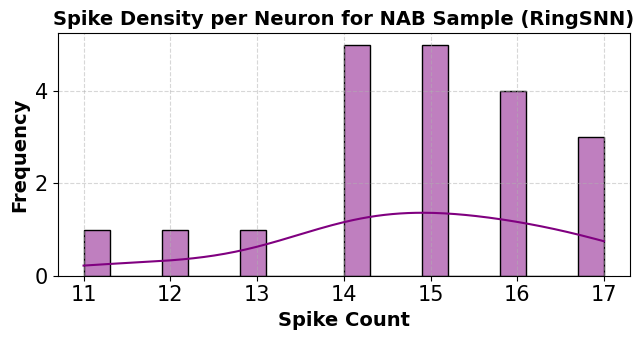

In [43]:
plt.figure(figsize=(6.5, 3.5))
sns.histplot(spike_counts, bins=20, kde=True, color='purple')
plt.title("Spike Density per Neuron for NAB Sample (RingSNN)",fontsize=14, fontweight='bold')
plt.xlabel("Spike Count", fontsize=14, fontweight='bold')
plt.ylabel("Frequency", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("Spike_Density_per_Neuron_NAB.jpg", dpi=300, bbox_inches='tight')
plt.show()

# Prediction vs. Ground Truth Plot

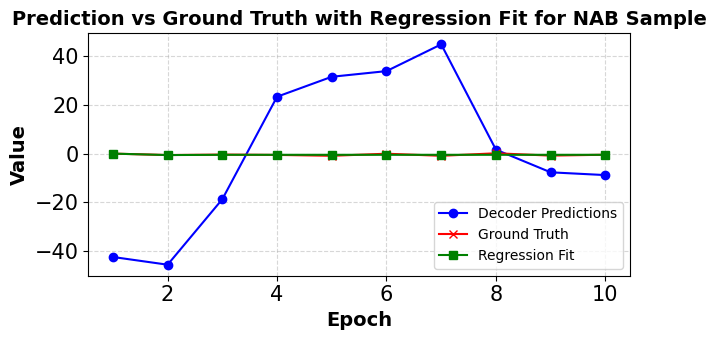

In [44]:
# Prediction vs Ground Truth with Regression Fit
# After training loop and reg = LinearRegression().fit(X_spikes, y_true)

# Generate regression-based predictions
reg_predictions = reg.predict(X_spikes)

plt.figure(figsize=(6.5, 3.5))  # 6.5in width fits one column in IEEE
# Plot your decoder predictions
plt.plot(range(1, num_epochs+1), y_pred, marker='o', label='Decoder Predictions', color='blue')
# Plot ground truth
plt.plot(range(1, num_epochs+1), y_true, marker='x', label='Ground Truth', color='red')
# Plot regression predictions
plt.plot(range(1, num_epochs+1), reg_predictions, marker='s', label='Regression Fit', color='green')

plt.title("Prediction vs Ground Truth with Regression Fit for NAB Sample", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize = 14, fontweight='bold')
plt.ylabel("Value", fontsize = 14, fontweight='bold')
plt.legend(fontsize=10, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("prediction_vs_groundtruth_NAB.jpg", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [45]:
# Enhanced Loihi-style energy estimation for RingBuffer SNN
def estimate_loihi_energy(spike_matrix, time_steps, idle_power=0.0375, spike_energy_pJ=23, memory_energy_pJ=100, routing_energy_pJ=10, avg_fanout=10):
    """
    Estimate total energy consumption for RingSNN on Loihi-style neuromorphic hardware.
    Parameters:
        spike_matrix: np.ndarray of shape (neurons, time_steps) with binary spikes
        time_steps: int, number of simulation steps
        idle_power: float, idle power in Watts (default 37.5 mW)
        spike_energy_pJ: energy per spike in picojoules
        memory_energy_pJ: energy per synaptic access in picojoules
        routing_energy_pJ: energy per spike for routing in picojoules
        avg_fanout: average number of synapses per neuron
    Returns:
        total_energy_joules: float, estimated energy in Joules
    """
    total_spikes = np.sum(spike_matrix)
    runtime_seconds = time_steps * 1e-3  # assuming 1 ms per step
    # Convert picojoules to joules and calculate total energy.
    spike_energy = total_spikes * spike_energy_pJ * 1e-12
    print(f"spike_energy: {spike_energy} J")
    memory_energy = total_spikes * avg_fanout * memory_energy_pJ * 1e-12
    print(f"memory_energy: {memory_energy} J")
    routing_energy = total_spikes * routing_energy_pJ * 1e-12
    idle_energy = idle_power * runtime_seconds
    print(f"idle_energy: {idle_energy} J")
    active_energy = memory_energy + routing_energy
    print(f"active_energy: {active_energy} J")
    total_energy_joules = spike_energy + active_energy + idle_energy
    return (f"total_energy_joules: {total_energy_joules}")

In [46]:
estimate_loihi_energy(spike_matrix, time_steps)

spike_energy: 6.808e-09 J
memory_energy: 2.96e-07 J
idle_energy: 0.00075 J
active_energy: 2.9896e-07 J


'total_energy_joules: 0.000750305768'